<a href="https://colab.research.google.com/github/rpsamuel/jupyternotebooks/blob/main/whalewisdom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance pandas numpy pandas-ta lxml
!pip install requests
!pip install  ta-lib
!pip install tabulate
!pip install PyPortfolioOpt
!pip install pyportfolioopt --upgrade
!pip install ta
# 🔹 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
!pip install yfinance --upgrade --no-cache-dir
!import os # Import the os module

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 14.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 8.3 MB/s eta 0:00:00


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

def get_nasdaq100_wikipedia():
    """Get Nasdaq-100 tickers from Wikipedia with error handling"""
    try:
        url = "https://en.wikipedia.org/wiki/NASDAQ-100"
        html = requests.get(url).text
        soup = BeautifulSoup(html, 'html.parser')

        # Find the constituents table
        tables = soup.find_all('table', {'class': 'wikitable'})
        for table in tables:
            if 'Ticker' in str(table):
                df = pd.read_html(str(table))[0]
                if 'Ticker' in df.columns:
                    tickers = df['Ticker'].tolist()
                    return tickers
    except Exception as e:
        print(f"Error scraping Wikipedia: {e}")

    return  [
    'AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'GOOG', 'META', 'TSLA', 'AVGO', 'PEP',
    'COST', 'ADBE', 'CSCO', 'TMUS', 'CMCSA', 'NFLX', 'AMD', 'INTC', 'INTU', 'AMGN',
    'QCOM', 'HON', 'TXN', 'AMAT', 'ISRG', 'BKNG', 'LRCX', 'ADP', 'SBUX', 'REGN',
    'MDLZ', 'GILD', 'ADI', 'VRTX', 'PANW', 'PYPL', 'ASML', 'SNPS', 'CDNS', 'CHTR',
    'MU', 'MAR', 'KLAC', 'ABNB', 'ORLY', 'MELI', 'CTAS', 'CSX', 'MCHP', 'NXPI',
    'FTNT', 'PDD', 'KDP', 'KHC', 'MNST', 'AEP', 'LULU', 'CRWD', 'DXCM', 'AZN',
    'IDXX', 'WDAY', 'FAST', 'PCAR', 'ROST', 'BIIB', 'DASH', 'VRSK', 'EXC', 'CPRT',
    'PAYX', 'XEL', 'TTWO', 'ODFL', 'MRVL', 'DLTR', 'CTSH', 'EA', 'BKR', 'WBD',
    'ILMN', 'ZS', 'CEG', 'FANG', 'TEAM', 'ANSS', 'SIRI', 'ALGN', 'ENPH', 'JD',
    'MRNA', 'EBAY', 'VOD', 'ALNY', 'ZSAN', 'SWKS', 'DOCU', 'SPLK', 'NTES', 'OKTA'
    ]

tickers = get_nasdaq100_wikipedia()
if tickers:
    print(f"Successfully retrieved {len(tickers)} tickers")
    print(tickers[:10], "...")  # Show first 10
else:
    print("Using fallback list")
    # Use pre-compiled list as backup

Successfully retrieved 100 tickers
['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'GOOG', 'META', 'TSLA', 'AVGO', 'PEP'] ...


In [ ]:
import pandas as pd
import os
from google.colab import drive
import requests # Import the requests library
import io # Import io module for StringIO

# 🔹 Mount Google Drive
drive.mount('/content/drive')

# === Step 1: Fetch indices ===
def get_sp500_tickers():
    """Fetch S&P 500 tickers from Wikipedia"""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
        tables = pd.read_html(io.StringIO(response.text))
        df = tables[0].copy()  # Create a copy to avoid SettingWithCopyWarning
        print("S&P 500 columns:", df.columns)
        df['Index'] = 'S&P 500'
        return df[['Symbol', 'Index']]
    except requests.exceptions.RequestException as e:
        print(f"Error fetching S&P 500 tickers: {e}")
        return pd.DataFrame()
def get_nasdaq100_wikipedia():
    """Get Nasdaq-100 tickers from Wikipedia with error handling"""
    try:
        url = "https://en.wikipedia.org/wiki/NASDAQ-100"
        html = requests.get(url).text
        soup = BeautifulSoup(html, 'html.parser')

        # Find the constituents table
        tables = soup.find_all('table', {'class': 'wikitable'})
        for table in tables:
            if 'Ticker' in str(table):
                df = pd.read_html(str(table))[0]
                if 'Ticker' in df.columns:
                    tickers = df['Ticker'].tolist()
                    return tickers
    except Exception as e:
        print(f"Error scraping Wikipedia: {e}")

    return  [
    'AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'GOOG', 'META', 'TSLA', 'AVGO', 'PEP',
    'COST', 'ADBE', 'CSCO', 'TMUS', 'CMCSA', 'NFLX', 'AMD', 'INTC', 'INTU', 'AMGN',
    'QCOM', 'HON', 'TXN', 'AMAT', 'ISRG', 'BKNG', 'LRCX', 'ADP', 'SBUX', 'REGN',
    'MDLZ', 'GILD', 'ADI', 'VRTX', 'PANW', 'PYPL', 'ASML', 'SNPS', 'CDNS', 'CHTR',
    'MU', 'MAR', 'KLAC', 'ABNB', 'ORLY', 'MELI', 'CTAS', 'CSX', 'MCHP', 'NXPI',
    'FTNT', 'PDD', 'KDP', 'KHC', 'MNST', 'AEP', 'LULU', 'CRWD', 'DXCM', 'AZN',
    'IDXX', 'WDAY', 'FAST', 'PCAR', 'ROST', 'BIIB', 'DASH', 'VRSK', 'EXC', 'CPRT',
    'PAYX', 'XEL', 'TTWO', 'ODFL', 'MRVL', 'DLTR', 'CTSH', 'EA', 'BKR', 'WBD',
    'ILMN', 'ZS', 'CEG', 'FANG', 'TEAM', 'ANSS', 'SIRI', 'ALGN', 'ENPH', 'JD',
    'MRNA', 'EBAY', 'VOD', 'ALNY', 'ZSAN', 'SWKS', 'DOCU', 'SPLK', 'NTES', 'OKTA'
    ]

tickers = get_nasdaq100_wikipedia()
if tickers:
    print(f"Successfully retrieved {len(tickers)} tickers")
    print(tickers[:10], "...")  # Show first 10
else:
    print("Using fallback list")
    # Use pre-compiled list as backup
def get_nasdaq100_tickers():
    """Fetch NASDAQ-100 tickers from Wikipedia"""
    url = 'https://en.wikipedia.org/wiki/NASDAQ-100'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
        tables = pd.read_html(io.StringIO(response.text))  # Get all tables

        # Find the table with tickers (usually has "Ticker" or "Company" in columns)
        for df in tables:
            if 'Ticker' in df.columns or 'Company' in df.columns:
                df = df.copy()
                if 'Ticker' in df.columns:
                    df.rename(columns={'Ticker': 'Symbol'}, inplace=True)
                elif 'Company' in df.columns:
                    # Extract ticker from company name (e.g., "Apple (AAPL)")
                    df['Symbol'] = df['Company'].str.extract(r'\(([A-Z]+)\)')[0]
                df['Index'] = 'NASDAQ-100'
                return df[['Symbol', 'Index']].dropna()

        raise ValueError("NASDAQ-100 table not found in Wikipedia page.")
    except requests.exceptions.RequestException as e:
        print(f"Error fetching NASDAQ-100 tickers: {e}")
        return pd.DataFrame()

def get_dow30_tickers():
    """Fetch Dow 30 tickers from Wikipedia"""
    url = 'https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
        tables = pd.read_html(io.StringIO(response.text))
        # Create a copy of the DataFrame to avoid SettingWithCopyWarning
        df = tables[2][['Symbol', 'Company']].copy()

        # Replace dots with dashes in symbols
        df.loc[:, 'Symbol'] = df['Symbol'].str.replace('.', '-', regex=False)
        df.loc[:, 'Index'] = 'DOW 30'  # Use loc to avoid SettingWithCopyWarning

        return df[['Symbol', 'Index']]
    except requests.exceptions.RequestException as e:
        print(f"Error fetching Dow 30 tickers: {e}")
        return pd.DataFrame()

# Define a mapping of incorrect → correct
fix_map = {
    'BRKB': 'BRK-B',
    'BRK.B': 'BRK-B',
    '$BRKB': 'BRK-B'
}

print("\nFetching S&P 500 tickers...")
sp500 = get_sp500_tickers()
print(f"Fetched {len(sp500)} S&P 500 tickers")

print("\nFetching NASDAQ-100 tickers...")
nasdaq100 = nasdaq_100_tickers
print(f"Fetched {len(nasdaq100)} NASDAQ-100 tickers")
print(f"New Fetched {len(nasdaq100)} NASDAQ-100 tickers")
#print(nasdaq100.head())
print("\nFetching Dow 30 tickers...")
dow30 = get_dow30_tickers()
print(f"Fetched {len(dow30)} Dow 30 tickers")

combined_df = pd.concat([sp500, nasdaq100, dow30], ignore_index=True)
combined_df.drop_duplicates(subset='Symbol', inplace=True)

print(f"\n✅ Total unique tickers after deduplication: {len(combined_df)}")

# === Step 2: Add Hedge Fund Top 5 ===


# === Step 3: Combine both ===
final_df = pd.concat([combined_df], ignore_index=True)

# Optional: remove duplicates if you only care about unique Symbol/Index combinations
final_df.drop_duplicates(inplace=True)
# Remove duplicates (keeping first occurrence)
combined_df = final_df.drop_duplicates(subset='Symbol')

# Count after removing duplicates
print(f"Total unique tickers after deduplication: {len(combined_df)}")

# Apply the mapping
combined_df['Symbol'] = combined_df['Symbol'].replace(fix_map)
# Create a list of tickers with '.' replaced by '-'
all_tickers = combined_df['Symbol'].str.replace('.', '-', regex=False).tolist()

# Count by index
index_counts = combined_df['Index'].value_counts()
print("\nTicker counts by index:")
print(index_counts)
# Show a preview
print("\n┘ Combined DataFrame (first 10 rows):")
print(final_df.head(10))

print(f"\n↗│ Total rows (symbols x sources): {len(combined_df)}")
print(f"↗│ Unique symbols: {combined_df['Symbol'].nunique()}")

# === Step 4: Save to Google Drive ===
SAVE_DIR = "/content/drive/My Drive/TradingData/"
os.makedirs(SAVE_DIR, exist_ok=True)

OUTPUT_FILE = os.path.join(SAVE_DIR, "all_tickers.csv")
combined_df.to_csv(OUTPUT_FILE, index=False)
print(all_tickers)
print(f"\n✅ Combined symbols file saved: {OUTPUT_FILE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully retrieved 100 tickers
['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'GOOG', 'META', 'TSLA', 'AVGO', 'PEP'] ...

Fetching S&P 500 tickers...
S&P 500 columns: Index(['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry',
       'Headquarters Location', 'Date added', 'CIK', 'Founded'],
      dtype='str')
Fetched 503 S&P 500 tickers

Fetching NASDAQ-100 tickers...
Fetched 100 NASDAQ-100 tickers
New Fetched 100 NASDAQ-100 tickers

Fetching Dow 30 tickers...
Fetched 30 Dow 30 tickers


TypeError: cannot concatenate object of type '<class 'list'>'; only Series and DataFrame objs are valid

In [ ]:
##DeepSeek optimized code
import yfinance as yf
import pandas as pd
import numpy as np
from tabulate import tabulate
from datetime import datetime, timedelta
import time
# Constants
END_DATE = '2024-08-31'
WEIGHTS = {
    'earnings_growth': 0.20,   # Slightly reduced to give room to ROIC
    'revenue_growth': 0.15,    # Revenue growth is important but less than earnings
    'average_roe': 0.15,       # Buffett and Graham emphasize ROE
    'average_roic': 0.20,      # Increased importance, as it reflects true capital efficiency
    'relative_strength': 0.10, # Momentum helps capture outperformers
    'avg_return': 0.15,        # Market-beating stocks should show strong avg return
    'std_dev': -0.05,          # Negative weight to penalize high volatility
    'sharpe_ratio': 0.05,      # Reward stocks with higher risk-adjusted returns
    'beta': -0.05              # Penalizing excessive market dependence
}



def fetch_nearest_date(data, target_date):
    """Fetch the nearest available date in the DataFrame index."""
    if target_date not in data.index:
        return min(data.index, key=lambda d: abs(d - target_date))
    return target_date

def calculate_total_returns(ticker, benchmark_ticker="^GSPC", end_date=None):
    """Calculate total returns for a ticker and its benchmark."""
    end_date = datetime.strptime(end_date, '%Y-%m-%d') if end_date else datetime.today()
    periods = {
        'YTD': datetime(end_date.year, 1, 1),
        '1-Year': end_date - timedelta(days=253),
        '3-Year': end_date - timedelta(days=756),
        '5-Year': end_date - timedelta(days=253 * 5)
    }

    stock_data = yf.download(ticker, start=periods['5-Year'], end=end_date, progress=False)
    benchmark_data = yf.download(benchmark_ticker, start=periods['5-Year'], end=end_date, progress=False)

    if stock_data.empty or benchmark_data.empty:
        print(f"No data for {ticker} or benchmark {benchmark_ticker}")
        return None

    total_returns = {}
    for period, start_date in periods.items():
        start_date = fetch_nearest_date(stock_data, start_date)
        if start_date not in stock_data.index:
            print(f"Start date {start_date} not in stock data for {ticker}")
            continue

        stock_return = (stock_data['Close'].iloc[-1] / stock_data['Close'].loc[start_date] - 1) * 100
        benchmark_return = (benchmark_data['Close'].iloc[-1] / benchmark_data['Close'].loc[start_date] - 1) * 100
        total_returns[period] = {ticker: stock_return, 'S&P 500': benchmark_return}

    return total_returns

def calculate_growth(financials, key):
    """Calculate growth for a given financial metric."""
    try:
        values = financials.loc[key].dropna()
        return (values.iloc[-1] - values.iloc[0]) / values.iloc[0]
    except (KeyError, IndexError):
        return np.nan

def calculate_metrics(ticker):
    """Calculate financial metrics for a given ticker."""
    stock = yf.Ticker(ticker)
    hist = stock.history(period="1y")
    hist['Daily Return'] = hist['Close'].pct_change()

    avg_return = hist['Daily Return'].mean() * 252
    std_dev = hist['Daily Return'].std() * np.sqrt(252)
    sharpe_ratio = avg_return / std_dev if std_dev != 0 else np.nan

    financials = stock.financials
    balance_sheet = stock.balance_sheet
    cash_flow = stock.cashflow

    earnings_growth = calculate_growth(financials, 'Net Income')
    revenue_growth = calculate_growth(financials, 'Total Revenue')

    try:
        equity_value = balance_sheet.loc["Stockholders Equity"]
        roe = financials.loc["Net Income"] / equity_value
        average_roe = roe.mean()
    except KeyError:
        average_roe = np.nan

    try:
        ebit = financials.loc["EBIT"]
        total_debt = balance_sheet.loc["Long Term Debt"]
        total_equity = balance_sheet.loc["Stockholders Equity"]
        invested_capital = total_debt + total_equity
        nopat = ebit * (1 - 0.21)
        roic = nopat / invested_capital
        average_roic = roic.mean()
    except KeyError:
        average_roic = np.nan

    rel_strength = hist['Close'].iloc[-1] / hist['Close'].iloc[0] - 1
    ticker_returns = calculate_total_returns(ticker, end_date=END_DATE)

    return {
        "grade": np.nan,
        "ticker": ticker,
        "Sector": stock.info.get('sector', 'N/A'),
        "Industry": stock.info.get('industry', 'N/A'),
        "earnings_growth": earnings_growth * 100,
        "revenue_growth": revenue_growth * 100,
        "average_roe": average_roe * 100,
        "average_roic": average_roic * 100,
        "relative_strength": rel_strength * 100,
        "avg_return": avg_return * 100,
        "std_dev": std_dev * 100,
        "beta": stock.info.get('beta', 1),
        "sharpe_ratio": sharpe_ratio,
        'YTD Return': ticker_returns['YTD'][ticker],
        '1Y Return': ticker_returns['1-Year'][ticker],
        '3Y Return': ticker_returns['3-Year'][ticker],
        '5Y Return': ticker_returns['5-Year'][ticker]
    }

def main(tickers):
    """Main function to calculate metrics, rank stocks, and generate grades."""
    #metrics = [calculate_metrics(ticker) for ticker in tickers]
    metrics = []
    for ticker in tickers:
        metrics.append(calculate_metrics(ticker))
        # Introduce a delay to avoid rate limiting
        time.sleep(2)  # Wait for 2 seconds between each request
        metrics_df = pd.DataFrame(metrics)
        #print(tabulate(metrics_df, headers='keys', tablefmt='psql'))
        # Normalize and rank metrics
        for metric in WEIGHTS.keys():
            metrics_df[f'{metric}_rank'] = metrics_df[metric].rank(ascending=False)

        # Calculate combined score
        metrics_df['combined_score'] = sum(metrics_df[f'{metric}_rank'] * weight for metric, weight in WEIGHTS.items())

        # Classify stocks
        top_25_percentile = int(len(metrics_df) * 0.25)
        next_50_percentile = int(len(metrics_df) * 0.50)
        metrics_df['grade'] = 'C'
        metrics_df.iloc[:top_25_percentile, metrics_df.columns.get_loc('grade')] = 'A'
        metrics_df.iloc[top_25_percentile:next_50_percentile, metrics_df.columns.get_loc('grade')] = 'B'

        # Filter and display results
        filtered_df = metrics_df[(metrics_df['grade'] == 'A') | (metrics_df['grade'] == 'B')]
        snp_returns = calculate_total_returns('^GSPC', end_date=END_DATE)

        #print(f"\nA and B graded companies: {len(filtered_df)} Stocks are rated A and B (Buy).\n")
        #print(f"S&P Returns: YTD: {round(snp_returns['YTD']['S&P 500'], 2)}, 1-Year: {round(snp_returns['1-Year']['S&P 500'], 2)}, 3-Year: {round(snp_returns['3-Year']['S&P 500'], 2)}, 5-Year: {round(snp_returns['5-Year']['S&P 500'], 2)}")
        #print(tabulate(filtered_df, headers='keys', tablefmt='grid'))

    return filtered_df
try:
    ledger_df = pd.read_csv(LEDGER_FILE)
    print(ledger_df.head())
except FileNotFoundError:
    print("❌ Ledger file not found.")
except Exception as e:
    print(f"⚠️ Error reading file: {e}")

# Example usage
#filtered_df = main(top_5_stocks_by_manager)
filtered_df = main(all_tickers)
filtered_df.to_excel('graded_stocks.xlsx', index=False)
#chosen = filtered_df['ticker'].tolist()
chosen = filtered_df['ticker'].str.replace('.', '-', regex=False).tolist()
print(chosen)
import csv, os
# 🔹 Mount Google Drive
drive.mount('/content/drive')

# 🔹 Define Save Location in Google Drive
SAVE_DIR = "/content/drive/My Drive/TradingData/"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

LEDGER_FILE = TURTLE_LEDGER = os.path.join(SAVE_DIR, "graded_stocks.xlsx")
print(f"✅ Graded Stocks file created : {LEDGER_FILE}")
LEDGER_FILE2 = os.path.join(SAVE_DIR, "chosen_stocks.txt")
print(f"✅ Chosen Stocks file created : {LEDGER_FILE2}")


⚠️ Error reading file: name 'LEDGER_FILE' is not defined


ERROR:yfinance:$Q: possibly delisted; no price data found  (1d 2021-03-15 00:00:00 -> 2024-08-31 00:00:00) (Yahoo error = "Data doesn't exist for startDate = 1615780800, endDate = 1725076800")
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['Q']: possibly delisted; no price data found  (1d 2021-03-15 00:00:00 -> 2024-08-31 00:00:00) (Yahoo error = "Data doesn't exist for startDate = 1615780800, endDate = 1725076800")


No data for Q or benchmark ^GSPC


TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd
import os

# 🔹 Define the file path
SAVE_DIR = "/content"
LEDGER_FILE = TURTLE_LEDGER = os.path.join(SAVE_DIR, "graded_stocks.xlsx")

# 🔹 Read the Excel file
df = pd.read_excel(LEDGER_FILE)

# 🔹 Preview to confirm column names
print(df.columns)

# 🔹 Extract the 'ticker' column and clean it


# Convert tickers for yfinance (e.g., BRK.B → BRK-B)
chosen_tickers = df['ticker'].dropna().apply(lambda x: x.replace('.', '-')).tolist()


# 🔹 Show the result
print(chosen_tickers)


FileNotFoundError: [Errno 2] No such file or directory: '/content/graded_stocks.xlsx'

In [ ]:
import pandas as pd

# 🔹 Define the file path
csv_path = "/content/drive/My Drive/TradingData/all_tickers.csv"

# 🔹 Read the CSV file
df = pd.read_csv(csv_path)

# 🔹 Preview to understand column names
print(df.head())
print(df.columns)

# 🔹 Assuming the tickers are in a column named 'Ticker' or 'Symbol'
# Adjust column name as needed
all_tickers = df['Symbol'].dropna().unique().tolist()

# 🔹 Show the list
print(all_tickers)


  Symbol    Index
0    MMM  S&P 500
1    AOS  S&P 500
2    ABT  S&P 500
3   ABBV  S&P 500
4    ACN  S&P 500
Index(['Symbol', 'Index'], dtype='str')
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APP', 'APTV', 'ACGL', 'ADM', 'ARES', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF.B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CPT', 'CPB', 'COF', 'CAH', 'CCL', 'CARR', 'CVNA', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COIN', 'CL', 'CMCSA'

In [ ]:
######################
#GRADING STOCKS
######################
import os
import pandas as pd
from google.colab import drive

# 🔹 Mount Google Drive
drive.mount('/content/drive')
import pandas as pd
##DeepSeek optimized code
import yfinance as yf
import pandas as pd
import numpy as np
from tabulate import tabulate
from datetime import datetime, timedelta
import time
# Constants
END_DATE = '2026-01-31'
WEIGHTS = {
    'earnings_growth': 0.20,   # Slightly reduced to give room to ROIC
    'revenue_growth': 0.15,    # Revenue growth is important but less than earnings
    'average_roe': 0.15,       # Buffett and Graham emphasize ROE
    'average_roic': 0.20,      # Increased importance, as it reflects true capital efficiency
    'relative_strength': 0.10, # Momentum helps capture outperformers
    'avg_return': 0.15,        # Market-beating stocks should show strong avg return
    'std_dev': -0.05,          # Negative weight to penalize high volatility
    'sharpe_ratio': 0.05,      # Reward stocks with higher risk-adjusted returns
    'beta': -0.05              # Penalizing excessive market dependence
}

def fetch_nearest_date(data, target_date):
    """Fetch the nearest available date in the DataFrame index."""
    if target_date not in data.index:
        return min(data.index, key=lambda d: abs(d - target_date))
    return target_date

def calculate_total_returns(ticker, benchmark_ticker="^GSPC", end_date=None):
    """Calculate total returns for a ticker and its benchmark."""
    end_date = datetime.strptime(end_date, '%Y-%m-%d') if end_date else datetime.today()
    periods = {
        'YTD': datetime(end_date.year, 1, 1),
        '1-Year': end_date - timedelta(days=253),
        '3-Year': end_date - timedelta(days=756),
        '5-Year': end_date - timedelta(days=253 * 5)
    }

    stock_data = yf.download(ticker, start=periods['5-Year'], end=end_date, progress=False)
    benchmark_data = yf.download(benchmark_ticker, start=periods['5-Year'], end=end_date, progress=False)

    if stock_data.empty or benchmark_data.empty:
        print(f"No data for {ticker} or benchmark {benchmark_ticker}")
        return None

    total_returns = {}
    for period, start_date in periods.items():
        start_date = fetch_nearest_date(stock_data, start_date)
        if start_date not in stock_data.index:
            print(f"Start date {start_date} not in stock data for {ticker}")
            continue

        stock_return = (stock_data['Close'].iloc[-1] / stock_data['Close'].loc[start_date] - 1) * 100
        benchmark_return = (benchmark_data['Close'].iloc[-1] / benchmark_data['Close'].loc[start_date] - 1) * 100
        total_returns[period] = {ticker: stock_return, 'S&P 500': benchmark_return}

    return total_returns

def calculate_growth(financials, key):
    """Calculate growth for a given financial metric."""
    try:
        values = financials.loc[key].dropna()
        return (values.iloc[-1] - values.iloc[0]) / values.iloc[0]
    except (KeyError, IndexError):
        return np.nan

def calculate_metrics(ticker):
    """Calculate financial metrics for a given ticker."""
    stock = yf.Ticker(ticker)
    hist = stock.history(period="1y")
    hist['Daily Return'] = hist['Close'].pct_change()

    avg_return = hist['Daily Return'].mean() * 252
    std_dev = hist['Daily Return'].std() * np.sqrt(252)
    sharpe_ratio = avg_return / std_dev if std_dev != 0 else np.nan

    financials = stock.financials
    balance_sheet = stock.balance_sheet
    cash_flow = stock.cashflow

    earnings_growth = calculate_growth(financials, 'Net Income')
    revenue_growth = calculate_growth(financials, 'Total Revenue')

    try:
        equity_value = balance_sheet.loc["Stockholders Equity"]
        roe = financials.loc["Net Income"] / equity_value
        average_roe = roe.mean()
    except KeyError:
        average_roe = np.nan

    try:
        ebit = financials.loc["EBIT"]
        total_debt = balance_sheet.loc["Long Term Debt"]
        total_equity = balance_sheet.loc["Stockholders Equity"]
        invested_capital = total_debt + total_equity
        nopat = ebit * (1 - 0.21)
        roic = nopat / invested_capital
        average_roic = roic.mean()
    except KeyError:
        average_roic = np.nan

    rel_strength = hist['Close'].iloc[-1] / hist['Close'].iloc[0] - 1
    ticker_returns = calculate_total_returns(ticker, end_date=END_DATE)

    return {
        "grade": np.nan,
        "ticker": ticker,
        "Sector": stock.info.get('sector', 'N/A'),
        "Industry": stock.info.get('industry', 'N/A'),
        "earnings_growth": earnings_growth * 100,
        "revenue_growth": revenue_growth * 100,
        "average_roe": average_roe * 100,
        "average_roic": average_roic * 100,
        "relative_strength": rel_strength * 100,
        "avg_return": avg_return * 100,
        "std_dev": std_dev * 100,
        "beta": stock.info.get('beta', 1),
        "sharpe_ratio": sharpe_ratio,
        'YTD Return': ticker_returns['YTD'][ticker],
        '1Y Return': ticker_returns['1-Year'][ticker],
        '3Y Return': ticker_returns['3-Year'][ticker],
        '5Y Return': ticker_returns['5-Year'][ticker]
    }

def main(tickers):
    """Main function to calculate metrics, rank stocks, and generate grades."""
    #metrics = [calculate_metrics(ticker) for ticker in tickers]
    metrics = []
    for ticker in tickers:
        metrics.append(calculate_metrics(ticker))
        # Introduce a delay to avoid rate limiting
        time.sleep(2)  # Wait for 2 seconds between each request
        metrics_df = pd.DataFrame(metrics)
        #print(tabulate(metrics_df, headers='keys', tablefmt='psql'))
        # Normalize and rank metrics
        for metric in WEIGHTS.keys():
            metrics_df[f'{metric}_rank'] = metrics_df[metric].rank(ascending=False)

        # Calculate combined score
        metrics_df['combined_score'] = sum(metrics_df[f'{metric}_rank'] * weight for metric, weight in WEIGHTS.items())

        # Classify stocks
        top_25_percentile = int(len(metrics_df) * 0.25)
        next_50_percentile = int(len(metrics_df) * 0.50)
        metrics_df['grade'] = 'C'
        metrics_df.iloc[:top_25_percentile, metrics_df.columns.get_loc('grade')] = 'A'
        metrics_df.iloc[top_25_percentile:next_50_percentile, metrics_df.columns.get_loc('grade')] = 'B'

        # Filter and display results
        filtered_df = metrics_df[(metrics_df['grade'] == 'A') | (metrics_df['grade'] == 'B')]
        snp_returns = calculate_total_returns('^GSPC', end_date=END_DATE)

        #print(f"\nA and B graded companies: {len(filtered_df)} Stocks are rated A and B (Buy).\n")
        #print(f"S&P Returns: YTD: {round(snp_returns['YTD']['S&P 500'], 2)}, 1-Year: {round(snp_returns['1-Year']['S&P 500'], 2)}, 3-Year: {round(snp_returns['3-Year']['S&P 500'], 2)}, 5-Year: {round(snp_returns['5-Year']['S&P 500'], 2)}")
        #print(tabulate(filtered_df, headers='keys', tablefmt='grid'))

    return filtered_df
try:
    ledger_df = pd.read_csv(LEDGER_FILE)
    print(ledger_df.head())
except FileNotFoundError:
    print("❌ Ledger file not found.")
except Exception as e:
    print(f"⚠️ Error reading file: {e}")

# 🔹 Load the CSV
df = pd.read_csv("/content/drive/My Drive/TradingData/all_tickers.csv")

# 🔹 Assuming the ticker column is 'Symbol' — adjust if necessary
all_tickers = df['Symbol'].dropna().unique().tolist()

# 🔹 Clean the tickers (replace '.' with '-' for Yahoo compatibility)
clean_tickers = [ticker.replace('.', '-') for ticker in all_tickers]

# 🔹 Show the list
print(clean_tickers)

# 🔹 Filtered DataFrame (from your function)
filtered_df = main(clean_tickers)  # assuming main() returns a filtered DataFrame

# 🔹 Save as Excel locally
filtered_df.to_excel('graded_stocks.xlsx', index=False)

# 🔹 Extract ticker list
chosen = filtered_df['ticker'].str.replace('.', '-', regex=False).tolist()
print("✅ Chosen tickers:", chosen)

# 🔹 Define Save Location in Google Drive
SAVE_DIR = "/content/drive/My Drive/TradingData/"
os.makedirs(SAVE_DIR, exist_ok=True)

# 🔹 Save as CSV in Google Drive
LEDGER_FILE = os.path.join(SAVE_DIR, "graded_stocks.csv")
filtered_df.to_csv(LEDGER_FILE, index=False)

print(f"✅ Graded Stocks file created: {LEDGER_FILE}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠️ Error reading file: name 'LEDGER_FILE' is not defined
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APP', 'APTV', 'ACGL', 'ADM', 'ARES', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CPT', 'CPB', 'COF', 'CAH', 'CCL', 'CARR', 'CVNA', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS

Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-2607686565.py:49: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark_data = yf.download(benchmark_ticker, start=periods['5-Year'], end=end_date, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/usr/local/lib/pyth

✅ Chosen tickers: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APP', 'APTV', 'ACGL', 'ADM', 'ARES', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CPT', 'CPB', 'COF', 'CAH', 'CCL', 'CARR', 'CVNA', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COIN', 'CL', 'CMCSA', 'FIX', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRH', 'CRWD', 'CCI', 'CS

In [ ]:
################## Buffet 1  - Step. ############################
## Identify wonderful companies

In [ ]:
import yfinance as yf
import pandas as pd

# Function to fetch data for a stock
def fetch_stock_data(ticker):
    stock = yf.Ticker(ticker)
    hist = stock.history(period="1mo")  # Monthly data to calculate price momentum
    latest_prices = hist['Close']
    price_momentum = (latest_prices.iloc[-1] - latest_prices.iloc[0]) / latest_prices.iloc[0] * 100

    try:
        eps = stock.info['trailingEps'] if 'trailingEps' in stock.info else 0
        profit_margin = stock.info['profitMargins'] if 'profitMargins' in stock.info else 0
        roe = stock.info['returnOnEquity'] if 'returnOnEquity' in stock.info else 0
    except KeyError:
        eps, profit_margin, roe = 0, 0, 0

    return {'ticker': ticker, 'profit_margin': profit_margin * 100, 'roe': roe * 100, 'price_momentum': price_momentum, 'eps_growth': eps}

# Calculate Bernice-M score
def calculate_bernice_m_score(stock_data, weights):
    score = (weights['profit_margin'] * stock_data['profit_margin'] +
             weights['roe'] * stock_data['roe'] +
             weights['price_momentum'] * stock_data['price_momentum'] +
             weights['eps_growth'] * stock_data['eps_growth'])
    return score

# Main function to process a list of tickers
def process_stocks(tickers, weights):
    results = []
    for ticker in tickers:
        data = fetch_stock_data(ticker)
        score = calculate_bernice_m_score(data, weights)
        data['bernice_m_score'] = score
        results.append(data)
    return pd.DataFrame(results)

# Example usage
#tickers = chosen_tickers = df['ticker'].dropna().apply(lambda x: x.replace('.', '-')).tolist()
tickers = chosen
weights = {'profit_margin': 0.25, 'roe': 0.25, 'price_momentum': 0.25, 'eps_growth': 0.25}
results = process_stocks(tickers, weights)

print(tabulate(results, headers='keys', tablefmt='grid'))


NameError: name 'chosen' is not defined

In [ ]:
import yfinance as yf
import pandas as pd

# Function to fetch financial data for a stock
def fetch_financial_data(ticker):
    stock = yf.Ticker(ticker)

    try:
        # Fetch balance sheet, income statement, and cashflow data
        balance_sheet = stock.balance_sheet
        income_statement = stock.financials
        cash_flow = stock.cashflow

        # Ensure there's enough data for calculation
        if balance_sheet.empty or income_statement.empty or cash_flow.empty:
            print(f"Data missing for {ticker}")
            return None

        # Print data to inspect the structure
        #print(f"Balance Sheet for {ticker}:\n", balance_sheet)
        #print(f"Income Statement for {ticker}:\n", income_statement)
        #print(f"Cash Flow for {ticker}:\n", cash_flow)

        # Fetching the necessary financial values for two years
        total_assets_current = balance_sheet.loc['Total Assets'][0]
        total_assets_prev = balance_sheet.loc['Total Assets'][1]
        print(total_assets_current)
        print(total_assets_prev)
        gross_profit_current = income_statement.loc['Gross Profit'][0]
        gross_profit_prev = income_statement.loc['Gross Profit'][1]
        print(gross_profit_current)
        print(gross_profit_prev)
        sales_current = income_statement.loc['Total Revenue'][0]
        sales_prev = income_statement.loc['Total Revenue'][1]
        print(sales_current)
        print(sales_prev)

        # Check the correct term for 'Net Receivables' (debugging the available terms)
        receivables_current = balance_sheet.loc['Net Receivables'][0] if 'Net Receivables' in balance_sheet.index else None
        receivables_prev = balance_sheet.loc['Net Receivables'][1] if 'Net Receivables' in balance_sheet.index else None


        # Attempt to find 'Net Receivables' or alternative names
        if 'Net Receivables' in balance_sheet.index:
            receivables_current = balance_sheet.loc['Net Receivables'][0]
            receivables_prev = balance_sheet.loc['Net Receivables'][1]
        elif 'Accounts Receivable' in balance_sheet.index:
            receivables_current = balance_sheet.loc['Accounts Receivable'][0]
            receivables_prev = balance_sheet.loc['Accounts Receivable'][1]
        else:
            print(f"Receivables data not found for {ticker}, skipping DSRI calculation.")
            receivables_current = None
            receivables_prev = None


        receivables_current = balance_sheet.loc['Net Receivables'][0]
        receivables_prev = balance_sheet.loc['Net Receivables'][1]
        print(receivables_current)
        print(receivables_prev)
        cogs_current = income_statement.loc['Cost Of Revenue'][0]
        cogs_prev = income_statement.loc['Cost Of Revenue'][1]
        print(cogs_current)
        print(cogs_prev)
        sga_current = income_statement.loc['Selling General Administrative Expense'][0]
        print(sga_current)
        depreciation_current = income_statement.loc['Depreciation'][0]
        depreciation_prev = income_statement.loc['Depreciation'][1]
        print(depreciation_current)
        print(depreciation_prev)
        leverage_current = balance_sheet.loc['Total Liab'][0] / total_assets_current
        leverage_prev = balance_sheet.loc['Total Liab'][1] / total_assets_prev
        print(leverage_current)
        print(leverage_prev)
        accruals = (cash_flow.loc['Net Income'][0] - cash_flow.loc['Total Cash From Operating Activities'][0]) / total_assets_current
        print(accruals)
    except (KeyError, IndexError) as e:
        print(f"Error fetching data for {ticker}: {e}")
        return None

    # Calculating the eight variables for Beneish M-Score
    dsri = (receivables_current / sales_current) / (receivables_prev / sales_prev)
    gmi = (sales_prev - cogs_prev) / (sales_current - cogs_current)
    aqi = 1 - (balance_sheet.loc['Current Assets'][0] + depreciation_current) / total_assets_current
    sgi = sales_current / sales_prev
    depi = depreciation_prev / depreciation_current
    sgai = sga_current / sales_current
    lvgi = leverage_current / leverage_prev
    tata = accruals

    return {
        'ticker': ticker,
        'DSRI': dsri,
        'GMI': gmi,
        'AQI': aqi,
        'SGI': sgi,
        'DEPI': depi,
        'SGAI': sgai,
        'LVGI': lvgi,
        'TATA': tata
    }

# Function to calculate the Beneish M-Score
def calculate_beneish_m_score(data):
    m_score = (
        -4.84 + (0.920 * data['DSRI']) + (0.528 * data['GMI']) +
        (0.404 * data['AQI']) + (0.892 * data['SGI']) +
        (0.115 * data['DEPI']) - (0.172 * data['SGAI']) +
        (4.679 * data['TATA']) - (0.327 * data['LVGI'])
    )
    return m_score

# Main function to process a list of tickers
def process_stocks(tickers):
    results = []
    for ticker in tickers:
        data = fetch_financial_data(ticker)
        if data:
            m_score = calculate_beneish_m_score(data)
            data['M-Score'] = m_score
            results.append(data)
    return pd.DataFrame(results)

# Example usage
tickers = ['AAPL']  # Add your list of tickers
results = process_stocks(tickers)

# Show the results
print(results)


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")


Error fetching data for AAPL: 0
Empty DataFrame
Columns: []
Index: []


In [ ]:
import yfinance as yf
import pandas as pd

# Function to fetch financial data for a stock
def fetch_financial_data(ticker):
    stock = yf.Ticker(ticker)

    try:
        # Fetch balance sheet, income statement, and cashflow data
        balance_sheet = stock.balance_sheet
        income_statement = stock.financials
        cash_flow = stock.cashflow

        # Print available rows for balance sheet, income statement, and cash flow for debugging
        """
        print(f"Balance Sheet Rows for {ticker}:\n", balance_sheet.index)
        print(f"Income Statement Rows for {ticker}:\n", income_statement.index)
        print(f"Cash Flow Rows for {ticker}:\n", cash_flow.index)
        """
        # Fetching the necessary financial values for two years
        total_assets_current = balance_sheet.loc['Total Assets'].iloc[0]
        total_assets_prev = balance_sheet.loc['Total Assets'].iloc[1]

        # Attempt to find 'Net Receivables' or alternative names
        receivables_current = None
        receivables_prev = None
        possible_receivable_terms = ['Net Receivables', 'Accounts Receivable', 'Other Receivables', 'Receivables']

        for term in possible_receivable_terms:
            if term in balance_sheet.index:
                receivables_current = balance_sheet.loc[term].iloc[0]
                receivables_prev = balance_sheet.loc[term].iloc[1]
                break

        if receivables_current is None or receivables_prev is None:
            print(f"Receivables data not found for {ticker}, skipping DSRI calculation.")
            dsri = None
        else:
            sales_current = income_statement.loc['Total Revenue'].iloc[0]
            sales_prev = income_statement.loc['Total Revenue'].iloc[1]
            dsri = (receivables_current / sales_current) / (receivables_prev / sales_prev)

        # Fetch other financial data
        gross_profit_current = income_statement.loc['Gross Profit'].iloc[0]
        gross_profit_prev = income_statement.loc['Gross Profit'].iloc[1]

        cogs_current = income_statement.loc['Cost Of Revenue'].iloc[0]
        cogs_prev = income_statement.loc['Cost Of Revenue'].iloc[1]

        # Attempt to find 'Selling General Administrative Expense' or alternative names
        sga_current = None
        possible_sga_terms = ['Selling General Administrative Expense', 'Operating Expenses', 'General Administrative Expense','Selling General And Administration']

        for term in possible_sga_terms:
            if term in income_statement.index:
                sga_current = income_statement.loc[term].iloc[0]
                break

        if sga_current is None:
            print(f"'Selling General Administrative Expense' not found for {ticker}, skipping SGAI calculation.")
            sgai = None
        else:
            sgai = sga_current / sales_current

        # Attempt to find 'Depreciation' or alternative names
        depreciation_current = None
        possible_depreciation_terms = ['Depreciation', 'Reconciled Depreciation', 'Depreciation And Amortization']

        for term in possible_depreciation_terms:
            if term in income_statement.index:
                depreciation_current = income_statement.loc[term].iloc[0]
                depreciation_prev = income_statement.loc[term].iloc[1]
                break

        if depreciation_current is None:
            print(f"'Depreciation' not found for {ticker}, skipping DEPI calculation.")
            depi = None
        else:
            depi = depreciation_prev / depreciation_current

        leverage_current = balance_sheet.loc['Total Liabilities Net Minority Interest'].iloc[0] / total_assets_current
        leverage_prev = balance_sheet.loc['Total Liabilities Net Minority Interest'].iloc[1] / total_assets_prev

        accruals = (cash_flow.loc['Net Income From Continuing Operations'].iloc[0] - cash_flow.loc['Operating Cash Flow'].iloc[0]) / total_assets_current

        # Calculate remaining indices for Beneish M-Score
        gmi = (sales_prev - cogs_prev) / (sales_current - cogs_current)
        aqi = 1 - (balance_sheet.loc['Current Assets'].iloc[0] + depreciation_current) / total_assets_current
        sgi = sales_current / sales_prev
        lvgi = leverage_current / leverage_prev
        tata = accruals

    except (KeyError, IndexError) as e:
        print(f"Error fetching data for {ticker}: {e}")
        return None

    # Return the calculated variables
    return {
        'ticker': ticker,
        'DSRI': dsri,
        'GMI': gmi,
        'AQI': aqi,
        'SGI': sgi,
        'DEPI': depi,
        'SGAI': sgai,
        'LVGI': lvgi,
        'TATA': tata
    }

# Function to calculate the Beneish M-Score
def calculate_beneish_m_score(data):
    # Handle the case where DSRI, DEPI, or SGAI are not available
    dsri_weight = 0.920 if data['DSRI'] is not None else 0
    dsri_value = data['DSRI'] if data['DSRI'] is not None else 0

    sgai_weight = -0.172 if data['SGAI'] is not None else 0
    sgai_value = data['SGAI'] if data['SGAI'] is not None else 0

    depi_weight = 0.115 if data['DEPI'] is not None else 0
    depi_value = data['DEPI'] if data['DEPI'] is not None else 0

    m_score = (
        -4.84 + (dsri_weight * dsri_value) + (0.528 * data['GMI']) +
        (0.404 * data['AQI']) + (0.892 * data['SGI']) +
        (depi_weight * depi_value) + (sgai_weight * sgai_value) +
        (4.679 * data['TATA']) - (0.327 * data['LVGI'])
    )
    return m_score

# Main function to process a list of tickers
def process_stocks(tickers):
    results = []
    for ticker in tickers:
        data = fetch_financial_data(ticker)
        if data:
            m_score = calculate_beneish_m_score(data)
            data['M-Score'] = m_score
            results.append(data)
    return pd.DataFrame(results)

# Example usage
tickers = ['AAPL', 'MSFT', 'GOOGL','OPFI','HBB','ELMD','EML','DDI','SMCI','TPB']  # Add your list of tickers
results = process_stocks(tickers)

# Show the results
print(results)


  ticker      DSRI       GMI       AQI       SGI      DEPI      SGAI  \
0   AAPL  1.109795  0.936159  0.549477  1.020220  1.006466  0.066738   
1   MSFT  1.010771  0.854065  0.644603  1.156700  0.621932  0.130812   
2  GOOGL  0.958348  0.854451  0.602400  1.138662  0.780223  0.119982   
3   OPFI  0.989274  0.954225  0.105323  1.033430  1.323667  0.170858   
4    HBB  0.826013  0.844125  0.256698  1.046462  0.908561  0.193530   
5   ELMD  0.849466  0.875210  0.138224  1.138328  0.728894  0.630328   
6    EML  0.985435  0.918313  0.483611  1.053677  0.911561  0.154828   
7    DDI  0.856491  0.881849  0.494100  1.105114  0.668338  0.255509   
8   SMCI  1.132922  0.622395  0.086825  2.104203  0.851629  0.025824   
9    TPB  0.867241  0.907608  0.586773  1.109505  0.727305  0.339397   

       LVGI      TATA   M-Score  
0  1.024551 -0.067176 -2.737753  
1  0.952682 -0.059380 -2.707290  
2  0.939945 -0.055926 -2.748064  
3  0.936914 -0.374267 -4.396398  
4  0.972628 -0.083495 -3.234744  
5  

In [ ]:
import yfinance as yf

def get_beneish_score_for_ticker(ticker):
    # Function to fetch financial data for a stock
    def fetch_financial_data(ticker):
        stock = yf.Ticker(ticker)
        try:
            # Fetch balance sheet, income statement, and cashflow data
            balance_sheet = stock.balance_sheet
            income_statement = stock.financials
            cash_flow = stock.cashflow

            # Fetching the necessary financial values for two years
            total_assets_current = balance_sheet.loc['Total Assets'].iloc[0]
            total_assets_prev = balance_sheet.loc['Total Assets'].iloc[1]

            # Attempt to find 'Net Receivables' or alternative names
            receivables_current = None
            receivables_prev = None
            possible_receivable_terms = ['Net Receivables', 'Accounts Receivable', 'Other Receivables', 'Receivables']

            for term in possible_receivable_terms:
                if term in balance_sheet.index:
                    receivables_current = balance_sheet.loc[term].iloc[0]
                    receivables_prev = balance_sheet.loc[term].iloc[1]
                    break

            if receivables_current is None or receivables_prev is None:
                print(f"Receivables data not found for {ticker}, skipping DSRI calculation.")
                dsri = None
            else:
                sales_current = income_statement.loc['Total Revenue'].iloc[0]
                sales_prev = income_statement.loc['Total Revenue'].iloc[1]
                dsri = (receivables_current / sales_current) / (receivables_prev / sales_prev)

            # Fetch other financial data
            gross_profit_current = income_statement.loc['Gross Profit'].iloc[0]
            gross_profit_prev = income_statement.loc['Gross Profit'].iloc[1]

            cogs_current = income_statement.loc['Cost Of Revenue'].iloc[0]
            cogs_prev = income_statement.loc['Cost Of Revenue'].iloc[1]

            # Attempt to find 'Selling General Administrative Expense' or alternative names
            sga_current = None
            possible_sga_terms = ['Selling General Administrative Expense', 'Operating Expenses', 'General Administrative Expense', 'Selling General And Administration']

            for term in possible_sga_terms:
                if term in income_statement.index:
                    sga_current = income_statement.loc[term].iloc[0]
                    break

            if sga_current is None:
                print(f"'Selling General Administrative Expense' not found for {ticker}, skipping SGAI calculation.")
                sgai = None
            else:
                sgai = sga_current / sales_current

            # Attempt to find 'Depreciation' or alternative names
            depreciation_current = None
            possible_depreciation_terms = ['Depreciation', 'Reconciled Depreciation', 'Depreciation And Amortization']

            for term in possible_depreciation_terms:
                if term in income_statement.index:
                    depreciation_current = income_statement.loc[term].iloc[0]
                    depreciation_prev = income_statement.loc[term].iloc[1]
                    break

            if depreciation_current is None:
                print(f"'Depreciation' not found for {ticker}, skipping DEPI calculation.")
                depi = None
            else:
                depi = depreciation_prev / depreciation_current

            leverage_current = balance_sheet.loc['Total Liabilities Net Minority Interest'].iloc[0] / total_assets_current
            leverage_prev = balance_sheet.loc['Total Liabilities Net Minority Interest'].iloc[1] / total_assets_prev

            accruals = (cash_flow.loc['Net Income From Continuing Operations'].iloc[0] - cash_flow.loc['Operating Cash Flow'].iloc[0]) / total_assets_current

            # Calculate remaining indices for Beneish M-Score
            gmi = (sales_prev - cogs_prev) / (sales_current - cogs_current)
            aqi = 1 - (balance_sheet.loc['Current Assets'].iloc[0] + depreciation_current) / total_assets_current
            sgi = sales_current / sales_prev
            lvgi = leverage_current / leverage_prev
            tata = accruals

        except (KeyError, IndexError) as e:
            print(f"Error fetching data for {ticker}: {e}")
            return None

        # Return the calculated variables
        return {
            'ticker': ticker,
            'DSRI': dsri,
            'GMI': gmi,
            'AQI': aqi,
            'SGI': sgi,
            'DEPI': depi,
            'SGAI': sgai,
            'LVGI': lvgi,
            'TATA': tata
        }

    # Function to calculate the Beneish M-Score
    def calculate_beneish_m_score(data):
        # Handle the case where DSRI, DEPI, or SGAI are not available
        dsri_weight = 0.920 if data['DSRI'] is not None else 0
        dsri_value = data['DSRI'] if data['DSRI'] is not None else 0

        sgai_weight = -0.172 if data['SGAI'] is not None else 0
        sgai_value = data['SGAI'] if data['SGAI'] is not None else 0

        depi_weight = 0.115 if data['DEPI'] is not None else 0
        depi_value = data['DEPI'] if data['DEPI'] is not None else 0

        m_score = (
            -4.84 + (dsri_weight * dsri_value) + (0.528 * data['GMI']) +
            (0.404 * data['AQI']) + (0.892 * data['SGI']) +
            (depi_weight * depi_value) + (sgai_weight * sgai_value) +
            (4.679 * data['TATA']) - (0.327 * data['LVGI'])
        )
        return m_score

    # Function to interpret the M-Score
    def interpret_m_score(m_score):
        if m_score < -2.22:
            return "Unlikely to manipulate"
        else:
            return "Likely to manipulate"

    # Fetch data for the given ticker
    data = fetch_financial_data(ticker)

    # If data is available, calculate the M-Score and interpretation
    if data:
        m_score = calculate_beneish_m_score(data)
        interpretation = interpret_m_score(m_score)
        return {'ticker': ticker, 'M-Score': m_score, 'Interpretation': interpretation}
    else:
        return None

# Example usage:
result = get_beneish_score_for_ticker('WMT')
print(result)
result = get_beneish_score_for_ticker('COST')
print(result)
result = get_beneish_score_for_ticker('TGT')
print(result)
result = get_beneish_score_for_ticker('BJ')
print(result)


{'ticker': 'WMT', 'M-Score': -2.697477742783541, 'Interpretation': 'Unlikely to manipulate'}
{'ticker': 'COST', 'M-Score': -2.693028824696931, 'Interpretation': 'Unlikely to manipulate'}
{'ticker': 'TGT', 'M-Score': -2.6645837410559583, 'Interpretation': 'Unlikely to manipulate'}
{'ticker': 'BJ', 'M-Score': -2.5498301328370863, 'Interpretation': 'Unlikely to manipulate'}


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from math import sqrt
from tabulate import tabulate

# List of tickers to analyze
tickers = chosen

# Parameters for identifying wonderful companies
max_debt_to_asset = 0.66
min_profit_margin = 0.05  # 5%
min_roic = 0.10  # 10%

def get_financial_ratios(ticker):
    stock = yf.Ticker(ticker)
    financials = stock.financials
    balance_sheet = stock.balance_sheet
    cashflow = stock.cashflow
    info = stock.info
    bvps = info.get('bookValue', 0)
    eps = info.get('trailingEps', 0)

    # Calculate Graham's Number if BVPS and EPS are positive
    if bvps > 0 and eps > 0:
        graham_number = sqrt(22.5 * bvps * eps)
    else:
        graham_number = None



    total_debt = balance_sheet.loc['Total Debt'] if 'Total Debt' in balance_sheet.index else balance_sheet.loc['Long Term Debt']
    total_assets = balance_sheet.loc['Total Assets'].iloc[0]
    debt_to_asset = total_debt / total_assets

    net_income = financials.loc['Net Income'] if 'Net Income' in financials.index else financials.loc['NetIncome']
    revenue = financials.loc['Total Revenue'] if 'Total Revenue' in financials.index else financials.loc['Revenue']
    profit_margin = net_income / revenue

    operating_income = financials.loc['Operating Income'] if 'Operating Income' in financials.index else financials.loc['Operating Revenue']
    invested_capital = total_assets - (balance_sheet.loc['Current Liabilities'] if 'Current Liabilities' in balance_sheet.index else balance_sheet.loc['Total Liabilities Net Minority Interest'])
    roic = operating_income / invested_capital

    operating_cash_flow = cashflow.loc['Operating Cash Flow'] if 'Operating Cash Flow' in cashflow.index else cashflow.loc['Operating Cash Flow']
    capital_expenditure = cashflow.loc['Capital Expenditure'] if 'Capital Expenditure' in cashflow.index else cashflow.loc['Capital Expenditure']
    fcf = operating_cash_flow - capital_expenditure

    return {
        'Debt to Asset': debt_to_asset.mean(),
        'Profit Margin': profit_margin.mean(),
        'ROIC': roic.mean(),
        'FCF': fcf.mean(),
        'BVPS': bvps,  # Book Value Per Share
        'EPS': eps,  # Earnings Per Share
        'Graham Number': graham_number,
        'Name': info.get('longName', 'N/A'),
        'Industry': info.get('industry', 'N/A'),
        'Sector': info.get('sector', 'N/A'),
        'Exchange': info.get('exchange', 'N/A')
    }

def is_wonderful_company(financials):
    return (financials['Debt to Asset'] <= max_debt_to_asset and
            #financials['Profit Margin'] >= min_profit_margin and
            financials['ROIC'] > min_roic)

def is_not_wonderful_company(financials):
    return (financials['Debt to Asset'] > max_debt_to_asset or
            financials['Profit Margin'] < min_profit_margin or
            financials['ROIC'] < min_roic)

# Analyze each ticker
results = []
not_wonderful = []
print(tickers)
for ticker in tickers:
    try:
        financials = get_financial_ratios(ticker)
        if is_wonderful_company(financials):
            results.append({
                'Ticker': ticker,
                'Name': financials['Name'],
                'Sector': financials['Sector'],
                'Industry': financials['Industry'],
                'Debt to Asset': round(financials['Debt to Asset'] * 100, 2),
                'Profit Margin': round(financials['Profit Margin'] * 100, 2),
                'ROIC': round(financials['ROIC'] * 100, 2),
                'FCF': financials['FCF'] / 1000000,
                'BVPS': financials['BVPS'],  # Book Value Per Share
                'EPS': financials['EPS'],  # Earnings Per Share
                'Graham Number': round(financials['Graham Number'], 2) if financials['Graham Number'] else None
            })
            #print(f"Wonderful: {ticker}")
        else:
            not_wonderful.append({
                'Ticker': ticker,
                'Name': financials['Name'],
                'Debt to Asset': round(financials['Debt to Asset'] * 100, 2),
                'Profit Margin': round(financials['Profit Margin'] * 100, 2),
                'ROIC': round(financials['ROIC'] * 100, 2),
                'FCF': financials['FCF'] / 1000000,
                'BVPS': financials['BVPS'],  # Book Value Per Share
                'EPS': financials['EPS']  # Earnings Per Share
            })
            #print(f"Not So Wonderful: {ticker}")
    except Exception as e:
        print(f"Error processing {ticker}: {e}")
        continue

# Convert results to DataFrame for better readability
df_results = pd.DataFrame(results)
df_not_wonderful = pd.DataFrame(not_wonderful)

# Print the wonderful companies
print(" Parameters for identifying wonderful companies : max_debt_to_asset <= 0.35 min_profit_margin >= 0.05  # 5% min_roic >= 0.10  # 10%")
print(f"Wonderful Companies: {len(df_results)}")
print(tabulate(df_results, headers='keys', tablefmt='grid'))

print(f"Not So Wonderful Companies: {len(df_not_wonderful)}")
print(tabulate(df_not_wonderful, headers='keys', tablefmt='grid'))
wonderful = df_results['Ticker'].tolist()

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'ANSS', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CZR', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'CL', 'CMCSA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DVA', 'DAY', 'D

In [ ]:
#Wonderful price ; 2-Step Buffet method Daniel Jawani
import yfinance as yf
import pandas as pd
import numpy as np
from tabulate import tabulate

# List of tickers
#tickers = ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'SMCI', 'AMZN', 'TOL','APTV','TAP']

# Parameters
discount_rate = 0.10  # Example discount rate
perpetual_growth_rate = 0.03  # Example perpetual growth rate
forecast_years = 5  # Number of years to forecast
growth_rate = 0.05  # Example growth rate

# Define a function to get financial data and calculate FCF
def get_free_cash_flow(ticker):
    stock = yf.Ticker(ticker)
    cashflow = stock.cashflow

    # Check if the cashflow data is empty
    if cashflow.empty:
        print(f"No cash flow data found for ticker {ticker}")
        return None

    try:
        operating_cash_flow = cashflow.loc['Operating Cash Flow']
        capital_expenditure = cashflow.loc['Capital Expenditure']
        fcf = operating_cash_flow - capital_expenditure
        return fcf
    except KeyError as e:
        print(f"KeyError: {e} for ticker {ticker}")
        return None


# Define a function to clean the data
def clean_data(fcf):
    fcf = fcf.dropna()  # Remove NaN values
    fcf = fcf[fcf > 0]  # Ensure FCF values are positive
    return fcf

# Define a function to calculate DCF intrinsic value
def calculate_dcf(initial_fcf, growth_rate, discount_rate, perpetual_growth_rate, forecast_years):
    forecasted_fcf = [initial_fcf * (1 + growth_rate) ** i for i in range(1, forecast_years + 1)]
    terminal_value = forecasted_fcf[-1] * (1 + perpetual_growth_rate) / (discount_rate - perpetual_growth_rate)
    discount_factors = [(1 + discount_rate) ** i for i in range(1, forecast_years + 1)]
    present_value_fcf = [fcf / df for fcf, df in zip(forecasted_fcf, discount_factors)]
    present_value_tv = terminal_value / (1 + discount_rate) ** forecast_years
    intrinsic_value = sum(present_value_fcf) + present_value_tv
    return intrinsic_value

# Fetch market cap and compare with intrinsic value
def fetch_market_cap(ticker):
    stock = yf.Ticker(ticker)
    market_cap = stock.info['marketCap']
    return market_cap

# Fetch current price
def fetch_current_price(ticker):
    stock = yf.Ticker(ticker)
    hist = stock.history(period='5d')

    # Check if the DataFrame is empty
    if hist.empty:
        print(f"Warning: No price data found for {ticker}")
        return None

    # Use iloc[-1] to get the last available closing price
    return hist['Close'].iloc[-1]


# Fetch shares outstanding
def fetch_shares_outstanding(ticker):
    stock = yf.Ticker(ticker)
    shares_outstanding = stock.info['sharesOutstanding']
    return shares_outstanding

# Calculate and print intrinsic value and compare with market cap for each company
results = []
tickers = wonderful
for ticker in tickers:
    #print(ticker)
    fcf = get_free_cash_flow(ticker)


    if not fcf.empty:
        fcf = clean_data(fcf)
        initial_fcf = fcf.iloc[-1]
        historical_growth_rate = fcf.pct_change().dropna().mean()
        # Use historical growth rate if it's reasonable, otherwise use the predefined growth rate
        if not np.isnan(historical_growth_rate) and historical_growth_rate > 0:
            used_growth_rate = historical_growth_rate
            #print("====",ticker, initial_fcf, used_growth_rate, discount_rate,perpetual_growth_rate, forecast_years)
        else:
            used_growth_rate = growth_rate
        if used_growth_rate > 1 : used_growth_rate =  1

        intrinsic_value = calculate_dcf(initial_fcf, used_growth_rate, discount_rate,perpetual_growth_rate, forecast_years)

        market_cap = fetch_market_cap(ticker)

        current_price = fetch_current_price(ticker)
        if current_price is None:
          print(f"Skipping {ticker} due to missing price data.")
          continue

        shares_outstanding = fetch_shares_outstanding(ticker)

        intrinsic_value_per_share = intrinsic_value / shares_outstanding
        comparison = 'lower' if intrinsic_value > market_cap else 'higher'

        multiple = round((current_price / intrinsic_value_per_share),2)
        signal ="Over"
        if  intrinsic_value > market_cap:
            signal = "Under"

        results.append({
            'Ticker': ticker,
            'Intrinsic Value': round(intrinsic_value,2),
            'Market Cap': float(market_cap),
            'Current Price': current_price,
            'Intr.Value/Share': round(intrinsic_value_per_share,4),
            'Comparison': comparison,
            'Multiple':multiple,
            'Signal':signal
        })
    else:
        results.append({
            'Ticker': ticker,
            'Intrinsic Value': None,
            'Market Cap': None,
            'Current Price': None,
            'Intr.Value/Share': None,
            'Comparison': 'Not enough data',
            'Multiple': None,
            'Signal':None
        })

# Print results
a=0
for result in results:

    a +=1
    #print()
# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(results)
df = df.sort_values(by='Signal', ascending=True)
df = df.drop_duplicates()
# Print the DataFrame using tabulate for better readability
print(tabulate(df, headers='keys', tablefmt='grid',floatfmt=",.2f"))

<ipython-input-14-a6bce072a678>:89: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  historical_growth_rate = fcf.pct_change().dropna().mean()
<ipython-input-14-a6bce072a678>:89: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  historical_growth_rate = fcf.pct_change().dropna().mean()
<ipython-input-14-a6bce072a678>:89: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_d

+-----+----------+----------------------+----------------------+-----------------+--------------------+--------------+------------+----------+
|     | Ticker   |      Intrinsic Value |           Market Cap |   Current Price |   Intr.Value/Share | Comparison   |   Multiple | Signal   |
+=====+==========+======================+======================+=================+====================+==============+============+==========+
| 139 | ISRG     |    38,907,959,501.57 |   202,129,833,984.00 |          563.95 |             108.55 | higher       |       5.20 | Over     |
+-----+----------+----------------------+----------------------+-----------------+--------------------+--------------+------------+----------+
|  36 | BKNG     |    50,042,597,670.92 |   171,240,718,336.00 |        5,262.42 |           1,537.87 | higher       |       3.42 | Over     |
+-----+----------+----------------------+----------------------+-----------------+--------------------+--------------+------------+----------+

['AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'A', 'ABNB', 'ALGN', 'ALLE', 'ALL', 'GOOGL', 'GOOG', 'AMCR', 'AXP', 'AMP', 'AME', 'AMGN', 'APH', 'AON', 'APA', 'AAPL', 'AMAT', 'ACGL', 'ADM', 'ANET', 'AIZ', 'ADSK', 'AZO', 'AVY', 'BALL', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BX', 'BK', 'BKNG', 'BMY', 'BR', 'BF-B', 'BLDR', 'BG', 'CHRW', 'CDNS', 'COF', 'CAH', 'CAT', 'CBOE', 'CDW', 'COR', 'CF', 'CVX', 'CMG', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'KO', 'CTSH', 'CL', 'COP', 'STZ', 'CPRT', 'CPAY', 'COST', 'CTRA', 'CSX', 'CMI', 'DRI', 'DECK', 'DE', 'DELL', 'DVN', 'DXCM', 'DFS', 'DG', 'DLTR', 'DOV', 'DHI', 'EMN', 'ETN', 'EBAY', 'ECL', 'EW', 'EA', 'ELV', 'ENPH', 'EOG', 'EPAM', 'EFX', 'ERIE', 'EL', 'EXPE', 'EXPD', 'XOM', 'FFIV', 'FDS', 'FAST', 'FITB', 'FTNT', 'FOXA', 'FOX', 'FCX', 'GRMN', 'IT', 'GEHC', 'GNRC', 'GD', 'GIS', 'GPC', 'GILD', 'GL', 'GDDY', 'GS', 'HAL', 'HIG', 'HAS', 'HSIC', 'HSY', 'HES', 'HLT', 'HOLX', 'HD', 'HON', 'HWM', 'HPQ', 'HUBB', 'HUM', 'HBAN', 'IEX', 'IDXX', 'ITW', 'INCY', 'I

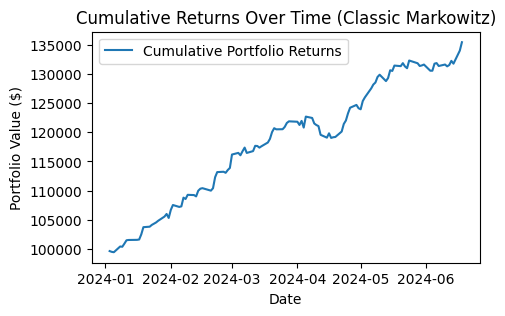

{Timestamp('2024-03-27 00:00:00'): np.float64(121579.15561615622), Timestamp('2024-06-18 00:00:00'): np.float64(135398.03942486667)}

Classic Markowitz Expected Returns:
Expected return on 2024-03-27 00:00:00: $121,579.16
Expected return on 2024-06-18 00:00:00: $135,398.04
Model Mean Squared Error (Classic Markowitz): 0.0
Model Mean Absolute Percentage Error (Classic Markowitz): 1.2772
Sortino Ratio (Classic Markowitz): 1.12 [The Sortino Ratio calculates a scheme's risk-adjusted returns and works effectively for cautious retail investors. 
 The Sortino ratio clearly shows how well a scheme's fund manager has been able to contain downside volatility, or returns that fall below-average returns, and produce promising gains.]
Treynor Ratio (Classic Markowitz): -0.06 [Treynor Ratio assesses a portfolio's excess return per unit of systematic risk, comparing returns to the market's performance.]
Portfolio Beta: 0.68
[A portfolio's beta measures its sensitivity to market movements compared to 

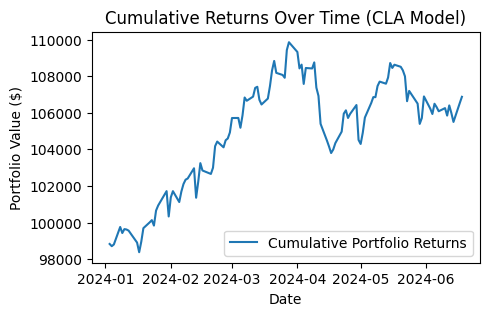

{Timestamp('2024-03-27 00:00:00'): np.float64(109430.54440170224), Timestamp('2024-06-18 00:00:00'): np.float64(106873.55316495952)}

CLA Model Expected Returns:
Expected return on 2024-03-27 00:00:00: $109,430.54
Expected return on 2024-06-18 00:00:00: $106,873.55
Model Mean Squared Error (CLA Model): 0.0
Model Mean Absolute Percentage Error (CLA Model): 1.2772
Sortino Ratio (CLA Model): 0.15 [The Sortino Ratio calculates a scheme's risk-adjusted returns and works effectively for cautious retail investors. 
 The Sortino ratio clearly shows how well a scheme's fund manager has been able to contain downside volatility, or returns that fall below-average returns, and produce promising gains.]
Treynor Ratio (CLA Model): -0.04 [Treynor Ratio assesses a portfolio's excess return per unit of systematic risk, comparing returns to the market's performance.]
Portfolio Beta: 1.01
[A portfolio's beta measures its sensitivity to market movements compared to a benchmark. A lower beta indicates lowe

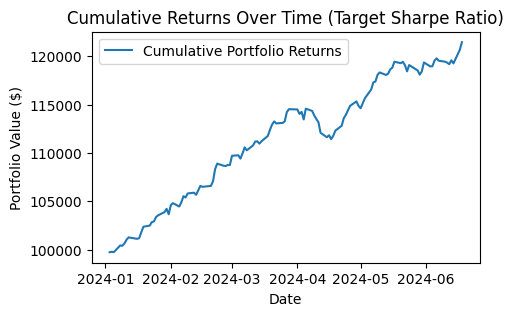

{Timestamp('2024-03-27 00:00:00'): np.float64(114227.16672388584), Timestamp('2024-06-18 00:00:00'): np.float64(121460.54345754962)}

Target Sharpe Ratio Expected Returns:
Expected return on 2024-03-27 00:00:00: $114,227.17
Expected return on 2024-06-18 00:00:00: $121,460.54
Model Mean Squared Error (Target Sharpe Ratio): 0.0
Model Mean Absolute Percentage Error (Target Sharpe Ratio): 1.2772
Sortino Ratio (Target Sharpe Ratio): 0.99 [The Sortino Ratio calculates a scheme's risk-adjusted returns and works effectively for cautious retail investors. 
 The Sortino ratio clearly shows how well a scheme's fund manager has been able to contain downside volatility, or returns that fall below-average returns, and produce promising gains.]
Treynor Ratio (Target Sharpe Ratio): -0.08 [Treynor Ratio assesses a portfolio's excess return per unit of systematic risk, comparing returns to the market's performance.]
Portfolio Beta: 0.54
[A portfolio's beta measures its sensitivity to market movements co

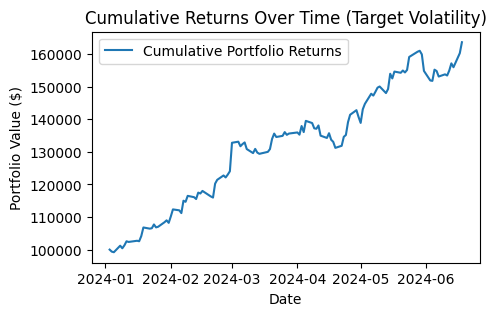

{Timestamp('2024-03-27 00:00:00'): np.float64(135230.09163148637), Timestamp('2024-06-18 00:00:00'): np.float64(163659.74425433093)}

Target Volatility Expected Returns:
Expected return on 2024-03-27 00:00:00: $135,230.09
Expected return on 2024-06-18 00:00:00: $163,659.74
Model Mean Squared Error (Target Volatility): 0.0
Model Mean Absolute Percentage Error (Target Volatility): 1.2772
Sortino Ratio (Target Volatility): 0.79 [The Sortino Ratio calculates a scheme's risk-adjusted returns and works effectively for cautious retail investors. 
 The Sortino ratio clearly shows how well a scheme's fund manager has been able to contain downside volatility, or returns that fall below-average returns, and produce promising gains.]
Treynor Ratio (Target Volatility): -0.04 [Treynor Ratio assesses a portfolio's excess return per unit of systematic risk, comparing returns to the market's performance.]
Portfolio Beta: 1.0
[A portfolio's beta measures its sensitivity to market movements compared to a

In [ ]:

#This works. still the best. the last one keep this only
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns
from pypfopt.plotting import plot_efficient_frontier
from tabulate import tabulate
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
from pypfopt.black_litterman import BlackLittermanModel
from datetime import datetime, timedelta
from pypfopt import black_litterman, risk_models, expected_returns, EfficientFrontier, plotting, objective_functions
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
from tabulate import tabulate
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers, blas

def calculate_period_returns(weighted_returns, initial_investment, periods):
    cumulative_returns = (1 + weighted_returns).cumprod()
    future_values = initial_investment * cumulative_returns

    # Handle missing dates by finding the nearest previous index
    returns = {period: future_values.asof(period) if period in future_values.index else future_values.asof(period) for period in periods}
    return returns


############
# Assuming this is your custom CLA function that outputs weights as a numpy array
def cla(cov_matrix, expected_returns):
    n = len(expected_returns)
    weights = np.array([1/n] * n)  # Simple start: equal weights
    return weights


def fetch_data(tickers, start_date, end_date):
    data = yf.download(tickers, start=start_date, end=end_date,progress=False)
    print(data.columns)

    return data['Close']

def fetch_market_caps(tickers):
    # Dummy function: define your method to fetch market caps here
    return {ticker: 1e10 for ticker in tickers}  # Example market cap

def calculate_period_returns(weighted_returns, initial_investment, periods):
    cumulative_returns = (1 + weighted_returns).cumprod()
    future_values = initial_investment * cumulative_returns
    returns = {period: future_values.loc[period] for period in periods}
    print(returns)
    return returns

def sortino_ratio(returns, risk_free_rate=0):
    downside_risk = np.std([min(0, r - risk_free_rate) for r in returns])
    expected_return = np.mean(returns)
    return (expected_return - risk_free_rate) / downside_risk if downside_risk != 0 else np.nan
# Function to fetch the latest prices
#latest_prices = fetch_latest_prices(tickers)
def fetch_latest_prices(tickers):
    prices = {}
    for ticker in tickers:
        ticker_data = yf.Ticker(ticker)
        prices[ticker] = ticker_data.history(period='1mo')['Close'].iloc[-1]
    return prices

def calculate_treynor_ratio(returns, beta, risk_free_rate=0):
    excess_return = returns.mean() - risk_free_rate
    treynor_ratio = excess_return / beta if beta != 0 else np.nan
    return treynor_ratio

def plot_efficient_frontier_with_portfolio(tickers, cleaned_weights):
    # Define the date range
    start_date = (datetime.today() - timedelta(days=365)).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')

    # Fetch historical data
    data = fetch_data(tickers, start_date, end_date)

    # Calculate expected returns and sample covariance
    mean_returns = expected_returns.mean_historical_return(data)
    cov_matrix = risk_models.sample_cov(data)
    risk_free_rate = 0.045

    # Generate portfolios
    ef = EfficientFrontier(mean_returns, cov_matrix)
    ef_max_sharpe = ef.max_sharpe()
    cleaned_weights = ef.clean_weights()

    # Filter non-zero weights
    non_zero_weights = {k: v for k, v in cleaned_weights.items() if v > 0}

    # Create a new instance of EfficientFrontier for plotting
    ef_plot = EfficientFrontier(mean_returns, cov_matrix)

    # Plot the Efficient Frontier with Sharpe ratio
    fig, ax = plt.subplots(figsize=(10, 7))

    # Plot the efficient frontier
    plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

    # Highlight the maximum Sharpe ratio portfolio
    performance = ef.portfolio_performance(verbose=True)
    sharpe_ratio = (performance[0] - risk_free_rate) / performance[1]
    ax.scatter(performance[1], performance[0], c='red', marker='*', s=100, label=f'Max Sharpe Ratio (Sharpe: {sharpe_ratio:.2f})')

    # Plot current portfolio
    latest_prices = data.iloc[-1]
    portfolio_val = latest_prices.dot(pd.Series(non_zero_weights))
    weights = np.array(list(non_zero_weights.values()))
    returns = np.dot(mean_returns, weights)
    volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    ax.scatter(volatility, returns, c='blue', marker='o', s=100, label='Current Portfolio')

    plt.title('Efficient Frontier and Selected Portfolio')
    plt.xlabel('Volatility (Standard Deviation)')
    plt.ylabel('Expected Return')
    plt.legend()
    plt.show()

    print(f"Non-Zero Weights: {non_zero_weights}")

##@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
# Step 2: Function to add data to the DataFrame

def add_metric(metric_name, value, approach_name):
    global metrics_data
    # Check if the metric already exists; if not, initialize a sub-dictionary
    if metric_name not in metrics_data:
        metrics_data[metric_name] = {}
    # Add or update the metric value under the appropriate approach
    metrics_data[metric_name][approach_name] = value

# Ensure calculate_capm and other required functions are defined

def optimize_and_print(approach_name, returns, S, mu, data, latest_prices):
    risk_free_rate = 0.045
    target_volatility = 0.20  # Example target volatility

    try:
        if approach_name == "CLA Model":
            ef = EfficientFrontier(mu, S)
            optimized_weights = cla(S, mu)
            cleaned_weights = pd.Series(optimized_weights, index=S.index).to_dict()

            # Manually calculate the portfolio performance for CLA
            weighted_returns = returns.dot(list(cleaned_weights.values()))
            expected_return = weighted_returns.mean() * 252
            volatility = weighted_returns.std() * np.sqrt(252)
            sharpe_ratio = (expected_return - risk_free_rate) / volatility
            ef_performance = (expected_return, volatility, sharpe_ratio)
        else:
            ef = EfficientFrontier(mu, S)
            if approach_name == "Target Sharpe Ratio":
                target_sharpe = 2.0  # Example Sharpe ratio
                target_return = risk_free_rate + target_sharpe * S.values.diagonal().mean()**0.5
                raw_weights = ef.efficient_return(target_return)
            elif approach_name == "Target Volatility":
                raw_weights = ef.efficient_risk(target_volatility)
            else:
                raw_weights = ef.max_sharpe(risk_free_rate=risk_free_rate)
            cleaned_weights = ef.clean_weights()
            ef_performance = ef.portfolio_performance(verbose=True, risk_free_rate=risk_free_rate)


        # Display the weights in a table
        portfolio_data = [(ticker, f"{weight:.2%}") for ticker, weight in cleaned_weights.items()]
        portfolio_data.append(("Expected Return", f"{ef_performance[0]:.2%}"))
        portfolio_data.append(("Volatility", f"{ef_performance[1]:.2%}"))
        portfolio_data.append(("Sharpe Ratio", f"{ef_performance[2]:.2f}"))
        print(f"\n{approach_name} Portfolio:", "  ++++++. Final ++++\n")
        # Example of adding metrics

        # Calculate weighted portfolio returns
        weighted_returns = returns.dot(list(cleaned_weights.values()))

        # Plot cumulative returns of the portfolio, assuming a $100,000 initial investment
        initial_investment = 100000
        cumulative_returns = (1 + weighted_returns).cumprod() * initial_investment

        plt.figure(figsize=(5, 3))
        plt.plot(cumulative_returns, label='Cumulative Portfolio Returns')
        plt.title(f'Cumulative Returns Over Time ({approach_name})')
        plt.xlabel('Date')
        plt.ylabel('Portfolio Value ($)')
        plt.legend()
        plt.show()

        # Calculate expected return for specific periods
        periods = [weighted_returns.index[int(len(weighted_returns)/2)], weighted_returns.index[-1]]
        period_returns = calculate_period_returns(weighted_returns, initial_investment, periods)
        print(f"\n{approach_name} Expected Returns:")
        for period, value in period_returns.items():
            print(f"Expected return on {period}: ${value:,.2f}")

        # Backtesting with RandomForest
        X = returns[:-1]
        y = returns[1:]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        predicted_returns = model.predict(X_test)
        mse = mean_squared_error(y_test.mean(axis=1), predicted_returns.mean(axis=1))
        mape = mean_absolute_percentage_error(y_test.mean(axis=1), predicted_returns.mean(axis=1))
        #print(f"Random Forest Predicted returns: {predicted_returns}")
        print(f"Model Mean Squared Error ({approach_name}):", round(mse, 4))
        print(f"Model Mean Absolute Percentage Error ({approach_name}):", round(mape, 4))

        # Sortino Ratio calculation
        sr = sortino_ratio(weighted_returns)
        print(f"Sortino Ratio ({approach_name}):", round(sr, 2), "[The Sortino Ratio calculates a scheme's risk-adjusted returns and works effectively for cautious retail investors. \n The Sortino ratio clearly shows how well a scheme's fund manager has been able to contain downside volatility, or returns that fall below-average returns, and produce promising gains.]")

        # Calculate portfolio beta (assuming equal weight benchmark like S&P 500)
        benchmark_returns = returns.mean(axis=1)
        portfolio_beta = np.cov(weighted_returns, benchmark_returns)[0, 1] / np.var(benchmark_returns)
        treynor_ratio = calculate_treynor_ratio(weighted_returns, portfolio_beta, risk_free_rate)
        print(f"Treynor Ratio ({approach_name}): {round(treynor_ratio, 2)} [Treynor Ratio assesses a portfolio's excess return per unit of systematic risk, comparing returns to the market's performance.]")
        print(f"Portfolio Beta: {round(portfolio_beta, 2)}")
        print(f"[A portfolio's beta measures its sensitivity to market movements compared to a benchmark. A lower beta indicates lower volatility relative to the market. Diversified portfolios typically aim for a beta close to that of a chosen benchmark, such as the S&P 500.] ")

        portfolio_data.append(("Treynor Ratio", treynor_ratio))

        # Discrete allocation
        portfolio_return = ef_performance[0]
        RMI = 0.24
        alpha = calculate_jensens_alpha(portfolio_return, risk_free_rate, RMI, portfolio_beta)
        portfolio_data.append(("Jenson Alpha", round(alpha, 2)))
        #print(f"Jensen's Alpha: {alpha:.4f}")
        latest_prices = data.iloc[-1]

        print(f"++++++{approach_name}. end of processing")
        # Assuming metrics_data is initialized correctly as a list somewhere in your code
        # Example debugging output

        # Convert to dictionary
        portfolio_dict = dict(portfolio_data)


        add_metric("Expected return ", portfolio_dict['Expected Return'],approach_name)
        add_metric("Sharpe Ratio", portfolio_dict['Sharpe Ratio'],approach_name)
        add_metric("Treynor Ratio", round(portfolio_dict['Treynor Ratio'],2),approach_name)
        add_metric('Sortino Ratio', round(sr,2),approach_name)
        add_metric("Jensen Alpha", portfolio_dict['Jenson Alpha'],approach_name)
        add_metric("Beta", round(portfolio_beta,2),approach_name)
        add_metric("Volatility", portfolio_dict['Volatility'],approach_name)




        print(f"+++++++. {approach_name}  portfolio recommendations on +++++++")
        latest_prices = data.iloc[-1]
        expected_market_return = 24.0
        one_year_growth = 0
        cumm_growth = 0
        std_dev = 1.55
        no_of_stocks = 0
        try:
            da = DiscreteAllocation(cleaned_weights, latest_prices, total_portfolio_value=100000)
            allocation, leftover = da.greedy_portfolio()
            portfolio_data = []
            total_investment = 0
            for ticker, weight in cleaned_weights.items():
                shares = allocation.get(ticker, 0)
                if shares > 0:
                    #print(f"{approach_name} Shares:{shares} {ticker}")
                    current_price = latest_prices[ticker]
                    investment = round(current_price * shares)
                    total_investment += investment
                    expected_return = calculate_capm(ticker, expected_market_return)
                    average_return, std_dev, beta = calculate_return_and_risk(ticker)
                    #print(f"Avg: {average_return} Exp: {expected_return}   -- {ticker}")
                    one_year_growth = investment * (1 + (expected_return / 100))
                    one_year_price = current_price * (1 + (expected_return / 100))
                    cumm_growth  += one_year_growth
                    no_of_stocks += 1
                    portfolio_data.append([ticker, f"{weight:.2%}", shares, f"${current_price:,.2f}", f"${investment:,.2f}", round(beta,2), round(std_dev,2),f"{round(average_return,2):.2f}%",f"${round(one_year_growth,2):,.2f}",f"${round(one_year_price,2):,.2f}"])
            print(f"No of stocks to buy: {no_of_stocks}")
            print(tabulate(portfolio_data, headers=["Ticker", "Weight", "Shares", "Current Price", "Investment", "Beta", "Std Dev","Avg.Ret","1Y Growth", "1Y Price"], tablefmt="grid"))
            print(f"Funds remaining ({approach_name}): ${leftover:.2f}, Total investment: ${total_investment:,.2f} ,Cummulative  : ${cumm_growth:,.2f}" "\n\n")

            # Write portfolio to Excel
            df = pd.DataFrame(portfolio_data, columns=["Ticker", "Weight", "Shares", "Current Price", "Investment", "Beta", "Std Dev","Avg.Ret","1Y Growth", "1Y Price"])
            df.to_excel(f"{approach_name}_portfolio.xlsx", index=False)
            print(f"Portfolio for {approach_name} written to {approach_name}_portfolio.xlsx")
        except Exception as e:
            print(f"Error during {approach_name} allocation:", e)
        return df
    except Exception as e:
        print(f"Error during {approach_name} optimization:", e)

    print(f"\n ======================== The End. ========================== \n\n")

    # Assuming portfolio_data is a list of dictionaries and you need the first dictionary
    # Correctly access the 'Jenson Alpha' from the first dictionary in the list


##@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
def calculate_jensens_alpha(ROI, RFR, RMI, beta):
    #print(ROI,RFR,beta,RMI)
    alpha = round(ROI - (RFR + beta * (RMI - RFR)),2)
    print(f"Jenson alpha:{alpha} [A positive alpha, is earned beyond what was required to compensate for the investment's risks.]")
    return alpha

def update_portfolio_capm(portfolio_data, risk_free_rate, expected_market_return):
    columns = ['Ticker', 'Weight', 'Shares', 'Current Price', 'Total Investment',
               'Beta', 'Std Dev', 'Avg Return', 'Projected Total', 'Projected Price']
    portfolio_df = pd.DataFrame(portfolio_data, columns=columns)

    # Ensure the 'Weight' column is in float format, stripping '%' and converting
    if portfolio_df['Weight'].dtype == object:
        portfolio_df['Weight'] = portfolio_df['Weight'].str.rstrip('%').astype('float') / 100

    # Ensure the price columns are in float format, removing '$' and commas, and converting
    price_columns = ['Current Price', 'Total Investment', 'Projected Total', 'Projected Price']
    for column in price_columns:
        if portfolio_df[column].dtype == object:
            portfolio_df[column] = portfolio_df[column].replace('[\$,]', '', regex=True).astype(float)

    # Calculate new CAPM expected returns
    portfolio_df['CAPM Return'] = risk_free_rate + portfolio_df['Beta'] * (expected_market_return - risk_free_rate)
    portfolio_df['CAPM Projected Price'] = portfolio_df['Current Price'] * (1 + portfolio_df['CAPM Return'])

    # Calculate the weighted CAPM Return for the portfolio
    portfolio_df['Weighted CAPM Return'] = portfolio_df['Weight'] * portfolio_df['CAPM Return']
    total_portfolio_capm_return = portfolio_df['Weighted CAPM Return'].sum()

    return portfolio_df.to_dict('records'), total_portfolio_capm_return


def calculate_capm(ticker, expected_market_return):
    # Risk-free rate (annualized percentage)
    risk_free_rate = 4.5 / 100

    # Fetch data for the ticker
    stock = yf.Ticker(ticker)
    hist = stock.history(period="1y")

    # Calculate daily returns
    hist['Daily Return'] = hist['Close'].pct_change()

    # Calculate average return and standard deviation (risk)
    avg_return = hist['Daily Return'].mean() * 252  # Annualize the daily return
    std_dev = hist['Daily Return'].std() * np.sqrt(252)  # Annualize the daily std deviation

    # Calculate the expected return using CAPM
    expected_return = risk_free_rate + beta * (expected_market_return - risk_free_rate)

    return expected_return

def calculate_return_and_risk(ticker, benchmark_ticker="^GSPC"):
    # Fetch historical market data for one year for both stock and benchmark
    stock = yf.Ticker(ticker)
    benchmark = yf.Ticker(benchmark_ticker)
    hist_stock = stock.history(period="1y")
    hist_benchmark = benchmark.history(period="1y")

    # Calculate daily returns for both stock and benchmark
    hist_stock['Daily Return'] = hist_stock['Close'].pct_change()
    hist_benchmark['Daily Return'] = hist_benchmark['Close'].pct_change()

    # Calculate beta
    covariance = np.cov(hist_stock['Daily Return'][1:], hist_benchmark['Daily Return'][1:])[0, 1]
    variance = np.var(hist_benchmark['Daily Return'][1:])
    beta = covariance / variance

    # Calculate average return and standard deviation (risk) for the stock
    avg_return = hist_stock['Daily Return'].mean() * 252  # Annualize the daily return
    std_dev = hist_stock['Daily Return'].std() * np.sqrt(252)  # Annualize the daily std deviation

    return avg_return, std_dev, beta
# Fetch S&P 500 historical data
sp500 = yf.Ticker("^GSPC")
data = sp500.history(period="5y")  # You can adjust the period as needed

# Calculate daily log returns
data['Log Returns'] = np.log(data['Close'] / data['Close'].shift(1))
mean_return = data['Log Returns'].mean() * 252  # Annualizing the daily returns

# Risk-free rate (example)
RFR = 0.02  # Example risk-free rate, typically a short-term government bond yield

# Portfolio information (example)
ROI = 0.12  # Portfolio return
beta = 1.3  # Portfolio beta

# Calculate RMI as the annualized mean return of the S&P 500
RMI = mean_return

# Calculate Jensen's Alpha


# Define tickers and fetch data


tickers =  wonderful

# Step 1: Initialize the DataFrame
metrics_data = {}

print(tickers)
#tickers = alpha_picks
#tickers = wonderful
# Fetch S&P 500 historical data
sp500 = yf.Ticker("^GSPC")
data = sp500.history(period="5y")  # You can adjust the period as needed

# Calculate daily log returns
data['Log Returns'] = np.log(data['Close'] / data['Close'].shift(1))
mean_return = data['Log Returns'].mean() * 252  # Annualizing the daily returns



# Calculate RMI as the annualized mean return of the S&P 500
RMI = round(mean_return,2)

#tickers = tickers + sandp_tickers
data = fetch_data(tickers, '2024-01-01', '2024-06-20')
returns = data.pct_change().dropna()
mu = expected_returns.mean_historical_return(data)
#S = risk_models.sample_cov(data)
S = risk_models.CovarianceShrinkage(data).ledoit_wolf()#
market_caps = fetch_market_caps(tickers)

# Define the views and link them to the assets
#viewdict = {"AAPL": 0.05, "MSFT": 0.04}  # Example: 5% expected return on AAPL, 4% on MSFT
viewdict = {}  # Example: 5% expected return on AAPL, 4% on MSFT
Q = pd.DataFrame(list(viewdict.values()), index=viewdict.keys(), columns=["View"])
P = pd.DataFrame(0, index=viewdict.keys(), columns=tickers)
for asset in viewdict.keys():
    P.loc[asset, asset] = 1
abs_viewdict = {"AAPL": 0.20, "MSFT": -0.30, "GOOGL": 0, "AMZN": -0.2, "META": 0.15}
# Define the headers you want to display

#bl = BlackLittermanModel(cov_matrix, absolute_views=viewdict)
# Define strategies
print(f"S&P over 5y:{(RMI * 100) :.2f}%")
portfolio = {}

approaches = {
    #"Black-Litterman": BlackLittermanModel(S, pi="market", P=P, Q=Q, omega="default", market_caps=market_caps).bl_returns(),
    #"Black-Litterman": BlackLittermanModel(S, pi="market", absolute_views=viewdict, omega="default", market_caps=market_caps).bl_returns(),
    #"Black-Litterman": BlackLittermanModel(S, pi="market",  omega="default", market_caps=market_caps).bl_returns(),
    "Classic Markowitz": mu,
    "CLA Model": mu,
    "Target Sharpe Ratio": mu,
    "Target Volatility":mu
}
print(f"Tickers: {tickers}")
latest_prices = fetch_latest_prices(tickers)
# Loop through each approach and optimize

for approach_name, approach_mu in approaches.items():
    print(f"++++++++++++++++++ {approach_name} begin processing. ++++++++++++")
    if approach_name == "HRP":
        # Special case for HRP if it needs different handling
        portfolio = optimize_and_print(approach_name, returns, S, None, data,latest_prices)
    else:
        portfolio = optimize_and_print(approach_name, returns, S, approach_mu, data,latest_prices)



In [ ]:
####!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
"""
    Optimizes a portfolio using the Black-Litterman model and returns the allocation weights and performance metrics.

    Parameters:
    tickers (list): List of ticker symbols.
    period (str): Period for downloading historical data. Default is "1y".
    views (dict): Views for the Black-Litterman model. Default is None.

    Returns:
    dict: Optimized weights.
    tuple: Performance metrics (expected return, volatility, Sharpe ratio).
"""
import yfinance as yf
import pandas as pd
from pypfopt import black_litterman, risk_models, EfficientFrontier, DiscreteAllocation
from pypfopt.black_litterman import BlackLittermanModel
from tabulate import tabulate

def optimize_bl_portfolio(tickers, period="1y", views=None):


    # Download historical data
    data = yf.download(tickers, period=period)['Close']

    # Fetch market caps
    market_caps = {}
    for ticker in tickers:
        stock = yf.Ticker(ticker)
        market_caps[ticker] = stock.info['marketCap']

    # Prepare data for calculations
    market_prices = data.iloc[-1]  # Assuming the last row is the most recent prices
    returns = data.pct_change().dropna()  # Calculate daily returns

    # Calculate the covariance matrix
    cov_matrix = risk_models.sample_cov(returns)

    # Calculate delta (market-implied risk aversion)
    delta = black_litterman.market_implied_risk_aversion(market_prices)
    print(f"Delta: {delta}")
    # Calculate the prior returns
    prior = black_litterman.market_implied_prior_returns(market_caps, delta, cov_matrix)

    # Create the Black-Litterman model
    bl = BlackLittermanModel(cov_matrix, absolute_views=views, pi=prior, market_caps=market_caps)

    # Calculate the posterior returns
    posterior = bl.bl_returns()

    # Create the Efficient Frontier object
    ef = EfficientFrontier(posterior, cov_matrix)

    # Optimize the portfolio for maximum Sharpe ratio
    weights = ef.max_sharpe()
    cleaned_weights = ef.clean_weights()
    print(f"Weights: {cleaned_weights}")
    # Get the performance metrics
    performance = ef.portfolio_performance(verbose=True)

    return cleaned_weights, performance, data

# Example usage
tickers = wonderful
#views = {"AAPL": 0.20, "MSFT": -0.30, "GOOGL": 0, "AMZN": -0.2, "META": 0.15}
views = {}
views = {"AAPL": 0.20, "MSFT": -0.30, "GOOGL": 0, "AMZN": -0.2, "META": 0.15}
weights, performance, data = optimize_bl_portfolio(tickers, period="1y", views=views)

print("Optimized Weights:", weights)
print("Performance Metrics:", performance)

approach_name = "BlackLittermanModel"
print(f"+++++++. {approach_name}  portfolio recommendations on +++++++")

latest_prices = data.iloc[-1]
total_portfolio_value = 100000  # Example total portfolio value

try:
    da = DiscreteAllocation(weights, latest_prices, total_portfolio_value=total_portfolio_value)
    allocation, leftover = da.greedy_portfolio()

    portfolio_data = []
    total_investment = 0
    expected_market_return = 24.0  # Example expected market return
    cumm_growth = 0
    no_of_stocks = 0

    for ticker, weight in weights.items():
        shares = allocation.get(ticker, 0)
        if shares > 0:
            current_price = latest_prices[ticker]
            investment = round(current_price * shares)
            total_investment += investment
            expected_return = 10000 #calculate_capm(ticker, expected_market_return)
            average_return, std_dev, beta = calculate_return_and_risk(ticker)

            one_year_growth = investment * (1 + (expected_return / 100))
            one_year_price = current_price * (1 + (expected_return / 100))
            cumm_growth += one_year_growth
            no_of_stocks += 1

            portfolio_data.append([
                ticker, f"{weight:.2%}", shares, f"${current_price:,.2f}", f"${investment:,.2f}",
                round(beta, 2), round(std_dev, 2), f"{round(average_return, 2):.2f}%", f"${round(one_year_growth, 2):,.2f}",
                f"${round(one_year_price, 2):,.2f}"
            ])

    print(f"No of stocks to buy: {no_of_stocks}")
    print(tabulate(portfolio_data, headers=[
        "Ticker", "Weight", "Shares", "Current Price", "Investment", "Beta", "Std Dev", "Avg. Ret",
        "1Y Growth", "1Y Price"
    ], tablefmt="grid"))
    print(f"Funds remaining ({approach_name}): ${leftover:.2f}, Total investment: ${total_investment:,.2f}, Cumulative Growth: ${cumm_growth:,.2f}")

    # Write portfolio to Excel
    df = pd.DataFrame(portfolio_data, columns=[
        "Ticker", "Weight", "Shares", "Current Price", "Investment", "Beta", "Std Dev", "Avg. Ret", "1Y Growth", "1Y Price"
    ])
    df.to_excel(f"{approach_name}_portfolio.xlsx", index=False)
    print(f"Portfolio for {approach_name} written to {approach_name}_portfolio.xlsx")

except Exception as e:
    print(f"Error during {approach_name} allocation:", e)

print("\n ======================== The End. ========================== \n\n")


[*********************100%***********************]  140 of 140 completed


Delta: 0.04115697446123956


/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


ValueError: Providing a view on an asset not in the universe

In [ ]:
"""
    Optimizes a portfolio using the Black-Litterman model and returns the allocation weights and performance metrics.

    Parameters:
    tickers (list): List of ticker symbols.
    period (str): Period for downloading historical data. Default is "1y".
    views (dict): Views for the Black-Litterman model. Default is None.

    Returns:
    dict: Optimized weights.
    tuple: Performance metrics (expected return, volatility, Sharpe ratio).
"""
import yfinance as yf
import pandas as pd
from pypfopt import black_litterman, risk_models, EfficientFrontier, DiscreteAllocation
from pypfopt.black_litterman import BlackLittermanModel
from tabulate import tabulate

def optimize_bl_portfolio(tickers, period="1y", views=None):
    # Download historical data
    data = yf.download(tickers, period=period)['Close']

    # Fetch market caps
    market_caps = {}
    for ticker in tickers:
        try:
            stock = yf.Ticker(ticker)
            market_caps[ticker] = stock.info.get('marketCap', 1e9)  # Default to 1B if market cap not found
        except:
            market_caps[ticker] = 1e9  # Default to 1B if any error occurs

    # Prepare data for calculations
    market_prices = data.iloc[-1]  # Assuming the last row is the most recent prices
    returns = data.pct_change().dropna()  # Calculate daily returns

    # Calculate the covariance matrix
    cov_matrix = risk_models.sample_cov(returns)

    # Calculate delta (market-implied risk aversion)
    delta = black_litterman.market_implied_risk_aversion(market_prices)
    print(f"Delta: {delta}")

    # Calculate the prior returns
    prior = black_litterman.market_implied_prior_returns(market_caps, delta, cov_matrix)

    # Create the Black-Litterman model
    bl = BlackLittermanModel(cov_matrix, pi=prior, absolute_views=views)

    # Calculate the posterior returns
    posterior = bl.bl_returns()

    # Create the Efficient Frontier object
    ef = EfficientFrontier(posterior, cov_matrix)

    # Optimize the portfolio for maximum Sharpe ratio
    weights = ef.max_sharpe()
    cleaned_weights = ef.clean_weights()
    print(f"Weights: {cleaned_weights}")

    # Get the performance metrics
    performance = ef.portfolio_performance(verbose=True)

    return cleaned_weights, performance, data

# Example usage
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]  # Example tickers
views = {"AAPL": 0.20, "MSFT": -0.30, "GOOGL": 0, "AMZN": -0.2, "META": 0.15}  # Example views
weights, performance, data = optimize_bl_portfolio(tickers, period="1y", views=views)

print("Optimized Weights:", weights)
print("Performance Metrics:", performance)

approach_name = "BlackLittermanModel"
print(f"+++++++. {approach_name} portfolio recommendations on +++++++")

latest_prices = data.iloc[-1]
total_portfolio_value = 100000  # Example total portfolio value

try:
    da = DiscreteAllocation(weights, latest_prices, total_portfolio_value=total_portfolio_value)
    allocation, leftover = da.greedy_portfolio()

    portfolio_data = []
    total_investment = 0
    expected_market_return = 24.0  # Example expected market return
    cumm_growth = 0
    no_of_stocks = 0

    for ticker, weight in weights.items():
        shares = allocation.get(ticker, 0)
        if shares > 0:
            current_price = latest_prices[ticker]
            investment = round(current_price * shares)
            total_investment += investment
            # These functions need to be defined or imported
            # expected_return = calculate_capm(ticker, expected_market_return)
            # average_return, std_dev, beta = calculate_return_and_risk(ticker)
            # For now, using placeholder values
            expected_return = 10  # Placeholder
            average_return, std_dev, beta = 10, 15, 1.0  # Placeholders

            one_year_growth = investment * (1 + (expected_return / 100))
            one_year_price = current_price * (1 + (expected_return / 100))
            cumm_growth += one_year_growth
            no_of_stocks += 1

            portfolio_data.append([
                ticker, f"{weight:.2%}", shares, f"${current_price:,.2f}", f"${investment:,.2f}",
                round(beta, 2), round(std_dev, 2), f"{round(average_return, 2):.2f}%", f"${round(one_year_growth, 2):,.2f}",
                f"${round(one_year_price, 2):,.2f}"
            ])

    print(f"No of stocks to buy: {no_of_stocks}")
    print(tabulate(portfolio_data, headers=[
        "Ticker", "Weight", "Shares", "Current Price", "Investment", "Beta", "Std Dev", "Avg. Ret",
        "1Y Growth", "1Y Price"
    ], tablefmt="grid"))
    print(f"Funds remaining ({approach_name}): ${leftover:.2f}, Total investment: ${total_investment:,.2f}, Cumulative Growth: ${cumm_growth:,.2f}")

    # Write portfolio to Excel
    df = pd.DataFrame(portfolio_data, columns=[
        "Ticker", "Weight", "Shares", "Current Price", "Investment", "Beta", "Std Dev", "Avg. Ret", "1Y Growth", "1Y Price"
    ])
    df.to_excel(f"{approach_name}_portfolio.xlsx", index=False)
    print(f"Portfolio for {approach_name} written to {approach_name}_portfolio.xlsx")

except Exception as e:
    print(f"Error during {approach_name} allocation:", e)

print("\n ======================== The End. ========================== \n\n")

[*********************100%***********************]  5 of 5 completed


Delta: 0.23193462817905852
ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.


/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


SolverError: 4

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from pypfopt import black_litterman, risk_models, EfficientFrontier, DiscreteAllocation
from pypfopt.black_litterman import BlackLittermanModel
from tabulate import tabulate

def generate_pq_matrices(views, asset_universe):
    """
    Generates the P and Q matrices for the Black-Litterman model.

    Parameters:
    views (list): List of views. Each view is a tuple of the form (view_type, assets, value),
                  where view_type is 'absolute' or 'relative', assets is a list of asset tickers involved in the view,
                  and value is the expected return or outperformance.
    asset_universe (list): List of all asset tickers in the universe.

    Returns:
    np.ndarray: P matrix.
    np.ndarray: Q matrix.
    """
    n_assets = len(asset_universe)
    P = []
    Q = []

    for view in views:
        view_type, assets, value = view

        # Initialize a row for the P matrix
        p_row = np.zeros(n_assets)

        if view_type == 'absolute':
            # Absolute view
            for asset in assets:
                idx = asset_universe.index(asset)
                p_row[idx] = 1
        elif view_type == 'relative':
            # Relative view
            for i, asset in enumerate(assets):
                idx = asset_universe.index(asset)
                p_row[idx] = 1 if i < len(assets) // 2 else -1

        P.append(p_row)
        Q.append(value)

    P = np.array(P)
    Q = np.array(Q).reshape(-1, 1)

    return P, Q

def optimize_bl_portfolio(tickers, period="1y", views=None):
    """
    Optimizes a portfolio using the Black-Litterman model and returns the allocation weights and performance metrics.

    Parameters:
    tickers (list): List of ticker symbols.
    period (str): Period for downloading historical data. Default is "1y".
    views (list): List of views for the Black-Litterman model. Default is None.

    Returns:
    dict: Optimized weights.
    tuple: Performance metrics (expected return, volatility, Sharpe ratio).
    """

    # Download historical data
    data = yf.download(tickers, period=period)['Close']

    # Fetch market caps
    market_caps = {}
    for ticker in tickers:
        stock = yf.Ticker(ticker)
        market_caps[ticker] = stock.info['marketCap']

    # Prepare data for calculations
    market_prices = data.iloc[-1]  # Assuming the last row is the most recent prices
    returns = data.pct_change().dropna()  # Calculate daily returns

    # Calculate the covariance matrix
    cov_matrix = risk_models.sample_cov(returns)

    # Ensure the covariance matrix is symmetric
    cov_matrix = (cov_matrix + cov_matrix.T) / 2

    # Calculate delta (market-implied risk aversion)
    delta = black_litterman.market_implied_risk_aversion(market_prices)

    # Calculate the prior returns
    prior = black_litterman.market_implied_prior_returns(market_caps, delta, cov_matrix)

    # Generate P and Q matrices from views
    if views is not None:
        P, Q = generate_pq_matrices(views, tickers)
    else:
        P, Q = None, None

    # Create the Black-Litterman model
    bl = BlackLittermanModel(cov_matrix, P=P, Q=Q, pi=prior, market_caps=market_caps)

    # Calculate the posterior returns
    posterior = bl.bl_returns()

    # Create the Efficient Frontier object
    ef = EfficientFrontier(posterior, cov_matrix)

    # Optimize the portfolio for maximum Sharpe ratio
    weights = ef.max_sharpe()
    cleaned_weights = ef.clean_weights()

    # Get the performance metrics
    performance = ef.portfolio_performance(verbose=True)

    return cleaned_weights, performance, data

# Example usage
tickers = ["SBUX", "GOOGL", "META", "AAPL", "BAC", "JPM", "T", "GE", "MSFT", "XOM"]
views = [
    ("absolute", ["SBUX"], -0.20),
    ("absolute", ["MSFT"], 0.05),
    ("relative", ["GOOGL", "META"], 0.10),
    ("relative", ["BAC", "JPM", "T", "GE"], 0.15)
]

weights, performance, data = optimize_bl_portfolio(tickers, period="1y", views=views)

print("Optimized Weights:", weights)
print("Performance Metrics:", performance)

approach_name = "BlackLittermanModel"
print(f"+++++++. {approach_name}  portfolio recommendations on +++++++")

latest_prices = data.iloc[-1]
total_portfolio_value = 100000  # Example total portfolio value

try:
    da = DiscreteAllocation(weights, latest_prices, total_portfolio_value=total_portfolio_value)
    allocation, leftover = da.greedy_portfolio()

    portfolio_data = []
    total_investment = 0
    expected_market_return = 24.0  # Example expected market return
    cumm_growth = 0
    no_of_stocks = 0

    for ticker, weight in weights.items():
        shares = allocation.get(ticker, 0)
        if shares > 0:
            current_price = latest_prices[ticker]
            investment = round(current_price * shares)
            total_investment += investment
            expected_return = calculate_capm(ticker, expected_market_return)
            average_return, std_dev, beta = calculate_return_and_risk(ticker)

            one_year_growth = investment * (1 + (expected_return / 100))
            one_year_price = current_price * (1 + (expected_return / 100))
            cumm_growth += one_year_growth
            no_of_stocks += 1

            portfolio_data.append([
                ticker, f"{weight:.2%}", shares, f"${current_price:,.2f}", f"${investment:,.2f}",
                round(beta, 2), round(std_dev, 2), f"{round(average_return, 2):.2f}%", f"${round(one_year_growth, 2):,.2f}",
                f"${round(one_year_price, 2):,.2f}"
            ])

    print(f"No of stocks to buy: {no_of_stocks}")
    print(tabulate(portfolio_data, headers=[
        "Ticker", "Weight", "Shares", "Current Price", "Investment", "Beta", "Std Dev", "Avg. Ret",
        "1Y Growth", "1Y Price"
    ], tablefmt="grid"))
    print(f"Funds remaining ({approach_name}): ${leftover:.2f}, Total investment: ${total_investment:,.2f}, Cumulative Growth: ${cumm_growth:,.2f}")

    # Write portfolio to Excel
    df = pd.DataFrame(portfolio_data, columns=[
        "Ticker", "Weight", "Shares", "Current Price", "Investment", "Beta", "Std Dev", "Avg. Ret", "1Y Growth", "1Y Price"
    ])
    df.to_excel(f"{approach_name}_portfolio.xlsx", index=False)
    print(f"Portfolio for {approach_name} written to {approach_name}_portfolio.xlsx")

except Exception as e:
    print(f"Error during {approach_name} allocation:", e)

print("\n ======================== The End. ========================== \n\n")


[*********************100%***********************]  10 of 10 completed


ERROR in LDL_factor: Error in KKT matrix LDL factorization when computing the nonzero elements. The problem seems to be non-convex
ERROR in osqp_setup: KKT matrix factorization.
The problem seems to be non-convex.


/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


OSQPException: 4

In [ ]:
import yfinance as yf
import pandas as pd
from tabulate import tabulate
from math import sqrt, isclose

def get_financial_ratios(ticker):
    try:
        stock = yf.Ticker(ticker)
        bvps = stock.info.get('bookValue', 0)
        eps = stock.info.get('trailingEps', 0)
        financials = {
            'Name': ticker,
            'Debt to Asset': stock.info.get('totalDebt', 0) / stock.info.get('totalAssets', 1),
            'Profit Margin': stock.info.get('profitMargins', 0),
            'ROIC': stock.info.get('returnOnEquity', 0),
            'BVPS': bvps,  # Book Value Per Share
            'EPS': eps  # Earnings Per Share
        }

        # Calculate Graham's Number if BVPS and EPS are positive
        if bvps > 0 and eps > 0:
            financials['Graham Number'] = sqrt(22.5 * bvps * eps)
        else:
            financials['Graham Number'] = None

        return financials
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return None

def is_wonderful_company(financials):
    # Define criteria for a wonderful company
    return (financials['Debt to Asset'] <= 0.35 and
            financials['Profit Margin'] >= 0.05 and
            financials['ROIC'] > 0.10)

# List of tickers to analyze
tickers = ['SFM', 'NTNX', 'MMYT', 'NHC', 'WM', 'NSIT', 'CAMT', 'SNEX', 'NVMI', 'PSN', 'INTU', 'REVG', 'UTI', 'SNV', 'TTEK', 'VRT', 'CSWI', 'HEI', 'BRFS', 'WTFC', 'GHM', 'APPF', 'SCHW', 'SFL', 'COR']

# Analyze each ticker
results = []
for ticker in tickers:
    try:
        financials = get_financial_ratios(ticker)
        if financials:
            print(f"Processing {ticker} - Debt to Asset: {financials['Debt to Asset']}, Profit Margin: {financials['Profit Margin']}, ROIC: {financials['ROIC']}, Graham Number: {financials['Graham Number']}")
            if is_wonderful_company(financials):
                results.append({
                    'Name': financials['Name'],
                    'Debt to Asset': financials['Debt to Asset'],
                    'Profit Margin': financials['Profit Margin'],
                    'ROIC': financials['ROIC'],
                    'Graham Number': financials['Graham Number']
                })
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

# Convert results to DataFrame for better readability
df_results = pd.DataFrame(results)

# Print the wonderful companies
print("Wonderful Companies:")
print(tabulate(df_results, headers='keys', tablefmt='grid'))


Processing SFM - Debt to Asset: 1653628032.0, Profit Margin: 0.0473, ROIC: 0.28558, Graham Number: 32.28782665339988
Processing NTNX - Debt to Asset: 695214976.0, Profit Margin: -0.05807, ROIC: 0, Graham Number: None
Processing MMYT - Debt to Asset: 228979008.0, Profit Margin: 0.26643, ROIC: 0.22604999, Graham Number: 21.081484767444632
Processing NHC - Debt to Asset: 231444992.0, Profit Margin: 0.101569995, ROIC: 0.13235, Graham Number: 107.00574423833517
Processing WM - Debt to Asset: 16652999680.0, Profit Margin: 0.12349, ROIC: 0.35025, Graham Number: 54.08643083066214
Processing NSIT - Debt to Asset: 1322008064.0, Profit Margin: 0.03421, ROIC: 0.17881, Graham Number: 99.73763833177523
Processing CAMT - Debt to Asset: 199112000.0, Profit Margin: 0.25928, ROIC: 0.21204, Graham Number: 23.169538191340802
Processing SNEX - Debt to Asset: 9487800320.0, Profit Margin: 0.00279, ROIC: 0.15985, Graham Number: 116.65187439557069
Processing NVMI - Debt to Asset: 241339008.0, Profit Margin: 0.

In [ ]:
##Select stocks based on Piotroski, Ohlson and Altman metrics
"""
The Criteria
1. A Piotroski F-Score of 9

2. An Ohlson O-Score Probability < 0.5

3. An Altman Z-Score > 1.9

4. Market Cap > $50M

That's it, four criteria. In all my time running this search, I have yet to have more than 20 stocks pop up. As I would like to s
tart tracking this portfolio on SeekingAlpha, I will be limiting things to ten stocks.
The stocks will be diverse in industry and size and whittled down via price-to-free-cash-flow. The higher P/FCF stocks will be kicked out of the final list.

"""
from os import P_ALL
# Checking if data is correctly sorted by date
#Final testing with sp500
from tabulate import tabulate
import yfinance as yf
import numpy as np
import requests
import json
import pandas as pd
from IPython.display import clear_output
def get_data(ticker):
    stock = yf.Ticker(ticker)
    data = {
        "financials": stock.financials.T,
        "balance_sheet": stock.balance_sheet.T,
        "history": stock.history(period="max"),
        "info": stock.info
    }
    return data



# Function to calculate Piotroski F-Score using yfinance data
def get_financial_data(ticker):
    stock = yf.Ticker(ticker)
    # Fetch the last 5 days of data and use the latest available data
    historical_data = stock.history(period="5d")
    latest_data = historical_data.dropna().iloc[-1] if not historical_data.dropna().empty else None
    data = get_data(ticker)
    # Calculate total_assets and total_liabilities once, since they are needed for both criteria
    if 'Total Assets' in data["balance_sheet"]:
        total_assets = data["balance_sheet"]["Total Assets"].iloc[0]
    else:
        total_assets = data["balance_sheet"]["Current Assets"].iloc[0]

    if 'Total Liabilities Net Minority Interest' in data["balance_sheet"]:
        total_liabilities = data["balance_sheet"]["Total Liabilities Net Minority Interest"].iloc[0]
    else:
        total_liabilities = data["balance_sheet"]["Total Liabilities"].iloc[0]

    current_assets = data["balance_sheet"]["Current Assets"].iloc[0]
    current_liabilities = data["balance_sheet"]["Current Liabilities"].iloc[0]
    long_term_debt = data["balance_sheet"]["Long Term Debt"].iloc[0]
    net_current_assets = current_assets - current_liabilities

    earnings_history = data["financials"]["Net Income"]
    dividend_history = data["history"]["Dividends"]
    current_price = data["history"]["Close"].iloc[-1]
    outstanding_shares = data["info"]['sharesOutstanding']

    # Retrieve PE ratio and PB ratio directly from Yahoo Finance
    gross_margins = data["info"].get('grossMargins', None)
    operating_cash_flow = data["info"].get('OperatingCashFlow', None)
    total_revenue = data["info"].get('totalRevenue', None)
    gross_profit = total_revenue * gross_margins
    net_income = data["info"].get('ebitda', None)

    if latest_data is None:
        print("No trading data available for the last 5 days.")
        return np.nan

    # Financial Statements
    bs = stock.balance_sheet.iloc[:, 0]  # Most recent year's data
    fs = stock.financials.iloc[:, 0]
    cf = stock.cashflow.iloc[:, 0]  # Assuming Operating Cash Flow is under 'cashflow'

    # Extracting necessary financial metrics

    #operating_cash_flow = cf.get('Operating Cash Flow', cf.get('Cash Flow From Continuing Operating Activities', 0))

    last_close = latest_data['Close']
    shares_outstanding = stock.info.get('sharesOutstanding', 0)
    market_value_of_equity = last_close * shares_outstanding
    operating_cash_flow = cf.get('Operating Cash Flow', cf.get('Cash Flow From Continuing Operating Activities', 0))
    sales = total_revenue
    """
    print(f"get_financial_data: {ticker}")
    print(f"TA={total_assets}, TL={total_liabilities}, CA={current_assets}, CL={current_liabilities},GP={gross_profit}, TR={total_revenue} ")
    print(f"NI={net_income}, FFO={operating_cash_flow}, Price={last_close}, Shares={shares_outstanding}, Sales={total_revenue}")
    """
    return total_assets,total_liabilities,current_assets,current_liabilities,net_income,operating_cash_flow,last_close,shares_outstanding, market_value_of_equity,sales
#Petroski calculation
"""
For a more specific interpretation, Piotroski's research suggests that investors can interpret the F-Score as follows:

0 or 1: The paper explicitly classifies firms with an F-Score of 0 or 1 as "low F_SCORE firms." These firms are considered the weakest financially and have
 the lowest likelihood of generating positive future returns.
2 to 7: The paper notes that most observations are clustered around F-Scores between 3 and 7, indicating that a vast majority of firms have mixed financial performance.
Firms with scores in this range have a mix of positive and negative signals, with higher scores indicating a relatively stronger financial position
and a better chance of generating positive returns compared to firms with lower scores.
8 or 9: The paper explicitly classifies firms with an F-Score of 8 or 9 as "high F_SCORE firms." These firms are considered the strongest financially and
have the highest likelihood of generating positive future returns.

"""
def calculate_piotroski_fscore(ticker):
    score = 0
    stock = yf.Ticker(ticker)
    fs = stock.financials
    bs = stock.balance_sheet
    cf = stock.cashflow
    info = stock.info

    # Safely access financial data with checks for existence and fallbacks
    net_income = fs.loc['Net Income'] if 'Net Income' in fs.index else pd.Series([0])
    op_cf = cf.loc['Cash Flow From Continuing Operating Activities'] if 'Cash Flow From Continuing Operating Activities' in cf.index else pd.Series([0])
    #"Cash Flow From Continuing Operating Activities"
    total_assets = bs.loc['Total Assets'] if 'Total Assets' in bs.index else pd.Series([0])
    long_term_debt = bs.loc['Long Term Debt'] if 'Long Term Debt' in bs.index else pd.Series([0])
    current_assets = bs.loc['Current Assets'] if 'Current Assets' in bs.index else pd.Series([0])
    current_liabilities = bs.loc['Current Liabilities'] if 'Current Liabilities' in bs.index else pd.Series([0])
    shares_outstanding = info.get('sharesOutstanding', 0)
    gross_profit = fs.loc['Gross Profit'] if 'Gross Profit' in fs.index else pd.Series([0])
    total_revenue = fs.loc['Total Revenue'] if 'Total Revenue' in fs.index else pd.Series([0])
# Safely access financial data
    gross_profit = fs.loc['Gross Profit'] if 'Gross Profit' in fs.index else pd.Series([0])
    total_revenue = fs.loc['Total Revenue'] if 'Total Revenue' in fs.index else pd.Series([0])

# Calculate Gross Margin safely
   # Calculation of Gross Margin with handling of zeros and NaNs
    if not total_revenue.isnull().all() and not gross_profit.isnull().all():  # Check if not all are NaN
        # Replace zeros in revenue to avoid division by zero
        total_revenue = total_revenue.replace({0: pd.NA})  # Use pd.NA for true missing values handling in Pandas

        gross_margin = gross_profit / total_revenue
        gross_margin = gross_margin.fillna(0)  # Replace NaN results with 0 (could be due to initial NaNs or division by zero)
    else:
        gross_margin = pd.Series([0]*len(total_revenue))  # Default to zero if no valid data

   # Validate non-empty and replace 0 in total_assets to avoid division by zero
    if not total_revenue.empty and not total_assets.empty:
        # Replace zeros with NaN for accurate NaN handling during division
        total_assets = total_assets.replace(0, pd.NA)

        # Calculate Asset Turnover Ratio
        asset_turnover = total_revenue.divide(total_assets).fillna(0)  # Fill NaN results with 0 after division
    else:
        asset_turnover = pd.Series([0]*len(total_revenue))  # Default all to zero if one is entirely empty

    # Piotroski Score Conditions
    if not net_income.empty and net_income.iloc[0] > 0:
        score += 1
        #print(f"1. NI: {net_income.iloc[0]}")
    if not op_cf.empty and op_cf.iloc[0] > 0:
        score += 1
        #print(f"2. CF: {op_cf.iloc[0]}")
    if not total_assets.empty and len(net_income) > 1 and (net_income / total_assets).iloc[0] > (net_income / total_assets).iloc[1]:
        score += 1
        #print(f"3. TA: {total_assets.iloc[0]}")

    if not op_cf.empty and not net_income.empty and op_cf.iloc[0] > net_income.iloc[0]:
        score += 1
        #print(f"4. CF<NI: {net_income.iloc[0]}")
    if not long_term_debt.empty and not total_assets.empty and len(long_term_debt) > 1 and (long_term_debt / total_assets).iloc[0] < (long_term_debt / total_assets).iloc[1]:
        score += 1
        #print(f"5. LT < prev: {long_term_debt.iloc[0]}")
    #print(current_assets.iloc[0],current_liabilities.iloc[-0],current_liabilities.iloc[-1])

    # Example: Ensure at least two data points exist
    if len(current_assets) > 1 and len(current_liabilities) > 1:
    # Calculate ratios for the most recent and the previous year
        current_ratio_latest = current_assets.iloc[0] / current_liabilities.iloc[0]
        current_ratio_prev = current_assets.iloc[1] / current_liabilities.iloc[1]
        #print(f"Current ratio:{current_ratio_latest}, Preve ratio: {current_ratio_prev}")
    # Check if the latest current ratio is greater than the previous year's
        if current_ratio_latest > current_ratio_prev:
            score += 1
            #print(f"6. CR > prev: {current_assets.iloc[0]}")
    change_in_shares, latest_shares, previous_shares = check_new_shares_issued(ticker)
    if latest_shares is not None and previous_shares is not None:
        if latest_shares <= previous_shares :
          score  += 1
            #print(f"7. No new: {change_in_shares}")
    if not gross_margin.empty and len(gross_margin) > 1 and gross_margin.iloc[0] > gross_margin.iloc[1]:
        score += 1
        #print(f"8. GM >: {gross_margin.iloc[0]}")
    if not asset_turnover.empty and len(asset_turnover) > 1 and asset_turnover.iloc[0] > asset_turnover.iloc[1]:
        score += 1
        #print(f"9. NI: {asset_turnover.iloc[0]}")

    return score

def check_new_shares_issued(ticker):
    stock = yf.Ticker(ticker)
    balance_sheet = stock.balance_sheet

    # Convert column headers to DateTime if they are not already
    if isinstance(balance_sheet.columns, pd.DatetimeIndex):
        # Ensure there are at least two years of data
        if len(balance_sheet.columns) >= 2:
            # Sort the columns to get the most recent years
            sorted_columns = balance_sheet.columns.sort_values(ascending=False)
            latest_year, previous_year = sorted_columns[0], sorted_columns[1]

            # Accessing shares number for the most recent and previous years
            latest_shares = balance_sheet.at['Ordinary Shares Number', latest_year] if 'Ordinary Shares Number' in balance_sheet.index else 0
            previous_shares = balance_sheet.at['Ordinary Shares Number', previous_year] if 'Ordinary Shares Number' in balance_sheet.index else 0

            # Calculate the change in shares issued
            change_in_shares = latest_shares - previous_shares
            return change_in_shares, latest_shares, previous_shares
        else:
            print("Not enough data to compare years.")
            return None, None, None
    else:
        print("Balance sheet data is not in the expected format.")
        return None, None, None

def calculate_altman_z_score(financials, balance_sheet, stock_info):
    try:
        #total_assets = balance_sheet.loc['Total Assets'].iloc[0]

        total_assets = balance_sheet['Total Assets'][0]
        print(total_assets)
        total_liabilities = balance_sheet['Total Liabilities Net Minority Interest'][0]
        retained_earnings = balance_sheet['Retained Earnings'][0]
        EBIT = financials['EBIT'][0]


        current_assets = balance_sheet['Current Assets'][0]
        current_liabilities = balance_sheet['Current Liabilities'][0]

        # Calculate necessary components
        working_capital = current_assets - current_liabilities
        market_value_of_equity = stock_info['marketCap']  # Assuming this is fetched from stock.info

        # Altman Z-Score Components
        X1 = working_capital / total_assets
        X2 = retained_earnings / total_assets
        X3 = EBIT / total_assets
        X4 = market_value_of_equity / total_liabilities
        X5 = total_revenue / total_assets

        # Altman Z-Score Calculation
        Z = 1.2 * X1 + 1.4 * X2 + 3.3 * X3 + 0.6 * X4 + 0.999 * X5
        Z = round(Z,2)
        return Z
    except KeyError as e:
        print(f"Missing data for calculation: {e}")
        return None




# Function to fetch financial data from yfinance
def fetch_stock_data(ticker,name_of_list):
    print(f"Processing {ticker} from {name_of_list}")
    stock = yf.Ticker(ticker)

    financials = stock.financials.transpose().infer_objects(copy=False).fillna(0)
    balance_sheet = stock.balance_sheet.transpose().infer_objects(copy=False).fillna(0)

    stock_info = stock.info
    market_cap = stock.info.get('marketCap', np.nan)  # Safe access to market cap
    history = stock.history(period="1d")
    price = history['Close'].iloc[-1] if not history['Close'].empty else np.nan  # Safe access to closing price
    cash_flow = stock_info.get('freeCashflow', 1)
    p_cf = round((market_cap / cash_flow),2)
    #print("{{}}", price, cash_flow, p_cf)
    # Ensure cash flow data is available before accessing it
    cf = stock.cashflow
    if 'Total Cash From Operating Activities' in cf.index and 'Capital Expenditures' in cf.index:
        oper_cash = cf.loc['Total Cash From Operating Activities'].dropna()
        cap_exp = cf.loc['Capital Expenditures'].dropna()
        free_cash_flow = oper_cash.iloc[0] - cap_exp.iloc[0] if not oper_cash.empty and not cap_exp.empty else np.nan
    else:
        free_cash_flow = np.nan  # Provide NaN if data is not available
    altman_z_score = calculate_altman_z_score(financials, balance_sheet, stock_info)
    #print(f"Altman Z-Score for {ticker}: {z_score}")
    my_ohlson = calculate_ohlson_oscore(ticker)
    piotroski_fscore = calculate_piotroski_fscore(ticker)
    #print(f"Ohlson O-Score for {ticker}: {my_ohlson}")
    return {
        'list_name':name_of_list,
        'ticker': ticker,
        'market_cap': market_cap,
        #'P/FCF': np.inf if free_cash_flow == 0 else price / free_cash_flow if free_cash_flow != 0 else np.nan,
        'P/FCF': p_cf,
        #'Piotroski_F_Score': calculate_piotroski_fscore(ticker),  # Assuming Piotroski F-Score function is defined elsewhere
        'Piotroski_F_Score': piotroski_fscore,  # Assuming Piotroski F-Score function is defined elsewhere

        #Ohlson_O_Score': calculate_ohlson_oscore(ticker),
        'Ohlson_O_Score': my_ohlson,
        #'Altman_Z_Score' : calculate_altman_z_score(financials, balance_sheet, stock_info)
        'Altman_Z_Score' : altman_z_score
    }
#************** revised ohlson


def calculate_ohlson_oscore(ticker):
    stock = yf.Ticker(ticker)
    historical_data = stock.history(period="5d")
    latest_data = historical_data.dropna().iloc[-1] if not historical_data.dropna().empty else None

    if latest_data is None:
        print("No trading data available for the last 5 days.")
        return np.nan

    if stock.balance_sheet.empty:
        print("Balance sheet data is not available.")
        return np.nan
    bs = stock.balance_sheet.iloc[:, 0]
    fs = stock.financials.iloc[:, 0]
    cf = stock.cashflow.iloc[:, 0]

    total_assets = bs.get('Total Assets', 0)
    total_liabilities = bs.get('Total Liabilities Net Minority Interest', 0)
    current_assets = bs.get('Current Assets', 0)
    current_liabilities = bs.get('Current Liabilities', 0)
    net_income = fs.get('Net Income', 0)
    operating_cash_flow = cf.get('Operating Cash Flow', cf.get('Cash Flow From Continuing Operating Activities', 0))
    last_close = latest_data['Close']
    shares_outstanding = stock.info.get('sharesOutstanding', 0)
    market_value_of_equity = last_close * shares_outstanding
    sales = fs.get('Total Revenue', 0)
 # Compute Ohlson O-Score components
    TA = total_assets
    TL = total_liabilities
    WC = current_assets - current_liabilities
    CL = current_liabilities
    NI = net_income
    FFO = operating_cash_flow
    MVE = market_value_of_equity
    CA = current_assets
    X1 = np.log(TA) if TA > 0 else 0
    X2 = TL / TA
    X3 = WC / TA
    X4 = CL / TA
    X5 = 1 if NI < 0 else 0
    X6 = NI / TA
    X7 = FFO / TL
    X8 = 1 if MVE < 0 else 0
    X9 = MVE / TL
    X10 = sales / TA
    if any(x <= 0 for x in [total_assets, total_liabilities, current_assets, current_liabilities, net_income, operating_cash_flow, shares_outstanding, sales]):
        print(f"Insufficient or invalid data for accurate calculation for {ticker}.")
        return np.nan

    O_score = (-1.32 - 0.407 * np.log(TA) + 6.03 * (TL / TA) - 1.43 * ((current_assets - current_liabilities) / TA) +
               0.0757 * (current_liabilities / TA) - 1.72 * (1 if net_income < 0 else 0) - 2.37 * (net_income / TA) -
               1.83 * (operating_cash_flow / TL) + 0.285 * (1 if market_value_of_equity < 0 else 0) +
               0.999 * (market_value_of_equity / TL) - 0.058 * (sales / TA))
    O_score_R = ohlson_oscore(TA, TL, CA, CL, NI, FFO, last_close, shares_outstanding, sales)
    #print(f"Ohlson O-Score for {ticker}: {O_score}, Revised:{O_score_R}")
    return round(O_score_R, 2)


import numpy as np

def ohlson_oscore(TA, TL, CA, CL, NI, FFO, price, shares, sales):
    """
    Calculate the Ohlson O-score for a given company using provided financial metrics.

    Parameters:
    - TA: Total Assets
    - TL: Total Liabilities
    - CA: Current Assets
    - CL: Current Liabilities
    - NI: Net Income
    - FFO: Funds From Operations
    - price: Current share price
    - shares: Number of shares outstanding
    - sales: Total Revenue

    Returns:
    - O_score: Calculated Ohlson O-score
    """
    # Calculate Market Value of Equity
    MVE = price * shares

    # Ohlson O-score components
    X1 = np.log(TA) / np.log(10)  # Log of total assets
    X2 = TL / TA                 # Total liabilities / Total assets
    X3 = (CA - CL) / TA          # Working capital / Total assets
    X4 = NI / TA                 # Net income / Total assets
    X5 = FFO / TL                # Funds from operations / Total liabilities
    X6 = MVE / TA                # Market value of equity / Total assets
    X7 = sales / TA              # Sales / Total assets

    # Ohlson O-score calculation
    Intercept = -1.32
    Coefficients = [0.407, 6.03, -1.43, 0, 0.076, -1.72, 0.285]

    O_score = Intercept + (Coefficients[0] * X1) + (Coefficients[1] * X2) + (Coefficients[2] * X3) + \
              (Coefficients[3] * X4) + (Coefficients[4] * X5) + (Coefficients[5] * X6) + (Coefficients[6] * X7)

    return O_score



#**********************


def filter_stocks(stocks_data):
    # Apply filtering conditions
    filtered_stocks = [
        stock for stock in stocks_data


       # if stock['Piotroski_F_Score'] > 5
       # and stock['Ohlson_O_Score'] < 0.5
       # and stock['Altman_Z_Score'] > 1.9
       # and stock['market_cap'] > 50_000_000
    ]
    all_sorted_stocks = sorted(filtered_stocks, key=lambda x: x['P/FCF'])
    return all_sorted_stocks

#Process starts here
#@@@@@@@@@@@@@@@@@@@@@

#### modify code to loop throuh June 11
######################
#Define all the tickers to be processed
leader = [
    "TVTX", "NTRA", "MRX", "AXON", "AGX", "APP", "SHOP", "HWM",
    "TVTX", "SFM", "POWL", "MRX", "LRN", "HOOD", "FIX", "CLS",
    "BKKT", "AGX", "NVDA", "NVDA", "VRT", "ROOT", "POWL", "AGX",
    "META", "HUBS", "VRT", "SFM", "ROOT", "POWL", "GRAL", "AGX",
    "OWL", "OWL", "SFM", "ROOT", "POWL", "PLTR", "LRN", "HUT"
]
alpha =  [
    "PYPL", "ALL", "LC", "QTWO", "CLS", "CCL", "AGX", "POWL", "PPC", "SYF",
    "ZETA", "RGA", "ATGE", "BRK-B", "SFM", "SKYW", "BLBD", "GM", "EAT", "RCL",
    "OKTA", "TWLO", "PEP", "MOD", "MHO", "APP", "MFC", "CLS", "ANF", "TMUS",
    "GOOGL", "STRL", "GRBK", "AMPH", "CRM", "UBER", "POWL", "CAAP", "URI",
    "MOD", "MHO"
]

####################
#ticker_lists = {"Whale Wisdom": whale_wisdom }
#ticker_lists = {"Leader": leader, "Whale Wisdom": whale_wisdom, "Alpha":alpha }
ticker_lists = chosen
print(ticker_lists)
ticker_lists = {"Selected Stocks": chosen } # Now it's a dictionary

selected_stocks = []  # Initialize the list to hold all selected stocks

# Iterate over each list of tickers and the corresponding name
for list_name, tickers in ticker_lists.items():
    for ticker in tickers:
        try:
            # Fetch stock data for each ticker
            stock_data = fetch_stock_data(ticker, list_name)
            #print(stock_data)
            # Filter the stock data and add to selected stocks if it meets criteria
            stocks = filter_stocks([stock_data])  # Ensure filter_stocks can handle list input
            selected_stocks.extend(stocks)
        except Exception as e:
            print(f"Error processing {ticker} from {list_name}: {str(e)}")

# Prepare a list of unique selected tickers to prevent duplicates
selected_list = list(set(stock['ticker'] for stock in selected_stocks))


# Printing selected and input stock data for verification
for stock in selected_stocks:
    print(f"Selected Stock: {stock['list_name']}, {stock['ticker']}, Piotroski: {stock['Piotroski_F_Score']}, Ohlson: {stock['Ohlson_O_Score']}, Altman_Z: {stock['Altman_Z_Score']}, Market Cap: {stock['market_cap']}, P/FCF: {stock['P/FCF']}")
# Assuming selected_stocks is a list of dictionaries
selected_stocks_df = pd.DataFrame(selected_stocks)
selected_stocks_df = selected_stocks_df.drop_duplicates()
# Counting occurrences of each unique value
ticker_counts = selected_stocks_df[ 'ticker'].value_counts()
print(ticker_counts)
list_name_counts = selected_stocks_df[ 'list_name'].value_counts()
print(list_name_counts)



# Sort by 'P/FCF' and select the top 10
# Printing selected and input stock data for verification

# Convert to DataFrame


# Filter out negative P/FCF values
positive_pfcf_stocks_df = selected_stocks_df[selected_stocks_df['P/FCF'] > 0]

# Sort by 'P/FCF' and select the top 10
print("============== Top 20 stocks with low P/FCF  - Undervalued ======================")
bottom_stocks_df = positive_pfcf_stocks_df.sort_values(by='P/FCF', ascending=True).head(20)
print(tabulate(bottom_stocks_df, headers='keys', tablefmt='pretty'))
# Print the top stocks
print("============== Stocks with positve P/FCF ======================")
print(tabulate(positive_pfcf_stocks_df, headers='keys', tablefmt='pretty'))

print("============== All Selected stocks which meet the criteria Piostoski > 5, Ohlson < .5 and Altman > 1.9  ================")
print(tabulate(selected_stocks_df, headers='keys', tablefmt='pretty'))
for stock in selected_stocks:
    print(f"Selected Stock: {stock['list_name']}, {stock['ticker']}, Piotroski: {stock['Piotroski_F_Score']}, Ohlson: {stock['Ohlson_O_Score']}, Altman_Z: {stock['Altman_Z_Score']}, Market Cap: {stock['market_cap']}, P/FCF: {stock['P/FCF']}")
print("============== All Selected list which meet the criteria Piostoski > 5, Ohlson < .5 and Altman > 1.9  ================")
print(selected_list)

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'ANSS', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CZR', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'CL', 'CMCSA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DVA', 'DAY', 'D

<ipython-input-22-d5e91223a4a0>:228: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_assets = balance_sheet['Total Assets'][0]
<ipython-input-22-d5e91223a4a0>:230: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_liabilities = balance_sheet['Total Liabilities Net Minority Interest'][0]
<ipython-input-22-d5e91223a4a0>:231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  retained_earnings = balance_sheet['Retained Earnings'][0]
<

39868000000.0
Error processing MMM from Selected Stocks: name 'total_revenue' is not defined
Processing AOS from Selected Stocks


<ipython-input-22-d5e91223a4a0>:228: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_assets = balance_sheet['Total Assets'][0]
<ipython-input-22-d5e91223a4a0>:230: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_liabilities = balance_sheet['Total Liabilities Net Minority Interest'][0]
<ipython-input-22-d5e91223a4a0>:231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  retained_earnings = balance_sheet['Retained Earnings'][0]
<

3240000000.0
Error processing AOS from Selected Stocks: name 'total_revenue' is not defined
Processing ABT from Selected Stocks


...

<ipython-input-22-d5e91223a4a0>:228: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_assets = balance_sheet['Total Assets'][0]
<ipython-input-22-d5e91223a4a0>:230: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_liabilities = balance_sheet['Total Liabilities Net Minority Interest'][0]
<ipython-input-22-d5e91223a4a0>:231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  retained_earnings = balance_sheet['Retained Earnings'][0]
<

27008900000.0
Error processing IVZ from Selected Stocks: name 'total_revenue' is not defined
Processing INVH from Selected Stocks


<ipython-input-22-d5e91223a4a0>:228: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_assets = balance_sheet['Total Assets'][0]
<ipython-input-22-d5e91223a4a0>:230: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_liabilities = balance_sheet['Total Liabilities Net Minority Interest'][0]
<ipython-input-22-d5e91223a4a0>:231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  retained_earnings = balance_sheet['Retained Earnings'][0]
<

18700951000.0
Error processing INVH from Selected Stocks: name 'total_revenue' is not defined
Processing IQV from Selected Stocks
26899000000.0
Error processing IQV from Selected Stocks: name 'total_revenue' is not defined
Selected Stock: Selected Stocks, AFL, Piotroski: 5, Ohlson: nan, Altman_Z: None, Market Cap: 56783941632, P/FCF: 10.75
Selected Stock: Selected Stocks, ARE, Piotroski: 7, Ohlson: 4.92, Altman_Z: None, Market Cap: 12524403712, P/FCF: 9.95
Selected Stock: Selected Stocks, ALL, Piotroski: 6, Ohlson: nan, Altman_Z: None, Market Cap: 53641531392, P/FCF: 12.91
Selected Stock: Selected Stocks, AXP, Piotroski: 7, Ohlson: nan, Altman_Z: None, Market Cap: 211788038144, P/FCF: 211788038144.0
Selected Stock: Selected Stocks, AIG, Piotroski: 4, Ohlson: nan, Altman_Z: None, Market Cap: 48204238848, P/FCF: 2.48
Selected Stock: Selected Stocks, AMP, Piotroski: 7, Ohlson: nan, Altman_Z: None, Market Cap: 49486286848, P/FCF: 14.88
Selected Stock: Selected Stocks, ACGL, Piotroski: 5, O

<ipython-input-22-d5e91223a4a0>:228: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_assets = balance_sheet['Total Assets'][0]
<ipython-input-22-d5e91223a4a0>:230: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_liabilities = balance_sheet['Total Liabilities Net Minority Interest'][0]
<ipython-input-22-d5e91223a4a0>:231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  retained_earnings = balance_sheet['Retained Earnings'][0]
<

In [ ]:
#DeepSeek optimized

import pandas as pd
import numpy as np
import yfinance as yf
from tabulate import tabulate

# Constants
MARKET_CAP_THRESHOLD = 50_000_000  # $50M
PIOTROSKI_THRESHOLD = 5
OHLSON_THRESHOLD = 0.5
ALTMAN_THRESHOLD = 1.9

# Define chosen list (Assuming it should be an empty list, replace with your desired tickers)
chosen = []

# Helper function to fetch financial data
def fetch_financial_data(ticker):
    stock = yf.Ticker(ticker)
    try:
        financials = stock.financials.transpose().infer_objects(copy=False).fillna(0)
        balance_sheet = stock.balance_sheet.transpose().infer_objects(copy=False).fillna(0)
        stock_info = stock.info
        history = stock.history(period="1d")
        price = history['Close'].iloc[-1] if not history.empty else np.nan
        return financials, balance_sheet, stock_info, price
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return None, None, None, None

# Calculate Piotroski F-Score
def calculate_piotroski_fscore(financials, balance_sheet):
    score = 0
    try:
        net_income = financials.get('Net Income', pd.Series([0]))
        op_cf = financials.get('Operating Cash Flow', pd.Series([0]))
        total_assets = balance_sheet.get('Total Assets', pd.Series([0])).astype(float) # Ensure float type
        long_term_debt = balance_sheet.get('Long Term Debt', pd.Series([0])).astype(float) # Ensure float type
        current_assets = balance_sheet.get('Current Assets', pd.Series([0])).astype(float) # Ensure float type
        current_liabilities = balance_sheet.get('Current Liabilities', pd.Series([0])).astype(float) # Ensure float type
        gross_profit = financials.get('Gross Profit', pd.Series([0]))
        total_revenue = financials.get('Total Revenue', pd.Series([0]))

        # Piotroski Score Conditions - Check for sufficient data points before comparison
        if not net_income.empty and net_income.iloc[0] > 0: score += 1
        if not op_cf.empty and op_cf.iloc[0] > 0: score += 1
        if len(net_income) > 1 and len(total_assets) > 1 and (net_income / total_assets).iloc[0] > (net_income / total_assets).iloc[1]: score += 1
        if not op_cf.empty and not net_income.empty and op_cf.iloc[0] > net_income.iloc[0]: score += 1
        if len(long_term_debt) > 1 and len(total_assets) > 1 and (long_term_debt / total_assets).iloc[0] < (long_term_debt / total_assets).iloc[1]: score += 1
        if len(current_assets) > 1 and len(current_liabilities) > 1 and (current_assets / current_liabilities).iloc[0] > (current_assets / current_liabilities).iloc[1]: score += 1
        if len(gross_profit) > 1 and gross_profit.iloc[0] > gross_profit.iloc[1]: score += 1
        if len(total_revenue) > 1 and len(total_assets) > 1 and (total_revenue / total_assets).iloc[0] > (total_revenue / total_assets).iloc[1]: score += 1
    except Exception as e:
        print(f"Error calculating Piotroski F-Score: {e}")
    return score

# Calculate Altman Z-Score
def calculate_altman_z_score(financials, balance_sheet, stock_info):
    try:
        total_assets = balance_sheet.get('Total Assets', pd.Series([0])).iloc[0]
        total_liabilities = balance_sheet.get('Total Liabilities', balance_sheet.get('Total Liabilities Net Minority Interest', pd.Series([0]))).iloc[0]
        retained_earnings = balance_sheet.get('Retained Earnings', pd.Series([0])).iloc[0]
        ebit = financials.get('EBIT', pd.Series([0])).iloc[0]
        current_assets = balance_sheet.get('Current Assets', pd.Series([0])).iloc[0]
        current_liabilities = balance_sheet.get('Current Liabilities', pd.Series([0])).iloc[0]
        market_value_of_equity = stock_info.get('marketCap', 0)

        # Altman Z-Score Components
        X1 = (current_assets - current_liabilities) / total_assets
        X2 = retained_earnings / total_assets
        X3 = ebit / total_assets
        X4 = market_value_of_equity / total_liabilities
        X5 = financials.get('Total Revenue', pd.Series([0])).iloc[0] / total_assets

        Z = 1.2 * X1 + 1.4 * X2 + 3.3 * X3 + 0.6 * X4 + 0.999 * X5
        return round(Z, 2)
    except Exception as e:
        print(f"Error calculating Altman Z-Score: {e}")
        return None

# Calculate Ohlson O-Score
def calculate_ohlson_oscore(financials, balance_sheet, stock_info, price):
    try:
        total_assets = balance_sheet.get('Total Assets', pd.Series([0])).iloc[0]
        total_liabilities = balance_sheet.get('Total Liabilities', balance_sheet.get('Total Liabilities Net Minority Interest', pd.Series([0]))).iloc[0]
        current_assets = balance_sheet.get('Current Assets', pd.Series([0])).iloc[0]
        current_liabilities = balance_sheet.get('Current Liabilities', pd.Series([0])).iloc[0]
        net_income = financials.get('Net Income', pd.Series([0])).iloc[0]
        op_cf = financials.get('Operating Cash Flow', pd.Series([0])).iloc[0]
        shares_outstanding = stock_info.get('sharesOutstanding', 0)
        sales = financials.get('Total Revenue', pd.Series([0])).iloc[0]

        # Ohlson O-Score Calculation
        O_score = (-1.32 - 0.407 * np.log(total_assets) + 6.03 * (total_liabilities / total_assets) -
                   1.43 * ((current_assets - current_liabilities) / total_assets) +
                   0.0757 * (current_liabilities / total_assets) - 1.72 * (1 if net_income < 0 else 0) -
                   2.37 * (net_income / total_assets) - 1.83 * (op_cf / total_liabilities) +
                   0.285 * (1 if (price * shares_outstanding) < 0 else 0) +
                   0.999 * ((price * shares_outstanding) / total_liabilities) - 0.058 * (sales / total_assets))
        return round(O_score, 2)
    except Exception as e:
        print(f"Error calculating Ohlson O-Score: {e}")
        return None

# Fetch and process stock data
def fetch_stock_data(ticker, list_name):
    financials, balance_sheet, stock_info, price = fetch_financial_data(ticker)
    if financials is None:
        return None

    market_cap = stock_info.get('marketCap', 0)
    p_fcf = round((market_cap / stock_info.get('freeCashflow', 1)), 2) if stock_info.get('freeCashflow', 1) != 0 else np.nan
    piotroski_fscore = calculate_piotroski_fscore(financials, balance_sheet)
    altman_z_score = calculate_altman_z_score(financials, balance_sheet, stock_info)
    ohlson_oscore = calculate_ohlson_oscore(financials, balance_sheet, stock_info, price)

    return {
        'list_name': list_name,
        'ticker': ticker,
        'market_cap': market_cap,
        'P/FCF': p_fcf,
        'Piotroski_F_Score': piotroski_fscore,
        'Ohlson_O_Score': ohlson_oscore,
        'Altman_Z_Score': altman_z_score
    }

# Filter stocks based on criteria
def filter_stocks(stocks_data):
    filtered_stocks = []
    for stock in stocks_data:
        # Skip stocks with None values in critical fields
        if (stock['Piotroski_F_Score'] is not None and
            stock['Ohlson_O_Score'] is not None and
            stock['Altman_Z_Score'] is not None and
            stock['market_cap'] is not None):
            if (stock['Piotroski_F_Score'] > PIOTROSKI_THRESHOLD and
                stock['Ohlson_O_Score'] < OHLSON_THRESHOLD and
                stock['Altman_Z_Score'] > ALTMAN_THRESHOLD and
                stock['market_cap'] > MARKET_CAP_THRESHOLD):
                filtered_stocks.append(stock)
    return filtered_stocks

# Main execution
if __name__ == "__main__":
    # Define ticker lists


    #ticker_lists = {"Leader": leader, "Whale": whale_wisdom, "My List": my_list, "alpha":alpha}
    ticker_lists = {"Chosen": chosen}
    print(ticker_lists)

    # Initialize selected_list and selected_stocks
    selected_list = []
    selected_stocks = []

    # Process tickers
    for list_name, tickers in ticker_lists.items():
        for ticker in tickers:
            stock_data = fetch_stock_data(ticker, list_name)
            if stock_data:
                selected_stocks.append(stock_data)
                selected_list.append(ticker)

    # Debug: Print selected_list
    print("Selected List:", selected_list)
    # Filter and sort stocks
    filtered_stocks = filter_stocks(selected_stocks)
    positive_pfcf_stocks = [stock for stock in filtered_stocks if stock['P/FCF'] > 0]
    sorted_stocks = sorted(positive_pfcf_stocks, key=lambda x: x['P/FCF'])

    # Display results
    print("============== Top 20 Stocks with Low P/FCF ======================")
    print(tabulate(sorted_stocks[:20], headers='keys', tablefmt='pretty'))

    print("============== All Filtered Stocks ================")
    print(tabulate(filtered_stocks, headers='keys', tablefmt='pretty'))

    print("============== All Selected Stocks ================")
    print(tabulate(selected_stocks, headers='keys', tablefmt='pretty'))
    # Prepare a list of unique selected tickers to prevent duplicates
    selected_list = list(set(stock['ticker'] for stock in selected_stocks))
    print("============== All Selected list ================")
    print(selected_list)

NameError: name 'chosen' is not defined

In [ ]:
#DeepSeek optimized -- 4/16/25

import pandas as pd
import numpy as np
import yfinance as yf
from tabulate import tabulate
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# Constants
MARKET_CAP_THRESHOLD = 50_000_000  # $50M
PIOTROSKI_THRESHOLD = 5
OHLSON_THRESHOLD = 0.5
ALTMAN_THRESHOLD = 1.9
MAX_WORKERS = 10  # For parallel processing

class StockAnalyzer:
    def __init__(self):
        self.ticker_lists = self._initialize_ticker_lists()

    def _initialize_ticker_lists(self):
        """Initialize and return the dictionary of ticker lists"""
        return {"CHOSEN": chosen        }

    @staticmethod
    def fetch_financial_data(ticker):
        """Fetch financial data for a single ticker"""
        stock = yf.Ticker(ticker)
        try:
            # Get data with timeout
            financials = stock.financials.transpose().infer_objects(copy=False).fillna(0)
            balance_sheet = stock.balance_sheet.transpose().infer_objects(copy=False).fillna(0)
            stock_info = stock.info
            history = stock.history(period="1d")
            price = history['Close'].iloc[-1] if not history.empty else np.nan

            # Validate we have required data
            if financials.empty or balance_sheet.empty:
                return None, None, None, None

            return financials, balance_sheet, stock_info, price
        except Exception as e:
            print(f"Error fetching data for {ticker}: {e}")
            return None, None, None, None

    @staticmethod
    def calculate_piotroski_fscore(financials, balance_sheet):
        """Calculate Piotroski F-Score with robust error handling"""
        score = 0
        try:
            # Safely extract financial metrics
            net_income = financials.get('Net Income', pd.Series([0]))
            op_cf = financials.get('Operating Cash Flow', pd.Series([0]))
            total_assets = balance_sheet.get('Total Assets', pd.Series([0]))
            long_term_debt = balance_sheet.get('Long Term Debt', pd.Series([0]))
            current_assets = balance_sheet.get('Current Assets', pd.Series([0]))
            current_liabilities = balance_sheet.get('Current Liabilities', pd.Series([0]))
            gross_profit = financials.get('Gross Profit', pd.Series([0]))
            total_revenue = financials.get('Total Revenue', pd.Series([0]))

            # Check we have at least 2 years of data for comparisons
            if len(net_income) < 2 or len(total_assets) < 2:
                return np.nan

            # Piotroski Score Conditions
            if net_income.iloc[0] > 0: score += 1
            if op_cf.iloc[0] > 0: score += 1
            if (net_income / total_assets).iloc[0] > (net_income / total_assets).iloc[1]: score += 1
            if op_cf.iloc[0] > net_income.iloc[0]: score += 1
            if (long_term_debt / total_assets).iloc[0] < (long_term_debt / total_assets).iloc[1]: score += 1
            if (current_assets / current_liabilities).iloc[0] > (current_assets / current_liabilities).iloc[1]: score += 1
            if gross_profit.iloc[0] > gross_profit.iloc[1]: score += 1
            if (total_revenue / total_assets).iloc[0] > (total_revenue / total_assets).iloc[1]: score += 1

            return score
        except Exception as e:
            print(f"Error calculating Piotroski F-Score: {e}")
            return np.nan

    @staticmethod
    def calculate_altman_z_score(financials, balance_sheet, stock_info):
        """Calculate Altman Z-Score with robust error handling"""
        try:
            total_assets = balance_sheet.get('Total Assets', pd.Series([0])).iloc[0]
            total_liabilities = balance_sheet.get('Total Liabilities',
                balance_sheet.get('Total Liabilities Net Minority Interest', pd.Series([0]))).iloc[0]
            retained_earnings = balance_sheet.get('Retained Earnings', pd.Series([0])).iloc[0]
            ebit = financials.get('EBIT', pd.Series([0])).iloc[0]
            current_assets = balance_sheet.get('Current Assets', pd.Series([0])).iloc[0]
            current_liabilities = balance_sheet.get('Current Liabilities', pd.Series([0])).iloc[0]
            market_value_of_equity = stock_info.get('marketCap', 0)

            # Calculate components with zero division protection
            X1 = (current_assets - current_liabilities) / total_assets if total_assets != 0 else 0
            X2 = retained_earnings / total_assets if total_assets != 0 else 0
            X3 = ebit / total_assets if total_assets != 0 else 0
            X4 = market_value_of_equity / total_liabilities if total_liabilities != 0 else 0
            X5 = financials.get('Total Revenue', pd.Series([0])).iloc[0] / total_assets if total_assets != 0 else 0

            Z = 1.2 * X1 + 1.4 * X2 + 3.3 * X3 + 0.6 * X4 + 0.999 * X5
            return round(Z, 2)
        except Exception as e:
            print(f"Error calculating Altman Z-Score: {e}")
            return None

    @staticmethod
    def calculate_ohlson_oscore(financials, balance_sheet, stock_info, price):
        """Calculate Ohlson O-Score with robust error handling"""
        try:
            total_assets = balance_sheet.get('Total Assets', pd.Series([0])).iloc[0]
            total_liabilities = balance_sheet.get('Total Liabilities',
                balance_sheet.get('Total Liabilities Net Minority Interest', pd.Series([0]))).iloc[0]
            current_assets = balance_sheet.get('Current Assets', pd.Series([0])).iloc[0]
            current_liabilities = balance_sheet.get('Current Liabilities', pd.Series([0])).iloc[0]
            net_income = financials.get('Net Income', pd.Series([0])).iloc[0]
            op_cf = financials.get('Operating Cash Flow', pd.Series([0])).iloc[0]
            shares_outstanding = stock_info.get('sharesOutstanding', 0)
            sales = financials.get('Total Revenue', pd.Series([0])).iloc[0]

            # Protect against invalid values
            if total_assets <= 0 or total_liabilities <= 0:
                return None

            # Ohlson O-Score Calculation
            O_score = (-1.32 - 0.407 * np.log(total_assets) +
                      6.03 * (total_liabilities / total_assets) -
                      1.43 * ((current_assets - current_liabilities) / total_assets) +
                      0.0757 * (current_liabilities / total_assets) -
                      1.72 * (1 if net_income < 0 else 0) -
                      2.37 * (net_income / total_assets) -
                      1.83 * (op_cf / total_liabilities if total_liabilities != 0 else 0) +
                      0.285 * (1 if (price * shares_outstanding) < 0 else 0) +
                      0.999 * ((price * shares_outstanding) / total_liabilities if total_liabilities != 0 else 0) -
                      0.058 * (sales / total_assets))
            return round(O_score, 2)
        except Exception as e:
            print(f"Error calculating Ohlson O-Score: {e}")
            return None

    def fetch_stock_data(self, ticker, list_name):
        """Fetch and process all data for a single stock"""
        financials, balance_sheet, stock_info, price = self.fetch_financial_data(ticker)
        if financials is None:
            return None

        try:
            market_cap = stock_info.get('marketCap', 0)
            free_cash_flow = stock_info.get('freeCashflow', 1)
            p_fcf = round((market_cap / free_cash_flow), 2) if free_cash_flow != 0 else np.nan
            piotroski_fscore = self.calculate_piotroski_fscore(financials, balance_sheet)
            altman_z_score = self.calculate_altman_z_score(financials, balance_sheet, stock_info)
            ohlson_oscore = self.calculate_ohlson_oscore(financials, balance_sheet, stock_info, price)

            return {
                'list_name': list_name,
                'ticker': ticker,
                'market_cap': market_cap,
                'P/FCF': p_fcf,
                'Piotroski_F_Score': piotroski_fscore,
                'Ohlson_O_Score': ohlson_oscore,
                'Altman_Z_Score': altman_z_score
            }
        except Exception as e:
            print(f"Error processing {ticker}: {e}")
            return None

    def filter_stocks(self, stocks_data):
        """Filter stocks based on investment criteria"""
        filtered_stocks = []
        for stock in stocks_data:
            if stock is None:
                continue

            try:
                meets_criteria = (
                    stock.get('Piotroski_F_Score', 0) > PIOTROSKI_THRESHOLD and
                    stock.get('Ohlson_O_Score', 1) < OHLSON_THRESHOLD and
                    stock.get('Altman_Z_Score', 0) > ALTMAN_THRESHOLD and
                    stock.get('market_cap', 0) > MARKET_CAP_THRESHOLD
                )
                if meets_criteria:
                    filtered_stocks.append(stock)
            except Exception as e:
                print(f"Error filtering stock {stock.get('ticker', 'unknown')}: {e}")

        return filtered_stocks

    def process_tickers(self):
        """Main method to process all tickers"""
        selected_stocks = []
        selected_tickers = set()  # To avoid duplicates

        print(f"Processing {sum(len(v) for v in self.ticker_lists.values())} tickers...")

        # Process tickers in parallel with progress bar
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = []
            for list_name, tickers in self.ticker_lists.items():
                for ticker in tickers:
                    if ticker not in selected_tickers:  # Avoid duplicates
                        futures.append(executor.submit(self.fetch_stock_data, ticker, list_name))
                        selected_tickers.add(ticker)

            # Process results as they complete
            for future in tqdm(as_completed(futures), total=len(futures), desc="Processing stocks"):
                result = future.result()
                if result:
                    selected_stocks.append(result)

        # Filter and sort results
        filtered_stocks = self.filter_stocks(selected_stocks)
        positive_pfcf_stocks = [s for s in filtered_stocks if s and s.get('P/FCF', np.nan) > 0]
        sorted_stocks = sorted(positive_pfcf_stocks, key=lambda x: x['P/FCF'])

        # Display results
        print("\n============== Top 20 Stocks with Low P/FCF ======================")
        print(tabulate(sorted_stocks[:20], headers='keys', tablefmt='pretty'))

        print("\n============== All Filtered Stocks ================")
        print(tabulate(filtered_stocks, headers='keys', tablefmt='pretty'))

        print("\n============== All Selected Stocks ================")
        print(tabulate(selected_stocks, headers='keys', tablefmt='pretty'))

        print("\n============== Unique Tickers Processed ================")
        print(sorted(selected_tickers))
        return selected_tickers
if __name__ == "__main__":
    analyzer = StockAnalyzer()
    selected_list = analyzer.process_tickers()

Processing 259 tickers...


Processing stocks:   3%|▎         | 8/259 [00:01<00:35,  7.09it/s]

Error calculating Piotroski F-Score: single positional indexer is out-of-bounds


Processing stocks:   4%|▍         | 11/259 [00:02<00:57,  4.31it/s]<ipython-input-25-d7a3c27ed69e>:70: RuntimeWarning: '<' not supported between instances of 'Timestamp' and 'int', sort order is undefined for incomparable objects.
  if (long_term_debt / total_assets).iloc[0] < (long_term_debt / total_assets).iloc[1]: score += 1
<ipython-input-25-d7a3c27ed69e>:70: RuntimeWarning: '<' not supported between instances of 'Timestamp' and 'int', sort order is undefined for incomparable objects.
  if (long_term_debt / total_assets).iloc[0] < (long_term_debt / total_assets).iloc[1]: score += 1
Processing stocks:   8%|▊         | 20/259 [00:03<00:34,  6.94it/s]

Error calculating Piotroski F-Score: single positional indexer is out-of-bounds


...

Error calculating Piotroski F-Score: single positional indexer is out-of-bounds
Error calculating Piotroski F-Score: single positional indexer is out-of-bounds


Processing stocks:  92%|█████████▏| 238/259 [00:38<00:03,  5.33it/s]

Error calculating Piotroski F-Score: single positional indexer is out-of-bounds
Error calculating Piotroski F-Score: single positional indexer is out-of-bounds


Processing stocks:  95%|█████████▍| 246/259 [00:39<00:01,  7.22it/s]<ipython-input-25-d7a3c27ed69e>:70: RuntimeWarning: '<' not supported between instances of 'Timestamp' and 'int', sort order is undefined for incomparable objects.
  if (long_term_debt / total_assets).iloc[0] < (long_term_debt / total_assets).iloc[1]: score += 1
<ipython-input-25-d7a3c27ed69e>:70: RuntimeWarning: '<' not supported between instances of 'Timestamp' and 'int', sort order is undefined for incomparable objects.
  if (long_term_debt / total_assets).iloc[0] < (long_term_debt / total_assets).iloc[1]: score += 1
Processing stocks:  98%|█████████▊| 255/259 [00:40<00:00,  9.37it/s]<ipython-input-25-d7a3c27ed69e>:70: RuntimeWarning: '<' not supported between instances of 'Timestamp' and 'int', sort order is undefined for incomparable objects.
  if (long_term_debt / total_assets).iloc[0] < (long_term_debt / total_assets).iloc[1]: score += 1
<ipython-input-25-d7a3c27ed69e>:70: RuntimeWarning: '<' not supported betwe


============== Top 20 Stocks with Low P/FCF ======================
+-----------+--------+-------------+-------+-------------------+----------------+----------------+
| list_name | ticker | market_cap  | P/FCF | Piotroski_F_Score | Ohlson_O_Score | Altman_Z_Score |
+-----------+--------+-------------+-------+-------------------+----------------+----------------+
|  CHOSEN   |  BKR   | 37826834432 | 22.03 |         6         |     -6.47      |      2.01      |
|  CHOSEN   |  AVY   | 14238121984 | 24.56 |         6         |     -4.19      |      3.75      |
|  CHOSEN   |  HUBB  | 20637048832 | 32.22 |         6         |     -1.88      |      5.93      |
|  CHOSEN   |  BALL  | 14644895744 | 58.17 |         6         |     -6.23      |      2.49      |
|  CHOSEN   |  COO   | 16348483584 | 67.28 |         6         |     -5.04      |      3.74      |
+-----------+--------+-------------+-------+-------------------+----------------+----------------+

============== All Filtered Stocks =====

In [ ]:
print(selected_list)

{'VRNA', 'META', 'ZETA', 'HUT', 'IWF', 'MCD', 'SYF', 'GE', 'TXN', 'GOOGL', 'SFM', 'PEP', 'VZ', 'RGA', 'PM', 'LLY', 'POWL', 'DE', 'ROOT', 'PFE', 'IJH', 'HUBS', 'VTI', 'AVGO', 'DHR', 'VEA', 'OWL', 'MSFT', 'GS', 'WMT', 'V', 'PLTR', 'TMO', 'BKKT', 'RTX', 'RDW', 'ADP', 'LRN', 'RKLB', 'TGT', 'MO', 'UPS', 'BLBD', 'STRL', 'TVTX', 'UNP', 'GWRE', 'T', 'TRV', 'HOOD', 'JNJ', 'CSCO', 'IJR', 'QCOM', 'GM', 'TSLA', 'LMT', 'INTU', 'ITRN', 'OKTA', 'MRK', 'CAT', 'HD', 'BMY', 'ALHC', 'ALL', 'IWM', 'CRDO', 'LC', 'DIS', 'NKE', 'JPM', 'AXP', 'GLD', 'MDLZ', 'EAT', 'VIG', 'IBM', 'CMCSA', 'PPC', 'TMUS', 'BA', 'VWO', 'ORCL', 'TJX', 'NFLX', 'HWM', 'COST', 'VTV', 'CAAP', 'NEE', 'QTWO', 'MA', 'LOW', 'AMGN', 'TSM', 'CVX', 'FIX', 'DUK', 'RCL', 'AMD', 'MMM', 'COP', 'MFC', 'CRM', 'KO', 'EZPW', 'NTRA', 'GOOG', 'AGX', 'AMAT', 'GRAL', 'ETN', 'BAC', 'ACN', 'HON', 'XOM', 'CLS', 'EMR', 'DOCS', 'UBER', 'CCL', 'AAPL', 'PG', 'DOW', 'ARQT', 'APP', 'VUG', 'SKYW', 'MRX', 'WM', 'COIN', 'BLK', 'VRT', 'PYPL', 'SBUX', 'ATGE', 'TWLO', 

In [ ]:
###Last edited 4/9/25
## June 10, 2024
#A copy of the above code or processing
#SAT May 20 version. Making this independent added volume Dupont ROE graham and P/CF
### Benjamin Grahams' Defensive stock selection criteria
"""
1. Not less than $100 million of annual sales.
2-A. Current assets should be at least twice current liabilities.
2-B. Long-term debt should not exceed the net current assets.
3. Some earnings for the common stock in each of the past ten years.
4. Uninterrupted [dividend] payments for at least the past 20 years.
5. A minimum increase of at least one-third in per-share earnings in the past ten years using three-year averages at the beginning and end.
6. Current price should not be more than 15 times average earnings of the past three years.
7. Current price should not be more than 1½ times the book value.
8. As a rule of thumb we suggest that the product of the multiplier times the ratio of price to book value should not exceed 22.5.
"""
#### More agressive
"""
1-A. Current assets at least 1½ times current liabilities.
1-B. Debt not more than 110% of net current assets.
2. Earnings stability: No deficit in the last five years covered in the Stock Guide.
3. Dividend record: Some current dividend.
4. Earnings growth: Last year's earnings more than those of 1966.
5. Price: Less than 120% net tangible assets.

"""
from ast import get_source_segment
import requests
from tabulate import tabulate
import numpy as np
import pandas as pd
import yfinance as yf
from pandas.tseries.offsets import BDay
import numpy as np
from datetime import datetime
from termcolor import colored
from IPython.display import clear_output
#import colorama
t_bill_rate = 0.0551  # 5.51% annual rate
inflation_rate = 0.03  # 3% annual inflation rate
#Constants
market_return = 0.25
inflation_rate = 0.03
t_bill_rate = 0.0551  # 5.51% annual rate
inflation_rate = 0.03  # 3% annual inflation rate
risk_free_rate = t_bill_rate - inflation_rate
investment = 10000
api_key = '0Ig9RMcl4CGJj4IYaZeVGo6bREoCD4pd'
#$$$$$$$$$$$$$$

#import pandas_ta as ta




def is_stock_overbought(symbol, period='14', rsi_threshold=70):
    """
    Check if a stock is overbought using the Relative Strength Index (RSI).
    """
    # Fetch historical stock data
    stock_data = yf.download(symbol, period="6mo", interval="1d", progress=False)

    # Check if data is empty
    if stock_data.empty:
        print(f"Warning: No data found for {symbol}. Skipping.")
        return False, None

    # Calculate RSI
    stock_data['RSI'] = ta.rsi(stock_data['Close'], length=int(period))

    # Check if RSI was successfully calculated
    if 'RSI' not in stock_data.columns or stock_data['RSI'].isnull().all():
        print(f"Warning: RSI could not be calculated for {symbol}.")
        return False, None

    # Get the latest RSI value
    latest_rsi = stock_data['RSI'].dropna().iloc[-1] if not stock_data['RSI'].dropna().empty else None

    # Determine if the stock is overbought
    is_overbought = latest_rsi > rsi_threshold if latest_rsi is not None else False

    return is_overbought, round(latest_rsi, 2) if latest_rsi is not None else None

def get_financial_data(ticker):
    stock = yf.Ticker(ticker)
    data = {
        "financials": stock.financials.T,
        "balance_sheet": stock.balance_sheet.T,
        "history": stock.history(period="max"),
        "info": stock.info
    }

    dict =  stock.info
    df = pd.DataFrame.from_dict(dict,orient='index')
    df = df.reset_index()
    return data
# Assuming data["balance_sheet"] is a DataFrame and get method is used to handle missing keys



def calculate_ratios(ticker):
    #print(data['balance_sheet'])
    data = get_financial_data(ticker)
    if 'industry' in data["info"]:
        industry = data["info"]['industry']
    else:
        industry = 'Unknown'
    if 'Total Revenue' in data["financials"] and not data["financials"]['Total Revenue'].empty:
        total_revenue = data["financials"]['Total Revenue'].sum()
    else: total_revenue = 1



    #current_liabilities = data["balance_sheet"].get('Current Liabilities', 0).iloc[0]
    #long_term_debt = data["balance_sheet"].get('Long Term Debt', 0).iloc[0]
    #total_assets = data["balance_sheet"].get('Total Assets', 0).iloc[0]
    #total_liabilities = data["balance_sheet"].get('Current Liabilities', 0).iloc[0]
    # Assuming data["balance_sheet"] is a DataFrame
    # Assuming data["balance_sheet"] is a DataFrame
    balance_sheet = data.get("balance_sheet", pd.DataFrame())

    try:
        current_assets = balance_sheet['Current assets'].iloc[0]
    except (KeyError, IndexError):
        current_assets = 1
    try:
        current_liabilities = balance_sheet['Current Liabilities'].iloc[0]
    except (KeyError, IndexError):
        current_liabilities = 1

    try:
        long_term_debt = balance_sheet['Long Term Debt'].iloc[0]
    except (KeyError, IndexError):
        long_term_debt = 1

    try:
        total_assets = balance_sheet['Total Assets'].iloc[0]
    except (KeyError, IndexError):
        total_assets = 1

    try:
        total_liabilities = balance_sheet['Current Liabilities'].iloc[0]
    except (KeyError, IndexError):
        total_liabilities = 1


    net_income = data["financials"].get('Net Income', 0)
    dividends = data["history"]['Dividends']
    if 'sharesOutstanding' in data["info"]:
        shares_outstanding = data["info"]['sharesOutstanding']
    else:
        shares_outstanding = 1
    #shares_outstanding = data["info"]['sharesOutstanding']
    earnings_history = net_income / shares_outstanding
    earnings_history = earnings_history.dropna()
    earnings_stability = (len(net_income[net_income > 0]) / 10) * 100
    tangible_book_value = data["balance_sheet"].get('Tangible Book Value', 0).iloc[0]
    #print(earnings_stability)
    #print(earnings_history)
    #val = ((earnings_history.iloc[0] / earnings_history.iloc[-1] - 1) * 100) / 33 * 100

    #print(f"growth: {earnings_history.iloc[0]} ,{earnings_history.iloc[-1]} {val}")
    ratios = {
        "size_in_sales": (total_revenue / 500_000_000) * 100,
        "current_assets_to_current_liabilities": (current_assets / (2 * current_liabilities)) * 100,
        "net_current_assets_to_long_term_debt": ((current_assets - current_liabilities) / long_term_debt) * 100,
        "earnings_stability": (len(net_income[net_income > 0]) / 3) * 100,
        "dividend_record": (len(dividends.dropna()) / 20) * 100,
        "earnings_growth": ((earnings_history.iloc[0] / earnings_history.iloc[-1] - 1) * 100) / 33 * 100,
        "graham_number": data["info"].get('trailingPE', 0) / data["info"].get('priceToBook', 0) * 100,
        "Institutions holding": data["info"].get('heldPercentInstitutions'),
        #"ncav_or_net_net": ((current_assets - total_liabilities) / shares_outstanding) * 100,
        "ncav_or_net_net": (tangible_book_value/ shares_outstanding),
        "equity_to_debt": ((2 * total_assets) / total_liabilities) * 100,
        "size_in_assets": (total_assets / 250_000_000) * 100
    }

    #print("Calculated Ratios:")
    #for key, value in ratios.items():
        #print(f"{key}: {value:.2f}%")
    status = evaluate_graham_criteria(ratios, industry)
    return ratios, status

def evaluate_graham_criteria(ratios, industry):
    defensive_requirements = [
        ratios["size_in_sales"] >= 100,
        ratios["current_assets_to_current_liabilities"] >= 100,
        ratios["net_current_assets_to_long_term_debt"] >= 100,
        ratios["earnings_stability"] >= 100,
        ratios["dividend_record"] >= 100,
        ratios["earnings_growth"] >= 100,
        ratios["graham_number"] >= 100,
        ratios["ncav_or_net_net"] >= 100,
        ratios["equity_to_debt"] >= 100,
        ratios["size_in_assets"] >= 100
    ]

    enterprising_requirements = [
        ratios["current_assets_to_current_liabilities"] >= 75,
        ratios["net_current_assets_to_long_term_debt"] >= 90,
        ratios["earnings_stability"] >= 50,
        ratios["dividend_record"] >= 5
    ]

    if industry in ["Utilities", "Financials"]:
        defensive_criteria_met = all(defensive_requirements[-2:])
    else:
        defensive_criteria_met = all(defensive_requirements[:6])

    enterprising_criteria_met = all(enterprising_requirements)

    return {
        "defensive": defensive_criteria_met,
        "enterprising": enterprising_criteria_met
    }


def get_stock_data(ticker):
    #print(ticker)
    stock = yf.Ticker(ticker)
    try:
        financials = stock.financials.T
        balance_sheet = stock.balance_sheet.T
        cashflow = stock.cashflow.T
        history = stock.history(period="max")
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return None

    data = {
        "ticker": ticker,
        "financials": financials,
        "balance_sheet": balance_sheet,
        "cashflow": cashflow,
        "history": history
    }
    return data
def get_financial_metrics(ticker_symbol):
    stock = yf.Ticker(ticker_symbol)
    eps = stock.info.get('trailingEps')
    growth = stock.info.get('earningsGrowth')
    market_cap = stock.info.get('marketCap')
    current_price = stock.info.get('currentPrice')
    forward_eps = stock.info.get('forwardEps')
    cashflow = stock.cashflow
    operating_cash_flow_label = 'Operating Cash Flow'

    if operating_cash_flow_label in cashflow.index:
        operating_cash_flow = cashflow.loc[operating_cash_flow_label].iloc[0]
    else:
        operating_cash_flow = None

    if growth is None or isinstance(growth, str) or growth < 0:
        try:
            growth = 0
        except (ValueError, TypeError):
            growth = 0 # Set default value to 1% if growth is None or cannot be converted to a float

    #print(eps, growth, market_cap, current_price, operating_cash_flow)
    return eps, growth, market_cap, current_price, forward_eps, operating_cash_flow

def get_aaa_corporate_bond_yield():
    return 2.41  # Assume a fixed value for simplicity

def calculate_intrinsic_value_ben_graham(eps, growth, aaa_yield):
    if eps is None:
        return None

    if aaa_yield <= 0:
        return None

    intrinsic_value = ((eps * 8.5 + 2 * growth * 100) * 4.4) / aaa_yield

    return intrinsic_value

def get_price_to_cash_flow_ratio(market_cap, operating_cash_flow):
    if operating_cash_flow is None or market_cap is None:
        return None

    if operating_cash_flow != 0:
        price_to_cash_flow_ratio = market_cap / operating_cash_flow
        return price_to_cash_flow_ratio
    else:
        return None

def evaluate_stock(ticker_symbol):
    # Get financial metrics
    financials = get_financial_metrics(ticker_symbol)
    eps, growth, market_cap, current_price, forward_eps, operating_cash_flow = financials

    if eps is None or market_cap is None or current_price is None or operating_cash_flow is None:
        return "One or more financial metrics are not available."

    # Get AAA corporate bond yield
    aaa_yield = get_aaa_corporate_bond_yield()

    # Calculate intrinsic value using Benjamin Graham's formula
    intrinsic_value = calculate_intrinsic_value_ben_graham(eps, growth, aaa_yield)
    if intrinsic_value is None:
        return "Intrinsic value calculation failed."

    # Calculate P/CF ratio
    p_cf_ratio = get_price_to_cash_flow_ratio(market_cap, operating_cash_flow)
    if p_cf_ratio is None:
        return "P/CF ratio calculation failed."

    # Calculate P/E ratios
    current_pe_ratio = current_price / eps if eps else None
    forward_pe_ratio = current_price / forward_eps if forward_eps else None

    # Calculate margin of safety
    margin_of_safety = (intrinsic_value - current_price) / intrinsic_value * 100

    # Determine Overvalued or Undervalued
    valuation = "Undervalued" if margin_of_safety > 0 else "Overvalued"

    # Determine Growth Potential or No Growth Potential
    #growth_potential = "Growth Potential" if forward_pe_ratio < current_pe_ratio else "No Growth Potential"
    growth_potential = "Growth Potential"

    analysis = {
        'Ticker': ticker_symbol,
        'P/CF Ratio': p_cf_ratio,
        'Intrinsic Value': intrinsic_value,
        'Stock Price': current_price,
        'Margin of Safety (%)': margin_of_safety,
        'Current P/E Ratio': current_pe_ratio,
        'Forward P/E Ratio': forward_pe_ratio,
        'Valuation': valuation,
        'Growth Potential': growth_potential
    }

    #print_pretty_stock_info(analysis)
    return analysis
##@@@@@@@@@@@@@@@@@@@@@@ Grahams
def get_stock_data(ticker):
    #print(ticker)
    stock = yf.Ticker(ticker)
    try:
        financials = stock.financials.T
        balance_sheet = stock.balance_sheet.T
        cashflow = stock.cashflow.T
        history = stock.history(period="max")
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return None

    data = {
        "ticker": ticker,
        "financials": financials,
        "balance_sheet": balance_sheet,
        "cashflow": cashflow,
        "history": history
    }
    return data

def meets_criteria(data):
    try:
        # Criteria 1: Annual sales of at least $100 million
        annual_sales = data["financials"]["Total Revenue"].sum()

        if annual_sales < 100000000:
            return False

        # Criteria 2A: Current assets should be at least twice current liabilities

        try:
            if 'Total Assets' in data["balance_sheet"]:
                current_assets = data["balance_sheet"]["Total Assets"].iloc[0]
            else:
                current_assets = data["balance_sheet"]["Current Assets"].iloc[0]

            if 'Total Current Liabilities' in data["balance_sheet"]:
                current_liabilities = data["balance_sheet"]["Total Current Liabilities"].iloc[0]
            else:
                current_liabilities = data["balance_sheet"]["Current Liabilities"].iloc[0]

        except KeyError:
            #print(f"Available balance sheet keys for {data['ticker']}: {data['balance_sheet'].columns.tolist()}")
            return False

        if current_assets < 2 * current_liabilities:
            return False

        #KeyError: 'Long Term Debt' not found for ticker HSII



        # Criteria 2B: Long-term debt should not exceed net current assets
        long_term_debt = data["balance_sheet"]["Long Term Debt"].iloc[0]
        net_current_assets = current_assets - current_liabilities
        #print(f"LT debt: {long_term_debt}")
        if long_term_debt > net_current_assets:
            return False
        #print(f"#2B:Checked Ok - LT debt {long_term_debt}")

        # Criteria 3: Some positive earnings for the common stock
        if 'Net Income' not in data["financials"]:
            return False
        earnings_history = data["financials"]["Net Income"]
        if (earnings_history < 0).any():
            return False

        # Convert earnings_history to a list or Series of values before checking for positive values
        earnings_values = earnings_history.values.tolist()  # or .to_series() if it's a single value

        if any(value < 0 for value in earnings_values): # changed from earnings_history to earnings_values
            return False

        # Criteria 4: Uninterrupted dividend payments (if available)
        dividend_history = data["history"]["Dividends"]
        if len(dividend_history.dropna()) >=  0:
            return True


        # Criteria 5: A minimum increase of at least one-third in per-share earnings over available history

        if len(earnings_history) >= 3:
            earnings_history_sorted = earnings_history.sort_index()  # Ensure earnings history is sorted
            earnings_start = earnings_history_sorted.iloc[0]
            earnings_end = earnings_history_sorted.iloc[-1]
            #print(f"earnings:{earnings_start},end:{earnings_end}")
            if earnings_end < 1.33 * earnings_start:
                #print(f"Checked earnings end is {earnings_end} is < 1.33 * {earnings_start}")
                return False

        #print(f"#5:Checked Ok - LT debt {earnings_start},{earnings_end}")
        # Criteria 6: Current price should not be more than 15 times average earnings of the past three years
        # Convert net income to EPS (earnings per share)
        outstanding_shares = data["outstanding_shares"]  # Ensure this data is available and accurate
        eps_history = earnings_history / outstanding_shares

        # Calculate the average EPS for the past three years

        #avg_earnings = earnings_history.iloc[:3].mean()
        avg_earnings = eps_history.iloc[:3].mean()
        current_price = data["history"]["Close"].iloc[-1]
        #print(f"Criteris #6 {avg_earnings}, {current_price}")
        if current_price > 15 * avg_earnings:
            return False
        #print(f"#6:Checked Ok - current_price > 15 * avg_earnings {avg_earnings},Current Price: {current_price}")
        # Criteria 7: Current price should not be more than 1.5 times the book value
        total_assets = data["balance_sheet"]["Total Assets"].iloc[0]
        total_liabilities = data["balance_sheet"]["Total Liabilities Net Minority Interest"].iloc[0]
        book_value = total_assets - total_liabilities
        if current_price > 1.5 * book_value:
            return False
        #print(f"#7:Checked Ok - current_price > 1.5 * book_value {book_value}, Current Price:{current_price}")
        # Criteria #8 Additional rule of thumb: product of multiplier times ratio of price to book value should not exceed 22.5
        pe_ratio = current_price / avg_earnings
        pb_ratio = current_price / book_value
        if pe_ratio * pb_ratio > 22.5:
            return False
        #print(f"#8:Checked Ok - cpe_ratio * pb_ratio > 22.5 {pe_ratio}, P/B{pb_ratio}")
        return True
    except KeyError as e:
        #print(f"KeyError: {e} not found for ticker {data['ticker']}")
        return False
    return
#################################
# Function to fetch financial data from Polygon.io
def fetch_financial_data(ticker, api_key):
    url = f"https://api.polygon.io/vX/reference/financials?ticker={ticker}&limit=1&apiKey={api_key}"
    response = requests.get(url)
    if response.status_code != 200:
        #print(f"Failed to fetch financial data for {ticker}. Status code: {response.status_code}")
        return None
    return response.json()

# Function to calculate Altman Z-Score using financial data from Polygon.io
def calculate_altman_z_score(ticker, api_key):
    try:
        data = fetch_financial_data(ticker, api_key)
        if not data or not data['results']:  # Check if 'results' list is empty
            #print(f"No financial data found for {ticker}.")
            return np.nan  # Return NaN if no data is found

        # Extract necessary financial data
        financials = data['results'][0]['financials']
        current_assets = financials['balance_sheet'].get('current_assets', {}).get('value', np.nan)
        total_assets = financials['balance_sheet'].get('assets', {}).get('value', np.nan)
        total_liabilities = financials['balance_sheet'].get('liabilities', {}).get('value', np.nan)
        retained_earnings = financials['balance_sheet'].get('equity', {}).get('value', np.nan)
        ebit = financials['income_statement'].get('income_loss_from_continuing_operations_before_tax', {}).get('value', np.nan)
        market_cap = financials['balance_sheet'].get('equity', {}).get('value', np.nan)  # Using equity as proxy for market cap
        sales = financials['income_statement'].get('revenues', {}).get('value', np.nan)
        working_capital = current_assets - financials['balance_sheet'].get('current_liabilities', {}).get('value', np.nan)

        if any(np.isnan(val) for val in [current_assets, total_assets, total_liabilities, retained_earnings, ebit, market_cap, sales, working_capital]):
            #print(f"Incomplete financial data for {ticker}.")
            return np.nan

        # Calculate Altman Z-Score
        X1 = working_capital / total_assets
        X2 = retained_earnings / total_assets
        X3 = ebit / total_assets
        X4 = market_cap / total_liabilities
        X5 = sales / total_assets

        z_score = 1.2 * X1 + 1.4 * X2 + 3.3 * X3 + 0.6 * X4 + X5

        return round(z_score,1)
    except KeyError as e:
        #print(f"Error: Key not found in JSON response for {ticker}. {e}")
        return np.nan  # Return NaN for missing keys
    except IndexError as e:
        #print(f"Error: Index out of range for {ticker}. {e}")
        return np.nan  # Return NaN for index out of range
# Function to fetch financial data from Polygon.io


##+++++++++++++++++++++++++++++++++
def calculate_returns(start_price, end_price):
    if pd.notna(start_price) and pd.notna(end_price):
        return ((end_price - start_price) / start_price) * 100
    return None

def calculate_excess_return(stock_return, index_return):
    if stock_return is not None and index_return is not None:
        return stock_return - index_return
    return None
def calculate_expected_capm_return(risk_free_rate, market_return, beta):
    """
    Calculate the expected return of an investment using CAPM.

    Parameters:
    risk_free_rate (float): The risk-free rate as a decimal (e.g., 0.02 for 2%)
    market_return (float): The expected market return as a decimal (e.g., 0.1 for 10%)
    beta (float): The beta of the investment

    Returns:
    float: The expected return of the investment as a decimal
    """
    expected_return = risk_free_rate + (beta * (market_return - risk_free_rate))
    return expected_return
def calculate_vwap(ticker: str, period: str = "1d"):
    # Fetch historical data using yfinance
    data = yf.Ticker(ticker).history(period=period)

    # Check if the data is empty
    if data.empty:
       # raise ValueError(f"No data found for ticker: {ticker}")
        vwap = 1
        return vwap
    # Calculate VWAP
    data['TP'] = (data['High'] + data['Low'] + data['Close']) / 3  # Typical Price
    data['Total'] = data['TP'] * data['Volume']  # Typical Price * Volume
    vwap = data['Total'].sum() / data['Volume'].sum()  # VWAP formula

    return vwap
def get_eps_values(ticker):
    # Get financials and information data for the stock
    stock = yf.Ticker(ticker)
    financials = stock.financials
    shares_outstanding = stock.info.get('sharesOutstanding', 1)

    # Calculate EPS (Earnings Per Share) values
    eps_values = financials.loc['Net Income'].dropna() / shares_outstanding


    # Convert EPS values to a string
    eps_string = ', '.join([f"{x:.2f}" for x in eps_values])

    return eps_string
def add_list_name(results_df, Fid_2k, Fid_8k):
    # Create a new column to store the list name

    results_df.insert(results_df.columns.get_loc("List") + 1, 'Portfolio', '')
    # Iterate over the rowsList"
    for index, row in results_df.iterrows():
        stock = row['Ticker']
        #meet_status = row['Rating']

        # Check if the stock is in Fidelity 2K or Fidelity 8K
        if stock in Fid_2k:
            results_df.at[index, 'Portfolio'] = 'Fid 2K'
        elif stock in Fid_8k:
            results_df.at[index, 'Portfolio'] = 'Fid 8K'

    return results_df

def get_yahoo_financials(ticker):
    stock = yf.Ticker(ticker)
    info = stock.info
    return info

def get_yahoo_balance_sheet(ticker):
    stock = yf.Ticker(ticker)
    balance_sheet = stock.balance_sheet
    return balance_sheet

def get_yahoo_financials_data(ticker):
    stock = yf.Ticker(ticker)
    financials = stock.financials
    return financials

def get_current_price(ticker):
    stock = yf.Ticker(ticker)
    history = stock.history(period="1d")
    return history['Close'][0]

def print_criteria_data(ticker, criteria_data, status_data):
    #print(f"\nTicker: {ticker}")
    for criterion, data in criteria_data.items():
        status = status_data.get(criterion, "Not Checked")
        #print(f"{criterion}: {data} - {status}")

def enterprising_stock_selection(ticker):
    criteria_data = {}
    status_data = {}
    criteria_not_met = []

    try:
        # Fetch data from Yahoo Finance
        info = get_yahoo_financials(ticker)
        balance_sheet = get_yahoo_balance_sheet(ticker)
        financials = get_yahoo_financials_data(ticker)

        # 1-A. Current assets at least 1½ times current liabilities.
        #current_assets = balance_sheet.loc['Current Assets'][0] if 'Current Assets' in balance_sheet.index else 0
        #current_liabilities = balance_sheet.loc['Current Liabilities'][0] if 'Current Liabilities' in balance_sheet.index else 0
        current_assets = balance_sheet.loc['Total Assets'][0] if 'Total Assets' in balance_sheet.index else 0
        current_liabilities = balance_sheet.loc['Current Liabilities'][0] if 'Current Liabilities' in balance_sheet.index else 0
        criteria_data['Current Assets'] = current_assets
        criteria_data['Current Liabilities'] = current_liabilities
        if current_assets >= 1.5 * current_liabilities:
            status_data['Current Assets vs Liabilities'] = "Pass"
            #print("1-A: Pass")
        else:
            status_data['Current Assets vs Liabilities'] = "Failed"
            criteria_not_met.append((ticker, "Current assets less than 1.5 times current liabilities"))
            #print_criteria_data(ticker, criteria_data, status_data)
            #print("1-A: Failed")
            return False

        #print(f"#1-A: Ticker: {ticker}, Is Current Assets: {current_assets}, >= Current Liabilities: 1.5 * {current_liabilities}")

        # 1-B. Debt not more than 110% of net current assets.
        total_debt = balance_sheet.loc['Long Term Debt'][0] if 'Long Term Debt' in balance_sheet.index else 0
        net_current_assets = current_assets - current_liabilities
        criteria_data['Total Debt'] = total_debt
        criteria_data['Net Current Assets'] = net_current_assets
        if total_debt <= 1.1 * net_current_assets:
            status_data['Debt vs Net Current Assets'] = "Pass"
            #print("1-B: Pass")
        else:
            status_data['Debt vs Net Current Assets'] = "Failed"
            criteria_not_met.append((ticker, "Total debt more than 110% of net current assets"))
            print_criteria_data(ticker, criteria_data, status_data)
            #print("1-B: Failed")
            return False

        #print(f"#1-B: Ticker: {ticker}, Total Debt: {total_debt}, Net Current Assets: {net_current_assets}")

#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
        # 2. Earnings stability: No deficit in the last three years
        earnings = financials.loc['Net Income'].values[::-1]  # Reverse to have the most recent earnings first
        if len(earnings) >= 3:
            criteria_data['Earnings Last 3 Years'] = earnings[:3]
            if all(e > 0 for e in earnings[:3]):
                status_data['Earnings Stability'] = "Pass"
                #print("2: Pass")
            else:
                status_data['Earnings Stability'] = "Failed"
                criteria_not_met.append((ticker, "Earnings deficit in the last three years"))
                #print_criteria_data(ticker, criteria_data, status_data)
                #print("2: Failed")
                return False
        else:
            status_data['Earnings Stability'] = "Not Enough Data"
            criteria_not_met.append((ticker, "Not enough data for earnings stability"))
            print_criteria_data(ticker, criteria_data, status_data)
            return False

#$$$$$$$$$$$$$$$$$$$$$$
        #print(f"#2: Ticker: {ticker}, Earnings Last 5 Years: {earnings[:5]}")

        # 3. Dividend record: Some current dividend
        dividend_yield = info.get('dividendYield', 0)
        criteria_data['Dividend Yield'] = dividend_yield
        if dividend_yield > 0:
            status_data['Dividend Record'] = "Pass"
            #print("3: Pass")
        else:
            #status_data['Dividend Record'] = "Failed"
            status_data['Dividend Record'] = "Pass"
            criteria_not_met.append((ticker, "No current dividend"))
            #print_criteria_data(ticker, criteria_data, status_data)
            #print("3: Failed")
            return False

        #print(f"#3: Ticker: {ticker}, Dividend Yield: {dividend_yield}")

        # 4. Earnings growth: This year's earnings should be more than the previous year's earnings
        if len(earnings) > 1:
            latest_year_earnings = earnings[len(earnings) - 1]
            previous_year_earnings = earnings[len(earnings) - 2]
            criteria_data['Latest Year Earnings'] = latest_year_earnings
            criteria_data['Previous Year Earnings'] = previous_year_earnings
            if latest_year_earnings > previous_year_earnings:
                status_data['Earnings Growth'] = "Pass"
                #print("4: Pass")
            else:
                status_data['Earnings Growth'] = "Failed"
                criteria_not_met.append((ticker, "This year's earnings not more than the previous year's earnings"))
                print_criteria_data(ticker, criteria_data, status_data)
                #print("4: Failed")
                #print(f"latest: {latest_year_earnings}, Prev: {previous_year_earnings}")
                return False
        else:
            status_data['Earnings Growth'] = "Not Enough Data"
            criteria_not_met.append((ticker, "Not enough data for earnings growth"))
            print_criteria_data(ticker, criteria_data, status_data)
            return False

        #print(f"# 4: Ticker: {ticker}, Latest Year's Earnings: {latest_year_earnings}, Previous Year's Earnings: {previous_year_earnings}")

        # 5. Price: Less than 120% net tangible assets
        tangible_assets = balance_sheet.loc['Total Assets'][0] - balance_sheet.loc['Goodwill'][0]
        total_assets = balance_sheet.loc['Total Assets'].iloc[0] - balance_sheet.loc['Goodwill'][0]

        net_tangible_assets = tangible_assets - balance_sheet.loc['Current Liabilities'][0]
        shares_outstanding = info.get('sharesOutstanding', 1)
        net_tangible_assets_per_share = net_tangible_assets / shares_outstanding

        current_price = get_current_price(ticker)
        criteria_data['Net Tangible Assets Per Share'] = net_tangible_assets_per_share
        criteria_data['Current Price'] = current_price
        #print(f" #5. Curr: {current_price} TA: {tangible_assets}, NTA: {net_tangible_assets}, NTA/S: {net_tangible_assets_per_share}")
        if current_price < 15 * net_tangible_assets_per_share:
            status_data['Price to Tangible Assets'] = "Pass"
            #print("5: Pass")
        else:
            status_data['Price to Tangible Assets'] = "Failed"
            criteria_not_met.append((ticker, "Price more than 400% of net tangible assets"))
            #print_criteria_data(ticker, criteria_data, status_data)
            #print("5: Failed")
            return False

        #print(f"Ticker: {ticker}, Net Tangible Assets Per Share: {net_tangible_assets_per_share}, Current Price: {current_price}")

        #print_criteria_data(ticker, criteria_data, status_data)
        return True

    except KeyError as e:
        print(f"Key error for {ticker}: {e}")
        return False
    except Exception as e:
        print(f"An error occurred for {ticker}: {e}")
        return False

    print_criteria_data(ticker, criteria_data, status_data)


    return True

def dupont_analysis(ticker):
    # Fetch the financial data using yfinance
    stock = yf.Ticker(ticker)

    # Fetch the most recent financials and balance sheet data
    income_statement = stock.financials
    balance_sheet = stock.balance_sheet

    # Extract relevant financial data
    try:
        # Retrieve financial data, handling cases where keys are not present
        net_income = income_statement.loc["Net Income"].values[0] if "Net Income" in income_statement.index else np.nan
        revenue = income_statement.loc["Total Revenue"].values[0] if "Total Revenue" in income_statement.index else np.nan
        #total_assets = balance_sheet.loc["Total Assets"].values[0] if "Total Assets" in balance_sheet.index else np.nan
        total_assets = balance_sheet.loc['Total Assets'].iloc[0] if 'Total Assets' in balance_sheet.index else np.nan

        total_equity = balance_sheet.loc["Stockholders Equity"].values[0] if "Stockholders Equity" in balance_sheet.index else np.nan

        # Validate data availability
        if pd.isna(net_income) or pd.isna(revenue) or pd.isna(total_assets) or pd.isna(total_equity):
            return "Error"
            #return "Error: One or more required financial metrics are missing."

        if revenue == 0:
            #return "Error: Revenue is zero, making calculation impossible."
            return "Error: "

    except KeyError as e:
        return f"Error: Missing required financial data: {e}"

    # Calculate DuPont components
    profit_margin = (net_income / revenue) * 100  # Convert to percent
    asset_turnover = revenue / total_assets
    if total_equity == 0 : total_equity = 1
    equity_multiplier = total_assets / total_equity

    # Calculate Return on Equity (ROE) and convert to percentage
    roe = (profit_margin / 100) * asset_turnover * equity_multiplier * 100

    # Create a DataFrame to summarize the results
    results = pd.DataFrame({
        "Metric": ["Profit Margin (%)", "Asset Turnover", "Equity Multiplier", "Return on Equity (%)"],
        "Value": [profit_margin, asset_turnover, equity_multiplier, roe]
    })

    # Format and print the table
    #print("\nDuPont Analysis Results:")
    #print(tabulate(results, headers="keys", tablefmt="grid"))

    return round(roe,2)
##!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
def evaluate_performance(results_df):
    # Define conditions for marking rows with "*"
    excess_1y_condition = results_df['1Y Excess'] > (0.5 * sp_one_year_return)
    excess_ytd_condition = results_df['YTD Excess'] > 0

    # Check if '3Y Excess' is present and not null before applying the condition
    excess_3y_not_null_condition = results_df['3Y Excess'].notnull()
    excess_3y_condition = results_df['3Y Excess'] > (0.5 * sp_one_year_return)
    # Check if '5Y Excess' is present and not null before applying the condition
    excess_5y_not_null_condition = results_df['5Y Excess'].notnull()
    excess_5y_condition = results_df['5Y Excess'] > 0
    # Convert 'PEG' column to numeric, replacing 'N/A' with NaN
    results_df['PEG '] = pd.to_numeric(results_df['PEG '], errors='coerce')
    results_df['Frwd. P/E'] = pd.to_numeric(results_df['Frwd. P/E'], errors='coerce')
    results_df['Curr. P/E'] = pd.to_numeric(results_df['Curr. P/E'], errors='coerce')

    # Apply condition to create 'peg_rating_condition' column
    peg_rating_condition = results_df['PEG '].apply(lambda x: np.nan if np.isnan(x) or x < 0 else x < 1)

    # Apply condition to create 'pe_condition' column
    pe_condition = results_df.apply(lambda row: np.nan if np.isnan(row['Frwd. P/E']) or np.isnan(row['Curr. P/E']) else row['Frwd. P/E'] < row['Curr. P/E'], axis=1)

    # Add new columns for ratings and conditions
    results_df.insert(results_df.columns.get_loc("List") + 1, 'Rating', '')
    results_df.insert(results_df.columns.get_loc("List") + 2, 'Ovr?', '')
    results_df.insert(results_df.columns.get_loc("List") + 3, 'G', '')
    results_df.insert(results_df.columns.get_loc("List") + 4, 'GA', '')

    # Evaluate each row for conditions
    for index, row in results_df.iterrows():
        ticker = row['Ticker']
        # Get stock data and evaluate criteria
        data = get_stock_data(ticker)
        grahams_condition = meets_criteria(data)

        # Set Graham's condition in 'G' column
        if grahams_condition:
            results_df.at[index, 'G'] = 'X'  # Unicode for check mark ✔

        # Evaluate enterprising stock selection
        grahams_2 = enterprising_stock_selection(ticker)
        #print(f"{ticker} grahams_2 {grahams_2}")
        if grahams_2:
            results_df.at[index, 'GA'] = 'A'
            #print(f"Setting to #")

        # Evaluate performance and rating conditions
        if excess_ytd_condition.at[index]:
            results_df.at[index, 'Rating'] = '*' # excess ytd
        if excess_1y_condition.at[index] and excess_ytd_condition.at[index]:
            results_df.at[index, 'Rating'] = '**' #Excess ytd and 1y
        if excess_1y_condition.at[index] and excess_ytd_condition.at[index] and excess_3y_condition.at[index]:
            results_df.at[index, 'Rating'] = '***' #Excess ytd & 1Y and 3Y
        if excess_1y_condition.at[index] and excess_ytd_condition.at[index] and excess_3y_condition.at[index] and excess_5y_condition.at[index]:
            results_df.at[index, 'Rating'] = '****'
        if excess_1y_condition.at[index] and excess_ytd_condition.at[index] and excess_3y_condition.at[index] and pe_condition.at[index]:
            results_df.at[index, 'Rating'] = '*****'
        if excess_1y_condition.at[index] and excess_ytd_condition.at[index] and excess_3y_condition.at[index] and excess_5y_condition.at[index] and pe_condition.at[index] and peg_rating_condition.at[index]:
            results_df.at[index, 'Rating'] = '******'
        if excess_1y_condition.at[index] and excess_ytd_condition.at[index] and excess_3y_condition.at[index] and excess_5y_condition.at[index] and pe_condition.at[index] and peg_rating_condition.at[index] and row['Beta'] < 1:
            results_df.at[index, 'Rating'] = '******+'

        # Evaluate RSI for overbought

        # Check if 'RSI' column exists before processing
        if 'RSI' in results_df.columns:
            for index, row in results_df.iterrows():
                # Ensure RSI value is not NaN
                if pd.notna(row['RSI']):
                    if row['RSI'] > 70:
                        results_df.at[index, 'Ovr?'] = '!'
                else:
                    results_df.at[index, 'Ovr?'] = '-'  # Placeholder for missing RSI
        else:
            print("Warning: RSI column is missing from results_df.")

    return results_df
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
#Petroski calculation
"""
For a more specific interpretation, Piotroski's research suggests that investors can interpret the F-Score as follows:

0 or 1: The paper explicitly classifies firms with an F-Score of 0 or 1 as "low F_SCORE firms." These firms are considered the weakest financially and have the lowest likelihood of generating positive future returns.
2 to 7: The paper notes that most observations are clustered around F-Scores between 3 and 7, indicating that a vast majority of firms have mixed financial performance. Firms with scores in this range have a mix of positive and negative signals, with higher scores indicating a relatively stronger financial position and a better chance of generating positive returns compared to firms with lower scores.
8 or 9: The paper explicitly classifies firms with an F-Score of 8 or 9 as "high F_SCORE firms." These firms are considered the strongest financially and have the highest likelihood of generating positive future returns.

"""
def calculate_piotroski_fscore(ticker):
    score = 0
    stock = yf.Ticker(ticker)
    fs = stock.financials
    bs = stock.balance_sheet
    cf = stock.cashflow
    info = stock.info
    print(ticker)
    # Safely access financial data with checks for existence and fallbacks
    net_income = fs.loc['Net Income'] if 'Net Income' in fs.index else pd.Series([0])
    op_cf = cf.loc['Cash Flow From Continuing Operating Activities'] if 'Cash Flow From Continuing Operating Activities' in cf.index else pd.Series([0])
    #"Cash Flow From Continuing Operating Activities"
    total_assets = bs.loc['Total Assets'] if 'Total Assets' in bs.index else pd.Series([0])
    long_term_debt = bs.loc['Long Term Debt'] if 'Long Term Debt' in bs.index else pd.Series([0])
    current_assets = bs.loc['Current Assets'] if 'Current Assets' in bs.index else pd.Series([0])
    current_liabilities = bs.loc['Current Liabilities'] if 'Current Liabilities' in bs.index else pd.Series([0])
    shares_outstanding = info.get('sharesOutstanding', 0)
    gross_profit = fs.loc['Gross Profit'] if 'Gross Profit' in fs.index else pd.Series([0])
    total_revenue = fs.loc['Total Revenue'] if 'Total Revenue' in fs.index else pd.Series([0])
# Safely access financial data
    gross_profit = fs.loc['Gross Profit'] if 'Gross Profit' in fs.index else pd.Series([0])
    total_revenue = fs.loc['Total Revenue'] if 'Total Revenue' in fs.index else pd.Series([0])

# Calculate Gross Margin safely
    if not total_revenue.empty and total_revenue.iloc[0] != 0:
        gross_margin = gross_profit / total_revenue
        gross_margin = gross_margin.replace([float('inf'), -float('inf'), np.nan], 0)
    else:
        gross_margin = pd.Series([0])
    # Calculate Asset Turnover Ratio safely
    try:
    # Check for non-empty and non-zero assets to avoid division errors
        if not total_revenue.empty and not total_assets.empty and total_assets.iloc[0] != 0:
            # Ensuring data types are float for accurate division and replacing infinities and NaNs
            total_revenue = total_revenue.astype(float)
            total_assets = total_assets.astype(float)
            asset_turnover = total_revenue.divide(total_assets).replace([float('inf'), -float('inf'), pd.NA], 0)
        else:
            asset_turnover = pd.Series([0])
        #print("Asset Turnover:", asset_turnover)
    except Exception as e:
        print("Failed to calculate asset turnover:", e)
    """
    if not total_revenue.empty and not total_assets.empty and total_assets.iloc[0] != 0:
        asset_turnover = total_revenue.divide(total_assets, fill_value=0).replace([float('inf'), -float('inf')], 0)
    else:
        asset_turnover = pd.Series([0])
    """
    # Piotroski Score Conditions
    if not net_income.empty and net_income.iloc[0] > 0:
        score += 1
        #print(f"1. NI: {net_income.iloc[0]}")
    if not op_cf.empty and op_cf.iloc[0] > 0:
        score += 1
        #print(f"2. CF: {op_cf.iloc[0]}")
    if not total_assets.empty and len(net_income) > 1 and (net_income / total_assets).iloc[0] > (net_income / total_assets).iloc[1]:
        score += 1
        #print(f"3. TA: {total_assets.iloc[0]}")

    if not op_cf.empty and not net_income.empty and op_cf.iloc[0] > net_income.iloc[0]:
        score += 1
        #print(f"4. CF<NI: {net_income.iloc[0]}")
    if not long_term_debt.empty and not total_assets.empty and len(long_term_debt) > 1 and (long_term_debt / total_assets).iloc[0] < (long_term_debt / total_assets).iloc[1]:
        score += 1
        #print(f"5. LT < prev: {long_term_debt.iloc[0]}")
    #print(current_assets.iloc[0],current_liabilities.iloc[-0],current_liabilities.iloc[-1])

    # Example: Ensure at least two data points exist
    if len(current_assets) > 1 and len(current_liabilities) > 1:
    # Calculate ratios for the most recent and the previous year
        current_ratio_latest = current_assets.iloc[0] / current_liabilities.iloc[0]
        current_ratio_prev = current_assets.iloc[1] / current_liabilities.iloc[1]
        #print(f"Current ratio:{current_ratio_latest}, Preve ratio: {current_ratio_prev}")
    # Check if the latest current ratio is greater than the previous year's
        if current_ratio_latest > current_ratio_prev:
            score += 1
            #print(f"6. CR > prev: {current_assets.iloc[0]}")
    change_in_shares, latest_shares, previous_shares = check_new_shares_issued(ticker)
    if latest_shares <= previous_shares :
       score  += 1
        #print(f"7. No new: {change_in_shares}")
    if not gross_margin.empty and len(gross_margin) > 1 and gross_margin.iloc[0] > gross_margin.iloc[1]:
        score += 1
        #print(f"8. GM >: {gross_margin.iloc[0]}")
    if not asset_turnover.empty and len(asset_turnover) > 1 and asset_turnover.iloc[0] > asset_turnover.iloc[1]:
        score += 1
        #print(f"9. NI: {asset_turnover.iloc[0]}")

    return score


def check_new_shares_issued(ticker):
    stock = yf.Ticker(ticker)
    balance_sheet = stock.balance_sheet

    # Convert column headers to DateTime if they are not already

    if isinstance(balance_sheet.columns, pd.DatetimeIndex):
        # Ensure there are at least two years of data
        if len(balance_sheet.columns) >= 2:
            # Sort the columns to get the most recent years
            sorted_columns = balance_sheet.columns.sort_values(ascending=False)
            latest_year, previous_year = sorted_columns[0], sorted_columns[1]

            # Accessing shares number for the most recent and previous years
            latest_shares = balance_sheet.at['Ordinary Shares Number', latest_year] if 'Ordinary Shares Number' in balance_sheet.index else 0
            previous_shares = balance_sheet.at['Ordinary Shares Number', previous_year] if 'Ordinary Shares Number' in balance_sheet.index else 0

            # Calculate the change in shares issued
            change_in_shares = latest_shares - previous_shares
            return change_in_shares, latest_shares, previous_shares
        else:
            print("Not enough data to compare years.")
            return None, None, None
    else:
        print("Balance sheet data is not in the expected format.")
        return None, None, None

##!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
def print_pretty_stock_info(stock_info):
    # Helper function to format numbers, handling None values
    def format_value(value):
        if value is None:
            return 'N/A'
        elif isinstance(value, (int, float)):
            return f"{value:.2f}"
        return str(value)

    # Formatting keys and values to a readable format
    formatted_info = {
        'Ticker': stock_info.get('Ticker', 'N/A'),
        'P/CF Ratio': format_value(stock_info.get('P/CF Ratio')),
        'Intrinsic Value': format_value(stock_info.get('Intrinsic Value')),
        'Stock Price': format_value(stock_info.get('Stock Price')),
        'Margin of Safety (%)': format_value(stock_info.get('Margin of Safety (%)')),
        'Current P/E Ratio': format_value(stock_info.get('Current P/E Ratio')),
        'Forward P/E Ratio': format_value(stock_info.get('Forward P/E Ratio')),
        'Valuation': stock_info.get('Valuation', 'N/A'),
        'Growth Potential': stock_info.get('Growth Potential', 'N/A')
    }

    # Finding the maximum length for each column for formatting purposes
    max_key_length = max(len(key) for key in formatted_info.keys())
    max_value_length = max(len(value) for value in formatted_info.values())

    # Printing the table
    print('-' * (max_key_length + max_value_length + 5))
    for key, value in formatted_info.items():
        print(f"| {key.ljust(max_key_length)} | {value.ljust(max_value_length)} |")
        print('-' * (max_key_length + max_value_length + 5))



def get_grahams_number(ticker):
    # Fetch data from Yahoo Finance
    stock = yf.Ticker(ticker)
    info = stock.info
    balance_sheet = stock.balance_sheet

    # Get total assets
    total_assets = balance_sheet.loc['Total Assets'].iloc[0] if 'Total Assets' in balance_sheet.index and not balance_sheet.empty else 0

    # Get total liabilities safely
    if 'Total Liabilities' in balance_sheet.index:
        total_liabilities = balance_sheet.loc['Total Liabilities'].iloc[0]
    elif 'Total Liabilities Net Minority Interest' in balance_sheet.index:
        total_liabilities = balance_sheet.loc['Total Liabilities Net Minority Interest'].iloc[0]
    else:
        total_liabilities = 0  # Fallback value

    # Get goodwill and other intangibles safely
    goodwill = balance_sheet.loc['Goodwill'].iloc[0] if 'Goodwill' in balance_sheet.index and not balance_sheet.empty else 0
    other_intangibles = balance_sheet.loc['Other Intangible Assets'].iloc[0] if 'Other Intangible Assets' in balance_sheet.index and not balance_sheet.empty else 0

    # Calculate net tangible assets
    net_tangible_assets = total_assets - total_liabilities - goodwill - other_intangibles

    # Get the number of shares outstanding
    shares_outstanding = info.get('sharesOutstanding', 0)

    # Calculate BVPS (Book Value Per Share)
    bvps = net_tangible_assets / shares_outstanding if shares_outstanding > 0 else 0

    # Get trailing EPS (Earnings Per Share)
    eps = info.get('trailingEps', 0)
    current_price = info.get('currentPrice')

    # Calculate Graham's Number
    if eps > 0 and bvps > 0:
        grahams_number = np.sqrt(22.5 * eps * bvps)
        grahams_percent = round((grahams_number / current_price), 2) * 100
    else:
        grahams_number = None
        grahams_percent = None

    return grahams_number, grahams_percent


import yfinance as yf
import numpy as np
import pandas as pd
def calculate_roce(ticker):
    # Fetch the stock data
    stock = yf.Ticker(ticker)

    # Transpose financial statements for easier indexing
    financials = stock.financials.transpose()
    balance_sheet = stock.balance_sheet.transpose()

    # Check if EBIT and other required components are available
    if 'EBIT' in financials.columns and 'Total Assets' in balance_sheet.columns and 'Current Liabilities' in balance_sheet.columns:
        EBIT = financials.at[financials.index[0], 'EBIT']
        #total_assets = balance_sheet.at[balance_sheet.index[0], 'Total Assets']
        total_assets = balance_sheet.loc['Total Assets'].iloc[0] if 'Total Assets' in balance_sheet.index else 0

        current_liabilities = balance_sheet.at[balance_sheet.index[0], 'Current Liabilities']

        # Calculate Capital Employed
        capital_employed = total_assets - current_liabilities

        # Calculate ROCE
        if capital_employed != 0:  # Avoid division by zero
            roce = EBIT / capital_employed
            roce = round(roce,2)
            return roce
        else:
            print("Capital employed is zero, cannot calculate ROCE.")
            roce = 1
            return roce
    else:
        print("Required data is not available.")
        roce = 1
        return roce


def fetch_stock_data(tickers, sp_data, risk_free_rate, investment,list_name, selected_stocks):
    data_df = pd.DataFrame()  # Initialize empty DataFrame to store results

    data_df = pd.DataFrame()  # Initialize empty DataFrame to store results
    stock_dict = {stock['ticker']: stock for stock in selected_stocks}

    for ticker in tickers:
      # Handle potential errors with yf.Ticker
        try:
            stock = yf.Ticker(ticker)
        except Exception as e:
            print(f"Error fetching data for {ticker}: {e}")
            continue  # Skip to the next ticker if there's an error
        stock = yf.Ticker(ticker)
        list_name = stock_dict[ticker]['list_name']
        prices = stock.history(period="max")['Close'].asfreq('B').ffill()
        print(ticker)
        if not prices.empty:
            tz_info = prices.index.tzinfo
            now = pd.Timestamp.now(tz_info).normalize()
            ytd_start = pd.Timestamp(datetime(now.year, 1, 1), tz=tz_info)

            # Get prices as of specific dates
            ytd_price = prices.asof(ytd_start)
            current_price = prices.iloc[-1]
            # S&P 500 returns for comparison
            sp_ytd_return = calculate_returns(sp_data.asof(ytd_start), sp_data.iloc[-1])
            sp_one_year_return = calculate_returns(sp_data.asof(now - BDay(253)), sp_data.iloc[-1])
            sp_three_years_return = calculate_returns(sp_data.asof(now - BDay(756)), sp_data.iloc[-1])
            sp_five_years_return = calculate_returns(sp_data.asof(now - BDay(1200)), sp_data.iloc[-1])
            # Calculate various returns
            ytd_return = calculate_returns(ytd_price, current_price)
            one_week_return = calculate_returns(prices.asof(now - BDay(5)), current_price)
            one_month_return = calculate_returns(prices.asof(now - BDay(21)), current_price)
            three_months_return = calculate_returns(prices.asof(now - BDay(63)), current_price)
            six_months_return = calculate_returns(prices.asof(now - BDay(126)), current_price)
            one_year_return = calculate_returns(prices.asof(now - BDay(252)), current_price)
            three_years_return = calculate_returns(prices.asof(now - BDay(756)), current_price)
            five_years_return = calculate_returns(prices.asof(now - BDay(1210)), current_price)

            # Calculate excess returns
            sp_one_year_return = calculate_returns(sp_data.asof(now - BDay(253)), sp_data.iloc[-1])
            one_year_excess_return = calculate_excess_return(one_year_return, sp_one_year_return)
            three_years_excess_return = calculate_excess_return(three_years_return, calculate_returns(sp_data.asof(now - BDay(756)), sp_data.iloc[-1]))
            five_years_excess_return = calculate_excess_return(three_years_return, calculate_returns(sp_data.asof(now - BDay(1200)), sp_data.iloc[-1]))
            #print(f"Five Year for {ticker} : {five_years_return}  S&P 5Y: {sp_five_years_return}  Excess: {five_years_excess_return}")
            # Fetch beta and calculate expected CAPM return
            beta = stock.info.get('beta', 1)
            market_return = sp_one_year_return / 100
            expected_return_capm = calculate_expected_capm_return(risk_free_rate, market_return, beta)
            #print(ticker)
            company = stock.info.get('shortName')
            #print(company)
            if one_year_return:
              expected_return_amount = (1 + (one_year_return / 100)) * (1 + expected_return_capm) * investment

            # Collect additional data
            market_cap = stock.info.get('marketCap', np.nan) / 1_000_000  # Convert to millions
            current_pe = stock.info.get('trailingPE')
            forward_pe = stock.info.get('forwardPE')
            price_target = current_price * (current_pe / forward_pe) if current_pe and forward_pe else np.nan
            if ytd_return is not None and sp_ytd_return is not None:
                YTD_Excess = round(ytd_return - sp_ytd_return, 2)
            else:
                YTD_Excess = np.nan

            vwap_result = calculate_vwap(ticker, "1mo")
            dupont_roe = dupont_analysis(ticker)
            volume =  stock.info.get('volume', 'N/A')
            if volume == 'N/A' : volume = 1;
            #print(dupont_roe)

            #eps_values = get_eps_values(ticker)
            altman_z_score = calculate_altman_z_score(ticker, api_key)
            #@@@@@
            analysis = evaluate_stock(ticker)
            if isinstance(analysis, dict):  # Check if the returned value is a dictionary
                p_cf_ratio = analysis.get('P/CF Ratio')
                intrinsic_value = analysis.get('Intrinsic Value')
            yield_value = stock.info.get('dividendYield')

            if yield_value is not None:
                rounded_yield = round(yield_value * 100, 2)
                yield_str = f"{rounded_yield}"
            else:
                yield_str = "N/A"

            # Check if 'Net Income' exists in the financials DataFrame
            if 'Net Income' in stock.financials.index:
                net_income_series = stock.financials.loc['Net Income'].dropna()
                shares_outstanding = stock.info.get('sharesOutstanding', 1)  # Default to 1 if not available
                eps_values = [f"{x / shares_outstanding:.2f}" for x in net_income_series]
                eps_values_str = ', '.join(eps_values)
            else:
                eps_values_str = 'N/A'


            eps_values_dict = {'EPS Values': eps_values_str}
            grahams_number, grahams_percent = get_grahams_number(ticker)

            roce = calculate_roce(ticker)
            if roce is not None:
                roce = roce * 100
            roa = stock.info.get('returnOnAssets')
            if roa is not None:
                roa = stock.info.get('returnOnAssets') * 100
                roa = round(roa,2)
            else:
                roa = "N/A"
            #@@@@

            return_on_equity = stock.info.get('returnOnEquity')
            if return_on_equity is not None :
                return_on_equity = round(return_on_equity * 100,2)
            else :
                return_on_equity = 'N/A'
            #@@@@
            held_percent_institutions = stock.info.get('heldPercentInstitutions')

            if held_percent_institutions is None:
                print("Data on percent of shares held by institutions is not available.")
            else:
                inst_owned =  held_percent_institutions * 100

            #p_cf_ratio = evaluate_stock(ticker)
            #ratios, status = calculate_ratios(ticker)
            #fscore = calculate_piotroski_fscore(ticker)
            #is_overbought, latest_rsi = is_stock_overbought(ticker)
            #stock['Piotroski_F_Score']}, Ohlson: {stock['Ohlson_O_Score']}, Altman_Z: {stock['Altman_Z_Score']}, Market Cap: {stock['market_cap']}
            if ticker in stock_dict:
                stock_data = stock_dict[ticker]
                piotroski_score = stock_data['Piotroski_F_Score']
                ohlson_o_score = stock_data['Ohlson_O_Score']
                altman_score = stock_data['Altman_Z_Score']
                p_fcf = stock_data['P/FCF']
            # Further processing...
            else:
                print(f"{ticker} not found in selected_stocks")
            #print(ticker,piotroski_score,ohlson_o_score,altman_score)
            # Append new row to DataFrame
            new_row = {
                'Ticker': ticker,
                "Company": company,
                'List': list_name,
                '1Y Excess': one_year_excess_return,
                '3Y Excess': three_years_excess_return,
                '5Y Excess': five_years_excess_return,
                'YTD Excess': YTD_Excess,
                #Defensive':status['defensive'],
                #'Enterprising':status['enterprising'],
                'YTD Ret.': f"{ytd_return:.2f}%" if ytd_return is not None else 'N/A',
                'Beta': beta,
                #'RSI':latest_rsi,
                'Price': current_price,
                'Target' : stock.info.get('targetMeanPrice', 'N/A'),  #price_target,
                'Yield': yield_str,
                'ROCE': f"{roce:.2f}%" if roce is not None else "N/A",
                "ROA":roa,
                "ROE":return_on_equity,
                "Piot": piotroski_score ,
                "Ohlson":ohlson_o_score,
                "Altman": altman_score,
                "P/FCF": p_fcf,
                'P/CF': p_cf_ratio,
                'Dupont ROE': dupont_roe,
                'Inst Own': inst_owned,

                "Grahams":grahams_number,
                'Grahams %':f"{grahams_percent:.2f}%" if grahams_percent is not None else 'N/A',
                #'Is Overbought': is_overbought,
                'Intrinsic':intrinsic_value,
                'VWAP': vwap_result,
                'EPS': stock.info.get('trailingEps', 'N/A'),  # Earnings Per Share  # Earnings Per Share
                #'Curr. P/E': stock.info.get('trailingPE', 'N/A'),
                'Curr. P/E': current_pe ,
                'Frwd. P/E': stock.info.get('forwardPE'),
                'PEG ': stock.info.get('pegRatio', 'N/A'),

                'Volume': f"{volume:,.0f}",
                'Symbol': ticker,
                '1W Return': f"{one_week_return:.2f}%" if one_week_return is not None else 'N/A',
                '1M Return': f"{one_month_return:.2f}%" if one_month_return is not None else 'N/A',
                '3M Return': f"{three_months_return:.2f}%" if three_months_return is not None else 'N/A',
                '6M Return': f"{six_months_return:.2f}%" if six_months_return is not None else 'N/A',
                'YTD Return': f"{ytd_return:.2f}%" if ytd_return is not None else 'N/A',
                '1Y Return': f"{one_year_return:.2f}%" if one_year_return is not None else 'N/A',
                '3Y Return': f"{three_years_return:.2f}%" if three_years_return is not None else 'N/A',
                '5Y Return': f"{five_years_return:.2f}%" if five_years_return is not None else 'N/A',
                'CAPM Return':  f"{expected_return_capm * 100:.2f}%",
                '10K Return ': f"${expected_return_amount:,.2f}" if expected_return_amount is not None else 'N/A',
                'Sector': stock.info.get('sector', 'N/A'),
                'Market Cap': f"${market_cap:,.2f} M",
                'Debt/Equity': stock.info.get('debtToEquity', 'N/A'),
                'Rev Growth': stock.info.get('revenueGrowth', 'N/A'),
                #'Yield': f"{stock.info.get('dividendYield', 'N/A') * 100 if stock.info.get('dividendYield')  else 'N/A'}"


                'EPS Values': ', '.join([f"{x / stock.info.get('sharesOutstanding', 1):.2f}" for x in stock.financials.loc['Net Income'].dropna()]) if 'Net Income' in stock.financials.index else 'N/A'

                #'EPS Values': ', '.join([f"{x:.2f}" for x in stock.financials.loc['Net Income'].dropna() / stock.info.get('sharesOutstanding', 1)])
            }
            #data_df = pd.concat([data_df, pd.DataFrame([new_row])], ignore_index=True)
            # Ensure new_row is a valid DataFrame and not all-NA before concatenation
            # Convert new_row to a DataFrame and drop rows and columns that are all-NA
            new_row_df = pd.DataFrame([new_row]).dropna(how="all", axis=1).dropna(how="all", axis=0)

            # Only concatenate if the resulting DataFrame is not empty
            if not new_row_df.empty:
                data_df = pd.concat([data_df, new_row_df], ignore_index=True)
            else:
                print(f"Skipping empty or all-NA row for ticker {ticker}.")



        else:
            print(f"Data not available for {ticker}")

    return data_df


# Fetch historical data for the S&P 500
"""
sp_data = yf.Ticker(index_ticker).history(period="5y")['Close'].asfreq('B').ffill()
stock = yf.Ticker(index_ticker)
prices = stock.history(period="3y")['Close'].asfreq('B').ffill()
"""
# Ticker symbol for the stock or index
index_ticker = 'SPY'  # Example index ticker

# Fetching historical data
sp_data = yf.Ticker(index_ticker).history(period="5y")['Close'].asfreq('B').ffill()
stock = yf.Ticker(index_ticker)
prices = stock.history(period="2y")['Close']  # Using '2y' as the period

# Ensure the index is a DatetimeIndex
if not isinstance(prices.index, pd.DatetimeIndex):
    prices.index = pd.to_datetime(prices.index)

# Resample to business days and forward fill
prices = prices.asfreq('B').ffill()

# Ensure sp_data index is also a DatetimeIndex
if not isinstance(sp_data.index, pd.DatetimeIndex):
    sp_data.index = pd.to_datetime(sp_data.index)

# Resample to business days and forward fill
sp_data = sp_data.asfreq('B').ffill()

if not prices.empty:
    tz_info = prices.index.tzinfo
    now = pd.Timestamp.now(tz_info).normalize()
    ytd_start = pd.Timestamp(datetime(now.year, 1, 1), tz=tz_info)

######################
#Define all the tickers to be processed
rollover_8k =  [
    "ADMA", "AGIO", "AMD", "ANF", "APO", "APP", "ARM", "ASC", "BAH", "BLBD",
    "BURL", "CAAP", "CAT", "CLS", "COIN", "CROX", "CVE", "EAT", "EMR", "FTAI",
    "GBTC", "GCT", "GFF", "GM", "GOOGL", "IESC", "INSM", "LPX", "MFC", "MOD",
    "MRVL", "MWA", "NEAGX", "NRG", "NVDA", "PGR", "PLTR", "PR", "ROST", "SBLK",
    "SKYW", "SM", "SMCI", "SMPIX", "STRL", "TALK", "TNP", "URI", "VECO", "VITL", "WFRD", "ZIM"
]

rollover_2k = [
    "ADMA", "ASC", "FCNCA", "INSM", "LLY", "PGR", "RGA", "TNP", "VITL",
    "AAPL", "AI", "AMSC", "GE", "HPQ", "NVDX"
]
######################
#ticker_lists = {"Pio_Alt_Ohl":selected_list}



tz_info = prices.index.tzinfo

now = pd.Timestamp.now(tz_info).normalize()
ytd_start = pd.Timestamp(datetime(now.year, 1, 1), tz=tz_info)
import csv
# 🔹 Mount Google Drive
# 🔹 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 🔹 Define Save Location in Google Drive
SAVE_DIR = "/content/drive/My Drive/TradingData/"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

LEDGER_FILE = TURTLE_LEDGER = os.path.join(SAVE_DIR, "stock_picks.csv")
print(f"✅ Turtle Ledger File Location: {LEDGER_FILE}")

# S&P 500 returns for comparison
sp_ytd_return = calculate_returns(sp_data.asof(ytd_start), sp_data.iloc[-1])
sp_one_year_return = calculate_returns(sp_data.asof(now - BDay(253)), sp_data.iloc[-1])
sp_three_years_return = calculate_returns(sp_data.asof(now - BDay(756)), sp_data.iloc[-1])
# Initialize an empty DataFrame to store the filtered data
appended_data_df = pd.DataFrame()
# Loop through the dictionary and process each list
count_df = pd.DataFrame()  # Initialize empty DataFrame to store results
### Inegrate and use selected stocks data structure   ########


###############################################
print(selected_list)
ticker_lists = {"Selected":selected_list}

tz_info = prices.index.tzinfo

now = pd.Timestamp.now(tz_info).normalize()
ytd_start = pd.Timestamp(datetime(now.year, 1, 1), tz=tz_info)
# S&P 500 returns for comparison
sp_ytd_return = calculate_returns(sp_data.asof(ytd_start), sp_data.iloc[-1])
sp_one_year_return = calculate_returns(sp_data.asof(now - BDay(253)), sp_data.iloc[-1])
sp_three_years_return = calculate_returns(sp_data.asof(now - BDay(756)), sp_data.iloc[-1])
# Initialize an empty DataFrame to store the filtered data
appended_data_df = pd.DataFrame()
# Loop through the dictionary and process each list
count_df = pd.DataFrame()  # Initialize empty DataFrame to store results
#ticker_lists = buffet_alpha_june
#ticker_lists = buffet_alpha_june
#list_name = "June Buffet Alpha"
for list_name, tickers in ticker_lists.items():
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print( f"Processing {list_name} tickers: on {now}")
    print("++++++++++++++++++++++++++++++++++++++++++++++++++++")

    result_df = fetch_stock_data(tickers, sp_data, risk_free_rate, investment,list_name,selected_stocks)

    filtered_data_df = result_df[(result_df['1Y Excess'] > ( .5 * sp_one_year_return)) & (result_df['3Y Excess'] > sp_one_year_return) & (result_df['YTD Excess'] > 0)]


    sp_one_year_return = round(sp_one_year_return,2)
    sp_half_year = sp_one_year_return * .5
    twice_sp_one_year = sp_one_year_return * 2
    results_df = evaluate_performance(result_df)  # adds Meet with *
    appended_data_df = pd.concat([appended_data_df, results_df], ignore_index=True)


    new_results_df = add_list_name(results_df, rollover_2k, rollover_8k)
    num_rows = len(new_results_df)
    count_row = {
        "Ticker List": list_name,
        "Count" : num_rows

    }
    count_df = pd.concat([count_df, pd.DataFrame([count_row])], ignore_index=True)



# Print the appended data
clear_output(wait=True)
print(selected_list)
print(f"&&&&&&&&&&&&&&&&&&&&& Report dated {now} &&&&&&&&&&&&&&&")
print(f" Current S&P YTD return is {round(sp_ytd_return,2)} and 1Y return is {sp_one_year_return}")
print(count_df)
# Assuming df is your DataFrame
# Sum the second column (index 1)
column_sum = count_df.iloc[:, 1].sum()

# Print the result
print(f"Number of tickers evaluated were: {column_sum}")
print(f"&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&")
print(f'Table below has only tickere where 1 year return is > {.5 * sp_one_year_return} and 3Y Excess > {sp_one_year_return} also S&P YTD {sp_ytd_return}')
print(f"============ Appended Data: 1 year return is > {.5 * sp_one_year_return} and 3Y Excess > {sp_one_year_return} also S&P YTD {sp_ytd_return}. =================")

sorted_data_df = appended_data_df.sort_values(by='Ticker', ascending=False)

sorted_data_no_dup_df = sorted_data_df.drop_duplicates(subset='Ticker')

portfolio_results_df = add_list_name(sorted_data_no_dup_df, rollover_2k, rollover_8k)

sorted_data_df = portfolio_results_df.sort_values(by='List', ascending=False)
# Save the tabulate output to a file
file_path = "/content/sel_gt_sndp_tickers.txt"  # Adjust file path as needed
table_str = tabulate(sorted_data_df, headers="keys", tablefmt="grid")
with open(file_path, "w") as file:
    file.write(table_str)


# Export DataFrame to Excel
sorted_data_df.to_excel('/content/sel_gt_sndp_tickers.xlsx', index=False)
print("Data exported to Excel successfully.")
print(f'Table below has only tickere where 1 year return is > {.5 * sp_one_year_return} and 3Y Excess > {sp_one_year_return} also S&P YTD {sp_ytd_return}')
print("Data output in text created")
#print(tabulate(sorted_data_df, headers='keys', tablefmt='fancy_grid'))
print("================================")
#-------------------------------------------
sorted_data_df = portfolio_results_df.sort_values(by='YTD Excess', ascending=False)
# Save the tabulate output to a file
file_path = "/content/sorted_ytd_excess.txt"  # Adjust file path as needed
table_str = tabulate(sorted_data_df, headers="keys", tablefmt="grid")
with open(file_path, "w") as file:
    file.write(table_str)
print("Data output in text created")
print("================================")
# Export DataFrame to Excel
sorted_data_df.to_excel('/content/sorted_ytd_excess.xlsx', index=False)
print("Data exported to Excel : sorted_ytd_excesss.xlsx ")
sorted_data_df.to_csv(LEDGER_FILE, index=False)
print(f"✅ Created Turtle Ledger at {LEDGER_FILE}")
#print(tabulate(sorted_data_df, headers='keys', tablefmt='fancy_grid'))


print("Data exported to Excel : sorted_ytd_rating.xlsx ")
#--------------------------
print("Appended Data: Sorted by Meet Rating : (*)YTD > S&P, and (**)1Y > S&P, and (***)3Y > S&P & (****)PEG < 1 & (*****)Frwd. PE < Curr PE")
sorted_data_df = portfolio_results_df.sort_values(by='Rating', ascending=False)
# Save the tabulate output to a file
file_path = "/content/sorted_rating.txt"  # Adjust file path as needed
table_str = tabulate(sorted_data_df, headers="keys", tablefmt="grid")
with open(file_path, "w") as file:
    file.write(table_str)
print("Data output in text sorted_rating.txt created")
print("================================")
# Export DataFrame to Excel
sorted_data_df.to_excel('/content/sorted_rating.xlsx', index=False)


#print(tabulate(sorted_data_df, headers='keys', tablefmt='fancy_grid'))
#---------------------------
print("Appended Data: Sorted by List name & Meet Rating : (*)YTD > S&P, and (**)1Y > S&P, and (***)3Y > S&P & (****)PEG < 1 & (*****)Frwd. PE < Curr PE")
sorted_data_df = portfolio_results_df.sort_values(by=['List',  'Rating'], ascending=[False, False])
# Save the tabulate output to a file
file_path = "/content/sorted_list_rating.txt"  # Adjust file path as needed
table_str = tabulate(sorted_data_df, headers="keys", tablefmt="grid")
with open(file_path, "w") as file:
    file.write(table_str)
print("Data output in text sorted_list_rating.txt created")
print("================================")
# Export DataFrame to Excel
sorted_data_df.to_excel('/content/sorted_list_rating.xlsx', index=False)


#print(tabulate(sorted_data_df, headers='keys', tablefmt='fancy_grid'))
#-----------------------------

print(f"Appended Data: Sorted by Ticker  Rating : (*)YTD > S&P {sp_half_year}, and (**)1Y > S&P, and (***)3Y > S&P & (****)PEG < 1 & (*****)Frwd. PE < Curr PE ")
sorted_data_df = portfolio_results_df.sort_values(by='Ticker', ascending=True)
#print(tabulate(sorted_data_df, headers='keys', tablefmt='fancy_grid'))
# Save the tabulate output to a file
file_path = "/content/sample_data/sorted_ticker.txt"  # Adjust file path as needed
table_str = tabulate(sorted_data_df, headers="keys", tablefmt="grid")
with open(file_path, "w") as file:
    file.write(table_str)



# Format the date and time as a string
date_time_str = now.strftime("%Y-%m-%d")

# Create the file name using the date and time
file_name = f"sorted_ticker_{date_time_str}.xlsx"
print(tabulate(sorted_data_df, headers='keys', tablefmt='fancy_grid'))
# Create and open the file
# Filter the DataFrame to include only rows with ratings "*****++" or "*****"

# Assuming sorted_data_df is your original DataFrame that needs to be filtered.

# Correcting the .isin() usage to properly filter for multiple rating values.
# You need to provide a list of ratings you want to filter for, not a single string.
ratings_list = ['***', '****', '*****', '******', '******+']  # Define the list of desired ratings.
only_five_stars_df = sorted_data_df[sorted_data_df['Rating'].isin(ratings_list)]

# Sorting the filtered DataFrame by the 'Rating' column in ascending order.
stars_sorted_data_df = only_five_stars_df.sort_values(by='Rating', ascending=True)

# Printing the filtered DataFrame using tabulate for better formatting.
print("Data output in DataFrame to include only rows with ratings five stars and plus only")
print("================================")
print(tabulate(only_five_stars_df, headers='keys', tablefmt='fancy_grid'))

print("Stars sorted DataFrame")
print(tabulate(stars_sorted_data_df, headers='keys', tablefmt='fancy_grid'))

print("Data output in sorted_ticker created")
print("================================")
"""
print("Data output in  DataFrame to include only rows with ratings five stars and plus only")
print("================================")
only_five_stars_df = sorted_data_df[sorted_data_df['Rating'].isin(['***,****,*****,******,******+'])]
stars_sorted_data_df = only_five_stars_df.sort_values(by='Rating', ascending=True)
print(tabulate(only_five_stars_df, headers='keys', tablefmt='fancy_grid'))
print("Stars sorted df")
print(stars_sorted_data_df)
print(tabulate(stars_sorted_data_df, headers='keys', tablefmt='fancy_grid'))

print("Data output in sorted_ticker created")
print("================================")
"""
# Export DataFrame to Excel
sorted_data_df.to_excel(file_name, index=False)
print("Data exported to Excel successfully.")
print(f"File {file_name} created successfully.")
sorted_data_df.to_csv(LEDGER_FILE, index=False)
print(f"📄 Created new turtle ledger file at {LEDGER_FILE}")

# Counting occurrences of each unique value
counts = sorted_data_df['Rating'].value_counts()
# Assuming df is your DataFrame
# Sum the second column (index 1)
column_sum = sorted_data_df.iloc[:, 4].sum()

# Print the result
print(f"The sum of the ratings is: {column_sum}")
print(counts)
###Last line +++++++++++++

{'INTC', 'CARR', 'GPN', 'SCHW', 'BKR', 'HUBB', 'BEN', 'ITW', 'BAX', 'DRI', 'CBRE', 'HLT', 'ALB', 'F', 'IVZ', 'HWM', 'GEN', 'BMY', 'DUK', 'DG', 'COF', 'COST', 'APH', 'CCI', 'IP', 'HPQ', 'DOV', 'ADBE', 'AIZ', 'EFX', 'FFIV', 'CLX', 'GLW', 'APA', 'ALLE', 'ICE', 'KO', 'TECH', 'GE', 'BK', 'AEE', 'CNC', 'ENPH', 'AMP', 'ES', 'DAL', 'GIS', 'GOOGL', 'DXCM', 'STZ', 'EL', 'AOS', 'CHTR', 'GS', 'MMM', 'AEP', 'CTSH', 'CZR', 'HD', 'AMCR', 'AVB', 'CNP', 'BLK', 'CCL', 'CMS', 'DFS', 'GPC', 'CAH', 'BR', 'CDW', 'FI', 'AMZN', 'GRMN', 'EPAM', 'ATO', 'FDX', 'GM', 'HRL', 'CSX', 'AVY', 'BKNG', 'ACN', 'FANG', 'IDXX', 'ACGL', 'ALL', 'DVA', 'APO', 'IPG', 'IFF', 'KMX', 'CHD', 'CI', 'DTE', 'EXC', 'IR', 'BSX', 'CF', 'AON', 'CPRT', 'EQT', 'BG', 'GEHC', 'EMN', 'INTU', 'CEG', 'HSY', 'DELL', 'AKAM', 'FTNT', 'ADSK', 'BAC', 'DOW', 'ETR', 'CME', 'AMT', 'ELV', 'EQIX', 'FTV', 'DPZ', 'BA', 'CRL', 'GILD', 'BX', 'ERIE', 'D', 'DHI', 'INCY', 'BRK-B', 'CMI', 'EMR', 'AFL', 'T', 'ECL', 'CMCSA', 'EVRG', 'BF-B', 'HCA', 'CVX', 'AZO', 'A

In [ ]:
import yfinance as yf
import pandas as pd
import datetime as dt

tickers = ['UPRO', 'UDOW', 'SOXL', 'TQQQ', 'SPXL','UOPIX']

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(series, short=12, long=26, signal=9):
    short_ema = series.ewm(span=short, adjust=False).mean()
    long_ema = series.ewm(span=long, adjust=False).mean()
    macd = short_ema - long_ema
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def calculate_indicators(df):
    df['50MA'] = df['Close'].rolling(window=50).mean()
    df['200MA'] = df['Close'].rolling(window=200).mean()
    df['RSI'] = compute_rsi(df['Close'], 14)

    macd, signal_line = compute_macd(df['Close'])
    df['MACD'] = macd
    df['Signal'] = signal_line

    df.dropna(inplace=True)
    return df

end_date = dt.datetime.today()
start_date = end_date - dt.timedelta(days=365)

summary = []

for ticker in tickers:
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True,progress=False)

    if df.empty or 'Close' not in df.columns:
        continue

    df = calculate_indicators(df)
    if df.empty:
        continue

    # Get the last values as scalar values using .iloc[-1].item()
    close = df['Close'].iloc[-1].item()
    ma50 = df['50MA'].iloc[-1].item()
    ma200 = df['200MA'].iloc[-1].item()
    rsi = df['RSI'].iloc[-1].item()
    macd = df['MACD'].iloc[-1].item()
    signal_line = df['Signal'].iloc[-1].item()

    # Now the comparisons will work with scalar values
    if (close > ma50) and (ma50 > ma200) and (macd > signal_line) and (rsi > 60):
        signal = "BUY"
    elif (close < ma50) or (macd < signal_line) or (rsi < 45):
        signal = "SELL"
    else:
        signal = "HOLD"

    summary.append({
        'Ticker': ticker,
        'Close': round(close, 2),
        '50MA': round(ma50, 2),
        '200MA': round(ma200, 2),
        'RSI': round(rsi, 2),
        'MACD': round(macd, 2),
        'Signal Line': round(signal_line, 2),
        'Recommendation': signal
    })

df_summary = pd.DataFrame(summary)
print(df_summary)

  Ticker   Close    50MA   200MA    RSI  MACD  Signal Line Recommendation
0   UPRO   79.81   69.82   83.00  84.75  2.49         0.57           HOLD
1   UDOW   83.94   80.23   92.69  75.38  1.16        -0.46           HOLD
2   SOXL   18.66   14.81   27.29  86.84  0.80        -0.24           HOLD
3   TQQQ   70.11   56.58   70.59  87.90  3.11         0.96           HOLD
4   SPXL  151.57  132.54  157.80  84.62  4.74         1.09           HOLD
5  UOPIX  109.55   93.92  106.17  89.23  3.22         1.08           HOLD


In [ ]:
import yfinance as yf
import pandas as pd
import datetime as dt
from tabulate import tabulate

# Guidance on Leveraged ETFs like UOPIX
strategy_guide = """
Investing in a leveraged fund like UOPIX (which targets 2x daily returns of the NASDAQ-100) requires a disciplined trading strategy — not a long-term buy-and-hold approach. The key is understanding when market conditions favor short-term bullish bets on the Nasdaq-100 and using risk controls to lock in gains or minimize losses.

✅ Key Criteria for Buying UOPIX
Use these entry signals when the market is showing strong bullish momentum:

1. NASDAQ-100 (QQQ or NDX) Breakout
   Buy when: Price breaks above recent resistance or makes a new 20-day or 50-day high with strong volume.
   Example: Use a Donchian Channel breakout or Turtle Trading Rule #1.

2. Positive Trend Confirmation
   - Price above 50-day and 200-day moving average (DMA)
   - 50 DMA > 200 DMA (golden cross or sustained uptrend)
   - MACD line > signal line and increasing

3. Low Volatility & Upward Momentum
   - ADX > 20 with +DI > -DI
   - Low VIX (volatility index) or falling VIX suggests stable, rising market

4. Favorable Macro Conditions
   - Strong tech earnings
   - Fed dovish or pausing rate hikes
   - Strong GDP or consumer sentiment data

❌ Key Criteria for Selling (or Avoiding UOPIX)
Leveraged funds can amplify losses, so exit discipline is critical.

1. Reversal or Breakdown
   - NASDAQ-100 breaks below support level or moving averages
   - MACD crossover downward
   - RSI < 50 and declining

2. Volatility Spike
   - Sudden VIX spike (>20)
   - Geopolitical or Fed uncertainty → time to reduce exposure

3. Time Decay & Choppiness
   - If market is sideways or choppy, the compounding effect erodes gains
   - Avoid holding through highly volatile earnings seasons unless short-term certainty

4. Target-Based Exit
   - Use trailing stop-loss (e.g., 5–8%) to protect gains
   - Set profit targets (e.g., +10%, +15%) based on past performance, market mood

💡 Practical Tools for Timing
| Tool                  | Use Case                 | Suggested Values          |
|-----------------------|--------------------------|---------------------------|
| Moving Averages (MA)  | Trend confirmation       | Buy above 50MA & 200MA    |
| RSI                   | Momentum indicator       | Buy > 60; Sell < 40       |
| MACD                  | Trend reversal & momentum| Look for crossovers       |
| Donchian Channel      | Trend breakout           | Buy/Sell breakouts        |
| Volume Spike          | Confirmation of move     | 1.5–2x average volume     |
| VIX                   | Risk sentiment           | Avoid buying if VIX > 20  |
"""

print(strategy_guide)

tickers = ['UPRO', 'UDOW', 'SOXL', 'TQQQ', 'SPXL', 'UOPIX','SDS','SPXU','SQQQ']

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(series, short=12, long=26, signal=9):
    short_ema = series.ewm(span=short, adjust=False).mean()
    long_ema = series.ewm(span=long, adjust=False).mean()
    macd = short_ema - long_ema
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    return macd, signal_line

def calculate_indicators(df):
    df['50MA'] = df['Close'].rolling(window=50).mean()
    df['200MA'] = df['Close'].rolling(window=200).mean()
    df['RSI'] = compute_rsi(df['Close'], 14)
    macd, signal_line = compute_macd(df['Close'])
    df['MACD'] = macd
    df['Signal'] = signal_line
    df.dropna(inplace=True)
    return df

end_date = dt.datetime.today()
start_date = end_date - dt.timedelta(days=365)

summary = []

for ticker in tickers:
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)

    if df.empty or 'Close' not in df.columns:
        continue

    df = calculate_indicators(df)
    if df.empty:
        continue

    close = df['Close'].iloc[-1].item()
    ma50 = df['50MA'].iloc[-1].item()
    ma200 = df['200MA'].iloc[-1].item()
    rsi = df['RSI'].iloc[-1].item()
    macd = df['MACD'].iloc[-1].item()
    signal_line = df['Signal'].iloc[-1].item()

    reasons = []
    params = []

    if close > ma50 > ma200:
        reasons.append("Uptrend confirmed")
        params.append("Price > 50MA > 200MA")
    elif close < ma50:
        reasons.append("Price below 50MA")
        params.append("Weak trend (Price < 50MA)")

    if macd > signal_line:
        reasons.append("Positive MACD crossover")
        params.append("MACD > Signal")
    else:
        reasons.append("Negative MACD crossover")
        params.append("MACD < Signal")

    if rsi > 60:
        reasons.append("Strong momentum (RSI > 60)")
        params.append(f"RSI={round(rsi,1)} > 60")
    elif rsi < 45:
        reasons.append("Weak momentum (RSI < 45)")
        params.append(f"RSI={round(rsi,1)} < 45")
    else:
        reasons.append("Neutral RSI")
        params.append(f"RSI={round(rsi,1)}")

    if (close > ma50) and (ma50 > ma200) and (macd > signal_line) and (rsi > 60):
        signal = "BUY"
    elif (close < ma50) or (macd < signal_line) or (rsi < 45):
        signal = "SELL"
    else:
        signal = "HOLD"

    summary.append([
        ticker,
        round(close, 2),
        round(ma50, 2),
        round(ma200, 2),
        round(rsi, 2),
        round(macd, 2),
        round(signal_line, 2),
        signal,
        "; ".join(reasons),
        ", ".join(params)
    ])

headers = [
    'Ticker', 'Close', '50MA', '200MA', 'RSI', 'MACD', 'Signal Line',
    'Recommendation', 'Reason', 'Parameters Affecting Decision'
]

print(tabulate(summary, headers=headers, tablefmt="github"))



Investing in a leveraged fund like UOPIX (which targets 2x daily returns of the NASDAQ-100) requires a disciplined trading strategy — not a long-term buy-and-hold approach. The key is understanding when market conditions favor short-term bullish bets on the Nasdaq-100 and using risk controls to lock in gains or minimize losses.

✅ Key Criteria for Buying UOPIX
Use these entry signals when the market is showing strong bullish momentum:

1. NASDAQ-100 (QQQ or NDX) Breakout
   Buy when: Price breaks above recent resistance or makes a new 20-day or 50-day high with strong volume.
   Example: Use a Donchian Channel breakout or Turtle Trading Rule #1.

2. Positive Trend Confirmation
   - Price above 50-day and 200-day moving average (DMA)
   - 50 DMA > 200 DMA (golden cross or sustained uptrend)
   - MACD line > signal line and increasing

3. Low Volatility & Upward Momentum
   - ADX > 20 with +DI > -DI
   - Low VIX (volatility index) or falling VIX suggests stable, rising market

4. Favora

In [ ]:
#Hedge funds hold these stocks in large percentage!
import yfinance
three_stars = ['jill','hmy','pr','zeta','ggal','bbar', 'tayd', 'supv','ntnx','tmdx','aroc','birdf']
others_I_picked = ['SOUN','DECK','CROX']
steve_2024_next_half = ['HTGC','SPXC','KEX','SILV','TCOM','GM','GCT','PDD','SMCI','ANF'] # Our top 10 picks: number
#10 Hercules, 9 SPX, 8 Kirby, 7 SilverCrest Metals, 6 Trip.com out of Singapore, number 5 General Motors, number 4 GigaCloud Technology, number 3 PDD Holdings, number 2 Super Micro Computer, and number 1, Abercrombie & Fitch.
rennaissance  = [
    "NVO", "PLTR", "META", "ABNB", "AMZN", "VRTX", "VRSN",
    "UBER", "NVDA", "UTHR", "CMG", "FNV", "CBOE", "EXEL",
    "CRWD", "MOH", "CVX", "DASH", "INCY", "KR", "GILD",
    "TSLA", "NBIX", "TEAM", "FTNT",
    "LIN", "UNP", "ADBE", "AMT", "MCD", "ZTS", "ABT",
    "MA", "ARM", "COP", "BRK-B", "TMUS", "CMCSA", "CTSH",
    "WFC", "HON", "BOXX", "AKAM", "SPGI", "PEP", "SBAC",
    "AXP", "STT", "RIO", "ON", "WBA", "ITW", "SHY",
    "MDLZ", "U", "MS", "PAYC", "EXPD", "WBD", "CAVA",
    "WHR", "CHK", "KEYS", "CCI", "TTD", "MCHP", "ICE",
    "MSCI", "SYF", "DLTR", "DFS", "BWA", "BBY"
]

dow_30_tickers = ["AAPL", "AMGN", "AXP", "BA", "CAT", "CRM", "CSCO", "CVX", "DIS", "DOW", "GS", "HD", "HON", "IBM", "INTC", "JNJ", "JPM", "KO", "MCD", "MMM", "MRK", "MSFT", "NKE", "PG", "TRV", "UNH", "V", "VZ", "WBA", "WMT"]


whale_wisdom = [
    "MSFT", "AAPL", "AMZN", "GOOGL", "NVDA", "JPM", "META", "BRK-B", "GOOG", "JNJ",
    "V", "XOM",  "HD", "PG", "MRK", "CVX", "LLY", "COST", "UNH", "ABBV", "PEP",
    "WMT", "DIS", "MCD", "CSCO", "MA",  "AVGO", "KO", "BAC", "ABT",  "TSLA",
    "PFE", "VZ", "ORCL", "IBM", "ADBE", "CRM",  "AMGN", "VTI", "INTC", "CAT", "QCOM",
    "UNP", "AMD", "TMO", "RTX", "LOW", "NFLX", "NEE", "HON", "SBUX", "CMCSA", "T", "LMT",
    "ACN", "NKE", "BMY", "COP", "AXP", "IJR", "UPS", "IJH", "AMAT", "IWM", "DE", "DHR",
    "TXN", "WFC", "GE", "BA", "ADP", "CVS", "PM", "VEA", "MDT", "VUG", "TGT", "GLD", "GS",
    "TJX", "VTV", "VWO", "VIG", "ETN", "SYK", "MDLZ", "WM", "BLK", "EMR",  "MMM", "IWF",
    "INTU", "DUK", "TSM", "MO"
]



top_etf = [
'DLN', 'DON', 'DES', 'DTD', 'AIVL', 'PID', 'DTH', 'AIVI', 'DOL', 'DIM', 'DLS', 'DEM', 'DGS', 'FDD', 'DFE', 'DXJ', 'DFJ', 'EPS', 'EZM', 'EES', 'SCHD', 'DGRO', 'VIG', 'PGF', 'SDY', 'PFF', 'PFM', 'PID', 'FVD', 'NOBL', 'PKW'
]

# List of stock tickers

my_2k = ['AVGO','AMAT','BAC','BBSI','CB','COST','ETN','MUSA','RSG','TGS','TKC','TSM','WM']

alpha = [
    "PYPL", "ALL", "LC", "QTWO", "CLS", "CCL", "AGX", "POWL", "PPC", "SYF",
    "ZETA", "RGA", "ATGE", "BRK-B", "SFM", "SKYW", "BLBD", "GM", "EAT", "RCL",
    "OKTA", "TWLO", "PEP", "MOD", "MHO", "APP", "MFC", "CLS", "ANF", "TMUS",
    "GOOGL", "STRL", "GRBK", "AMPH", "CRM", "UBER", "POWL", "CAAP", "URI", "MOD", "MHO"
]


tickers = list(set(alpha))

# Print the list
print(tickers)




['RCL', 'GRBK', 'APP', 'LC', 'EAT', 'OKTA', 'MHO', 'POWL', 'ANF', 'GOOGL', 'PYPL', 'BLBD', 'MOD', 'SYF', 'AMPH', 'PPC', 'TWLO', 'CLS', 'ZETA', 'ATGE', 'RGA', 'MFC', 'BRK-B', 'UBER', 'GM', 'AGX', 'URI', 'TMUS', 'CRM', 'CAAP', 'SFM', 'PEP', 'STRL', 'CCL', 'QTWO', 'ALL', 'SKYW']
